In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.getcwd()

'/home/rc/capstone/notebooks'

In [2]:
os.chdir('../data')
!ls

Key_Indicator_State_and_District_wise_data  Key_indicator_statewise.csv
Key_Indicators_Statewise.sqlite		    healthanalytics.zip
Key_indicator_districtwise.csv		    statewise.sqlite


### Data Cleaning

In [3]:
# Load datasets - statewise, districtwise, or Key_Indicator_State_and_District_wise_data folder/directory (this has more nested csv  data files)
df = pd.read_csv('Key_indicator_statewise.csv')

# Remove all letter prefixes eg AA_ - ZZ_ from feature columns

# Check all features in resulting dataframe
df.head(10) # 9 states surveyed

,State_Name,Sample_Units_Total,Sample_Units_Rural,Sample_Units_Urban,Households_Total,Households_Rural,Households_Urban,Population_Total,Population_Rural,Population_Urban,...,Under_Five_Mortality_Rate_U5MR_Rural_Lower_Limit,Under_Five_Mortality_Rate_U5MR_Rural_Upper_Limit,Under_Five_Mortality_Rate_U5MR_Urban_Lower_Limit,Under_Five_Mortality_Rate_U5MR_Urban_Upper_Limit,Sex_Ratio_At_Birth_Total_Lower_Limit,Sex_Ratio_At_Birth_Total_Upper_Limit,Sex_Ratio_At_Birth_Rural_Lower_Limit,Sex_Ratio_At_Birth_Rural_Upper_Limit,Sex_Ratio_At_Birth_Urban_Lower_Limit,Sex_Ratio_At_Birth_Urban_Upper_Limit
0,Assam,1784,1412,372,388853,319766,69087,1809610,1518639,290971,...,76,79,33,40,936,958,930,954,945,1009
1,Bihar,2356,1981,375,612684,568030,44654,3227867,2993906,233961,...,71,73,48,55,918,932,918,933,893,953
2,Chhattisgarh,1255,926,329,287085,226554,60531,1264309,994416,269893,...,63,67,37,43,943,969,944,973,916,975
3,Jharkhand,2108,1513,595,392734,318142,74592,2019298,1644036,375262,...,56,58,27,31,920,940,932,954,860,909
4,Madhya Pradesh,2557,1660,897,519811,357179,162632,2389787,1629355,760432,...,91,94,55,59,897,914,906,926,860,893
5,Odisha,2364,1798,566,477065,392913,84152,1992799,1637152,355647,...,78,81,45,51,897,919,895,918,889,943
6,Rajasthan,1841,1294,547,362671,300306,62365,1828116,1521017,307099,...,79,82,48,55,877,897,875,896,869,920
7,Uttar Pradesh,3927,2782,1145,883613,710313,173300,4808503,3883293,925210,...,96,98,61,65,915,928,922,935,874,904
8,Uttarakhand,2501,1962,539,392643,308474,84169,1726477,1365247,361230,...,50,53,34,40,861,884,868,894,823,877


In [4]:
# List of all feature columns
print(df.columns.tolist())

['State_Name', 'Sample_Units_Total', 'Sample_Units_Rural', 'Sample_Units_Urban', 'Households_Total', 'Households_Rural', 'Households_Urban', 'Population_Total', 'Population_Rural', 'Population_Urban', 'Ever_Married_Women_Aged_15_49_Years_Total', 'Ever_Married_Women_Aged_15_49_Years_Rural', 'Ever_Married_Women_Aged_15_49_Years_Urban', 'Currently_Married_Women_Aged_15_49_Years_Total', 'Currently_Married_Women_Aged_15_49_Years_Rural', 'Currently_Married_Women_Aged_15_49_Years_Urban', 'Children_12_23_Months_Total', 'Children_12_23_Months_Rural', 'Children_12_23_Months_Urban', 'Average_Household_Size_Sc_Total', 'Average_Household_Size_Sc_Rural', 'Average_Household_Size_Sc_Urban', 'Average_Household_Size_St_Total', 'Average_Household_Size_St_Rural', 'Average_Household_Size_St_Urban', 'Average_Household_Size_All_Total', 'Average_Household_Size_All_Rural', 'Average_Household_Size_All_Urban', 'Population_Below_Age_15_Years_Total', 'Population_Below_Age_15_Years_Rural', 'Population_Below_Age_15_

In [40]:
df.describe()

,Sample_Units_Total,Sample_Units_Rural,Sample_Units_Urban,Households_Total,Households_Rural,Households_Urban,Population_Total,Population_Rural,Population_Urban,Ever_Married_Women_Aged_15_49_Years_Total,...,Under_Five_Mortality_Rate_U5MR_Rural_Lower_Limit,Under_Five_Mortality_Rate_U5MR_Rural_Upper_Limit,Under_Five_Mortality_Rate_U5MR_Urban_Lower_Limit,Under_Five_Mortality_Rate_U5MR_Urban_Upper_Limit,Sex_Ratio_At_Birth_Total_Lower_Limit,Sex_Ratio_At_Birth_Total_Upper_Limit,Sex_Ratio_At_Birth_Rural_Lower_Limit,Sex_Ratio_At_Birth_Rural_Upper_Limit,Sex_Ratio_At_Birth_Urban_Lower_Limit,Sex_Ratio_At_Birth_Urban_Upper_Limit
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000e+00,9.000000e+00,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,2299.222222,1703.111111,596.111111,479684.333333,389075.222222,90609.111111,2.340752e+06,1.909673e+06,431078.333333,442178.525556,...,73.333333,76.111111,43.111111,48.777778,907.111111,926.777778,910.000000,931.444444,881.000000,931.444444
std,738.802372,525.746004,266.659635,179108.137044,152837.981905,45610.159061,1.071480e+06,9.173469e+05,241392.050217,175654.782983,...,15.182226,15.086786,11.151731,10.917621,26.708821,27.160531,26.167728,26.524098,35.298725,42.338254
min,1255.000000,926.000000,329.000000,287085.000000,226554.000000,44654.000000,1.264309e+06,9.944160e+05,233961.000000,251943.000000,...,50.000000,53.000000,27.000000,31.000000,861.000000,884.000000,868.000000,894.000000,823.000000,877.000000
25%,1841.000000,1412.000000,375.000000,388853.000000,308474.000000,62365.000000,1.809610e+06,1.518639e+06,290971.000000,349930.000000,...,63.000000,67.000000,34.000000,40.000000,897.000000,914.000000,895.000000,918.000000,860.000000,904.000000
50%,2356.000000,1660.000000,547.000000,392734.000000,319766.000000,74592.000000,1.992799e+06,1.629355e+06,355647.000000,385476.000000,...,76.000000,79.000000,45.000000,51.000000,915.000000,928.000000,918.000000,933.000000,874.000000,920.000000
75%,2501.000000,1962.000000,595.000000,519811.000000,392913.000000,84169.000000,2.389787e+06,1.644036e+06,375262.000000,471826.410000,...,79.000000,82.000000,48.000000,55.000000,920.000000,940.000000,930.000000,954.000000,893.000000,953.000000
max,3927.000000,2782.000000,1145.000000,883613.000000,710313.000000,173300.000000,4.808503e+06,3.883293e+06,925210.000000,835022.320000,...,96.000000,98.000000,61.000000,65.000000,943.000000,969.000000,944.000000,973.000000,945.000000,1009.000000


In [5]:
df.shape

(9, 643)

In [6]:
# Double check for null values
NA_MARKERS = ['', 'NaN', 'NA', 'N/A', 'na', 'null', 'Null', 'NULL']
df_norm = df.replace(NA_MARKERS, pd.NA)

nullcounts = {col: int(df_norm[col].isna().sum()) for col in df_norm.columns}
print(nullcounts)

{'State_Name': 0, 'Sample_Units_Total': 0, 'Sample_Units_Rural': 0, 'Sample_Units_Urban': 0, 'Households_Total': 0, 'Households_Rural': 0, 'Households_Urban': 0, 'Population_Total': 0, 'Population_Rural': 0, 'Population_Urban': 0, 'Ever_Married_Women_Aged_15_49_Years_Total': 0, 'Ever_Married_Women_Aged_15_49_Years_Rural': 0, 'Ever_Married_Women_Aged_15_49_Years_Urban': 0, 'Currently_Married_Women_Aged_15_49_Years_Total': 0, 'Currently_Married_Women_Aged_15_49_Years_Rural': 0, 'Currently_Married_Women_Aged_15_49_Years_Urban': 0, 'Children_12_23_Months_Total': 0, 'Children_12_23_Months_Rural': 0, 'Children_12_23_Months_Urban': 0, 'Average_Household_Size_Sc_Total': 0, 'Average_Household_Size_Sc_Rural': 0, 'Average_Household_Size_Sc_Urban': 0, 'Average_Household_Size_St_Total': 0, 'Average_Household_Size_St_Rural': 0, 'Average_Household_Size_St_Urban': 0, 'Average_Household_Size_All_Total': 0, 'Average_Household_Size_All_Rural': 0, 'Average_Household_Size_All_Urban': 0, 'Population_Below_A

In [7]:
def nullcount(df):
    return {col: int(df[col].isna().sum()) for col in df.columns}

nullcounts = nullcount(df)

print("\nNull counts per column:")
print(nullcounts)


Null counts per column:
{'State_Name': 0, 'Sample_Units_Total': 0, 'Sample_Units_Rural': 0, 'Sample_Units_Urban': 0, 'Households_Total': 0, 'Households_Rural': 0, 'Households_Urban': 0, 'Population_Total': 0, 'Population_Rural': 0, 'Population_Urban': 0, 'Ever_Married_Women_Aged_15_49_Years_Total': 0, 'Ever_Married_Women_Aged_15_49_Years_Rural': 0, 'Ever_Married_Women_Aged_15_49_Years_Urban': 0, 'Currently_Married_Women_Aged_15_49_Years_Total': 0, 'Currently_Married_Women_Aged_15_49_Years_Rural': 0, 'Currently_Married_Women_Aged_15_49_Years_Urban': 0, 'Children_12_23_Months_Total': 0, 'Children_12_23_Months_Rural': 0, 'Children_12_23_Months_Urban': 0, 'Average_Household_Size_Sc_Total': 0, 'Average_Household_Size_Sc_Rural': 0, 'Average_Household_Size_Sc_Urban': 0, 'Average_Household_Size_St_Total': 0, 'Average_Household_Size_St_Rural': 0, 'Average_Household_Size_St_Urban': 0, 'Average_Household_Size_All_Total': 0, 'Average_Household_Size_All_Rural': 0, 'Average_Household_Size_All_Urban

In [8]:
def nullcount(df):
    nullcounts={}
    for col in df:
        nullcounts[col] = df[col].isnull().sum()
    return nullcounts

#nullcount(df)

In [9]:
states = list(df.State_Name.unique())
print(len(states))
states

9


['Assam',
 'Bihar',
 'Chhattisgarh',
 'Jharkhand',
 'Madhya Pradesh',
 'Odisha',
 'Rajasthan',
 'Uttar Pradesh',
 'Uttarakhand']

In [10]:
df.Crude_Death_Rate_Cdr_Total_Person

0    7.00
1    6.80
2    7.27
3    5.70
4    7.70
5    8.10
6    6.40
7    8.32
8    6.39
Name: Crude_Death_Rate_Cdr_Total_Person, dtype: float64

In [11]:
 ## Range of the target variable
print(df.Infant_Mortality_Rate_Imr_Total_Person.min())
print(df.Infant_Mortality_Rate_Imr_Total_Person.max())

36.0
68.03


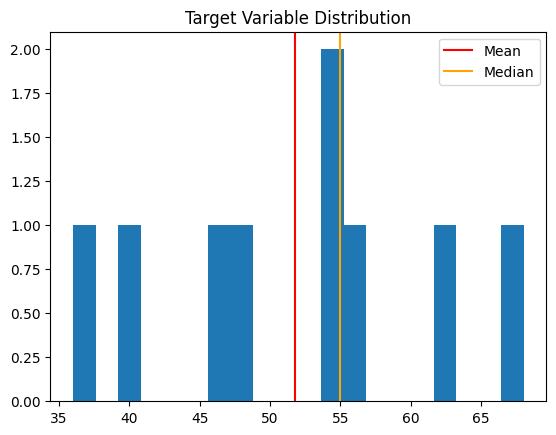

In [12]:
## Target Variable Distribution
plt.hist(df.Infant_Mortality_Rate_Imr_Total_Person, bins=20)
plt.axvline(df.Infant_Mortality_Rate_Imr_Total_Person.mean(), color='red', label='Mean')
plt.axvline(df.Infant_Mortality_Rate_Imr_Total_Person.median(), color='orange', label = 'Median')
plt.title('Target Variable Distribution'), plt.legend()
plt.show()

In [14]:
df.shape

(9, 643)

In [49]:
## Target Var Nulls
print(df.Infant_Mortality_Rate_Imr_Total_Person.isna().sum())

0


In [50]:
## Correlation overview
df.select_dtypes(include='number').corr()

,Sample_Units_Total,Sample_Units_Rural,Sample_Units_Urban,Households_Total,Households_Rural,Households_Urban,Population_Total,Population_Rural,Population_Urban,Ever_Married_Women_Aged_15_49_Years_Total,...,Under_Five_Mortality_Rate_U5MR_Rural_Lower_Limit,Under_Five_Mortality_Rate_U5MR_Rural_Upper_Limit,Under_Five_Mortality_Rate_U5MR_Urban_Lower_Limit,Under_Five_Mortality_Rate_U5MR_Urban_Upper_Limit,Sex_Ratio_At_Birth_Total_Lower_Limit,Sex_Ratio_At_Birth_Total_Upper_Limit,Sex_Ratio_At_Birth_Rural_Lower_Limit,Sex_Ratio_At_Birth_Rural_Upper_Limit,Sex_Ratio_At_Birth_Urban_Lower_Limit,Sex_Ratio_At_Birth_Urban_Upper_Limit
Sample_Units_Total,1.000000,0.966899,0.864244,0.921807,0.850719,0.769148,0.888621,0.822681,0.817989,0.891694,...,0.524291,0.499150,0.655073,0.602399,-0.254232,-0.368794,-0.158196,-0.300060,-0.418535,-0.557475
Sample_Units_Rural,0.966899,1.000000,0.707273,0.914290,0.892080,0.601029,0.882429,0.858010,0.656243,0.881845,...,0.402119,0.374030,0.569717,0.535903,-0.243511,-0.356487,-0.173195,-0.314751,-0.367069,-0.462935
Sample_Units_Urban,0.864244,0.707273,1.000000,0.751328,0.598161,0.945999,0.722202,0.587652,0.972456,0.731865,...,0.659773,0.645498,0.691680,0.612410,-0.224267,-0.318924,-0.096824,-0.210777,-0.435872,-0.631808
Households_Total,0.921807,0.914290,0.751328,1.000000,0.974608,0.661058,0.986546,0.957544,0.740140,0.990845,...,0.651145,0.625539,0.755083,0.720835,0.029674,-0.108278,0.087031,-0.082804,-0.125959,-0.283446
Households_Rural,0.850719,0.892080,0.598161,0.974608,1.000000,0.476260,0.975623,0.988728,0.573149,0.976786,...,0.561319,0.532790,0.688413,0.672016,0.073701,-0.065275,0.105523,-0.068140,-0.053175,-0.176674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sex_Ratio_At_Birth_Total_Upper_Limit,-0.368794,-0.356487,-0.318924,-0.108278,-0.065275,-0.206467,-0.064482,-0.028732,-0.177032,-0.085243,...,0.000202,0.007084,-0.273113,-0.277564,0.987562,1.000000,0.952191,0.971825,0.821006,0.773296
Sex_Ratio_At_Birth_Rural_Lower_Limit,-0.158196,-0.173195,-0.096824,0.087031,0.105523,-0.011838,0.139011,0.152322,0.038177,0.119891,...,0.067647,0.065542,-0.160632,-0.193392,0.974018,0.952191,1.000000,0.981882,0.654983,0.569661
Sex_Ratio_At_Birth_Rural_Upper_Limit,-0.300060,-0.314751,-0.210777,-0.082804,-0.068140,-0.096834,-0.036182,-0.024609,-0.067086,-0.058022,...,-0.052563,-0.048557,-0.294316,-0.323361,0.964029,0.971825,0.981882,1.000000,0.670482,0.610786
Sex_Ratio_At_Birth_Urban_Lower_Limit,-0.418535,-0.367069,-0.435872,-0.125959,-0.053175,-0.316446,-0.110983,-0.047633,-0.311611,-0.118034,...,0.218785,0.232140,-0.112412,-0.062277,0.805723,0.821006,0.654983,0.670482,1.000000,0.970651


In [ ]:
# Ordered correlation with target var
target_corr = dict(df.select_dtypes(include='number').corr()['Infant_Mortality_Rate_Imr_Total_Person'])
sorted(target_corr.items(), key = lambda item: item[1])

In [ ]:
# Columns representing totals
col_totals=[]
for c in df.columns:
    if 'Total' in c:
        col_totals.append(c)
col_totals

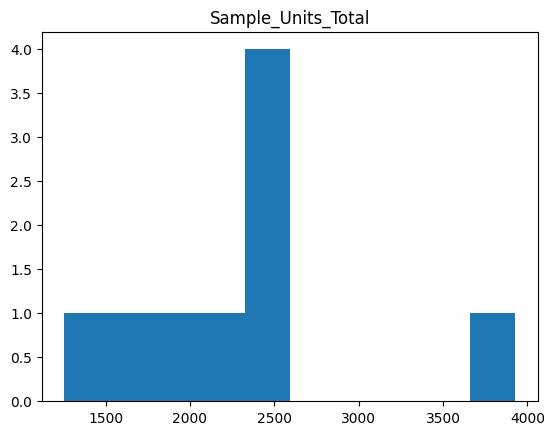

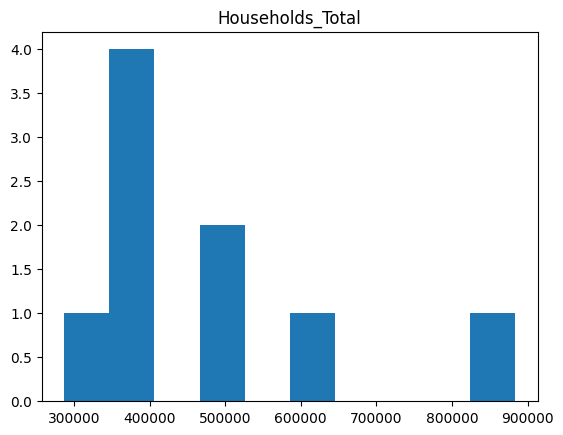

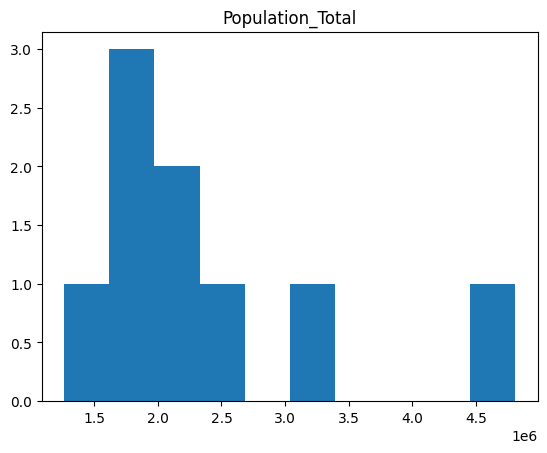

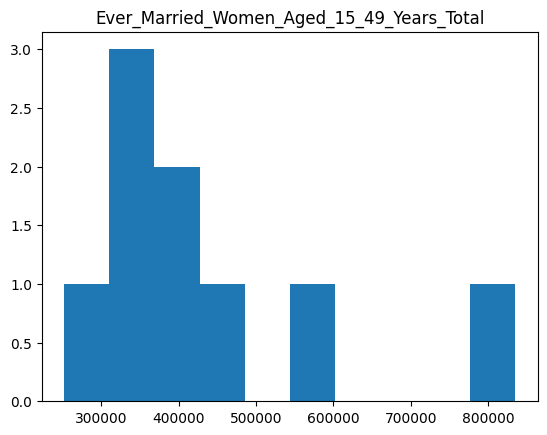

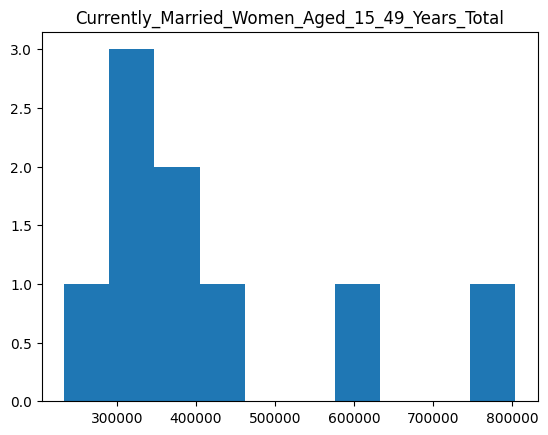

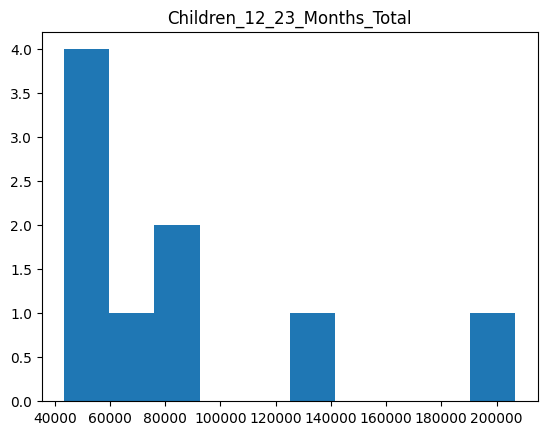

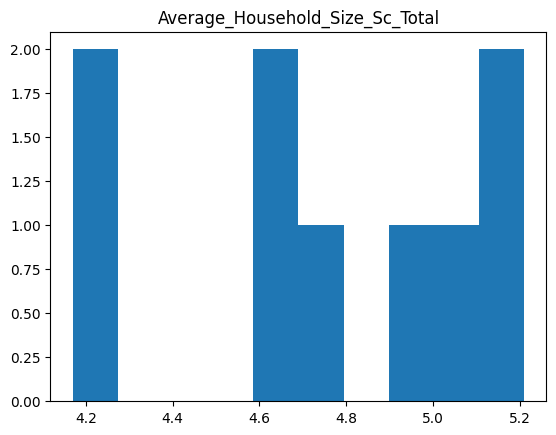

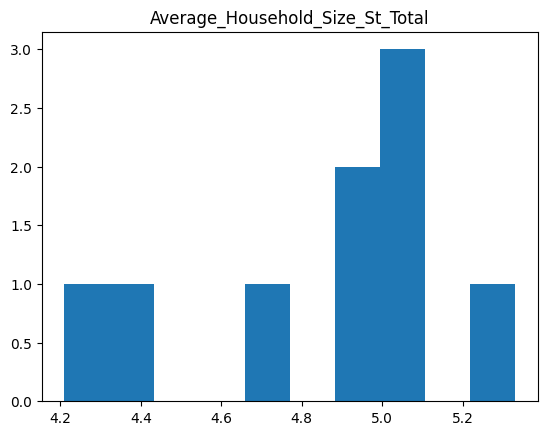

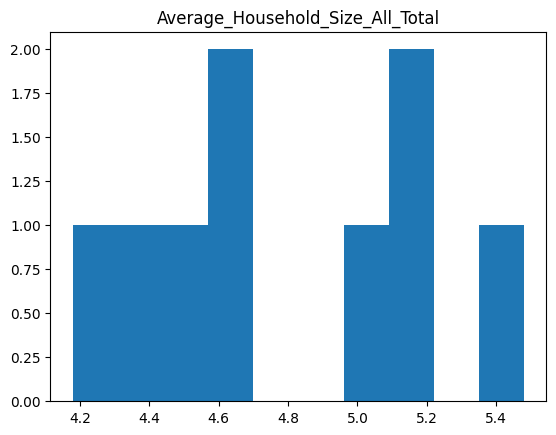

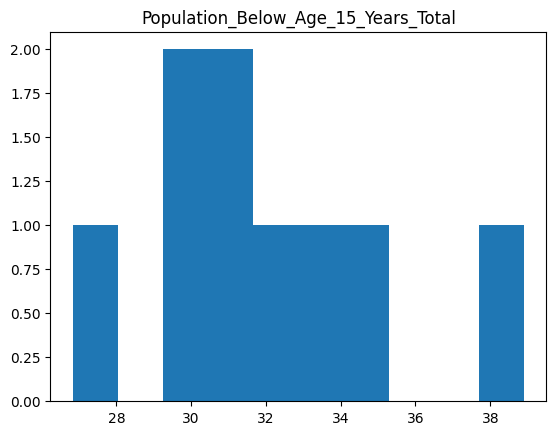

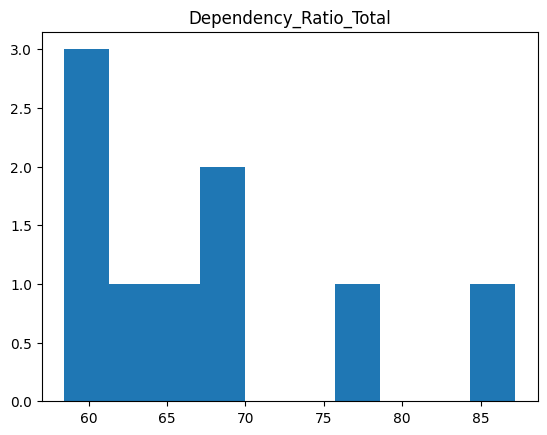

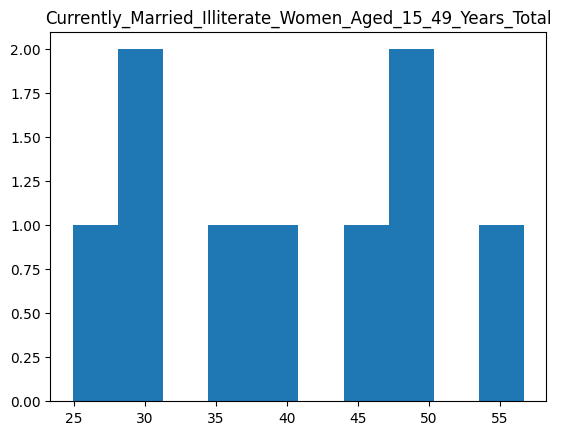

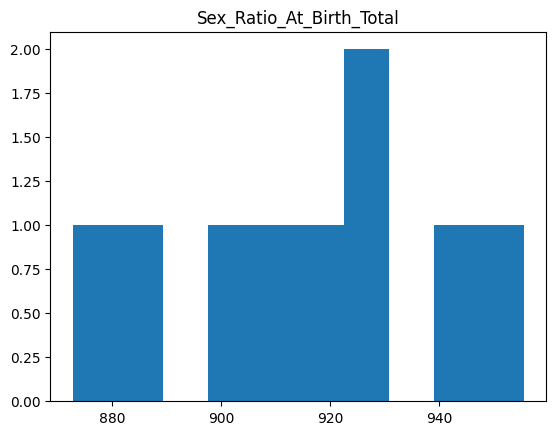

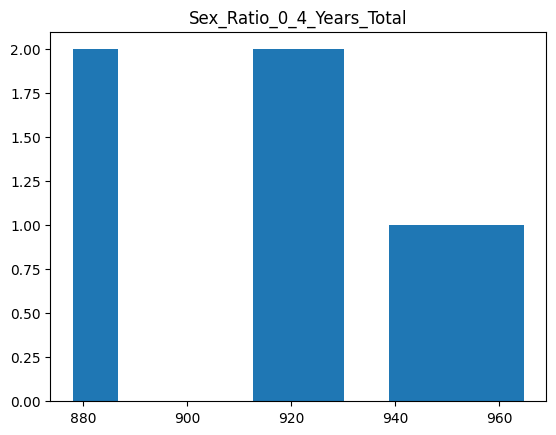

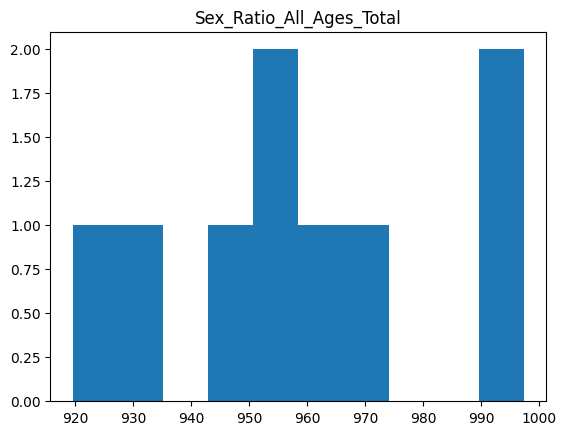

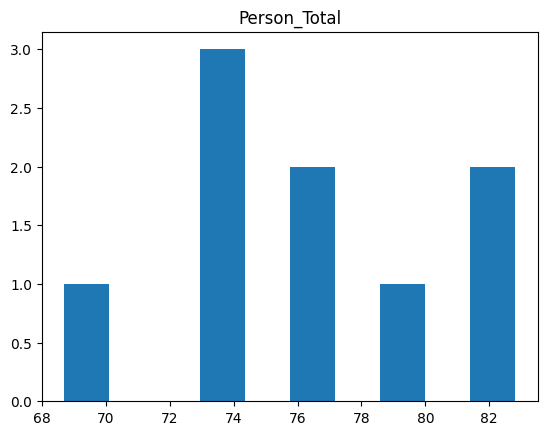

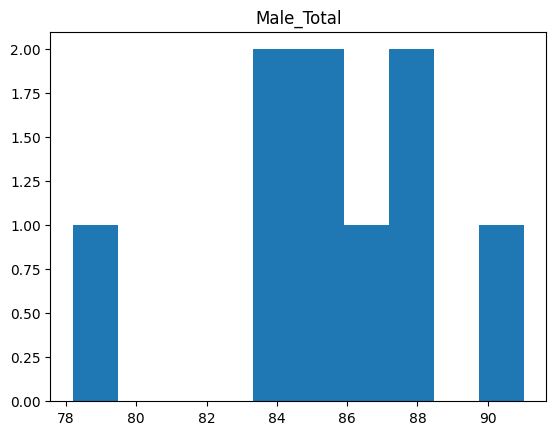

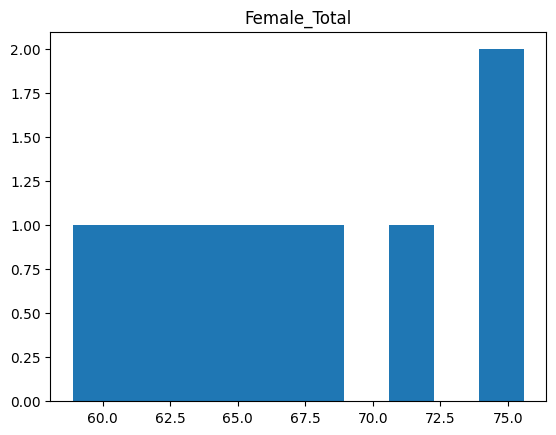

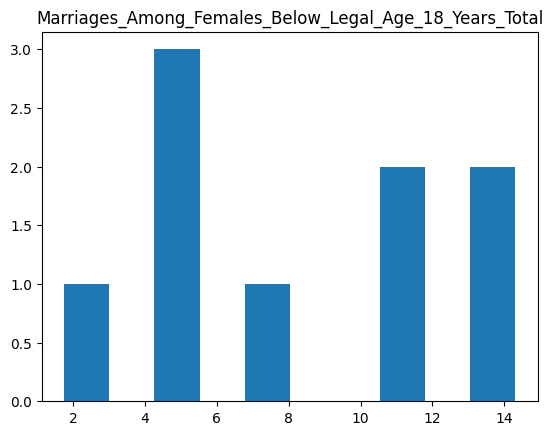

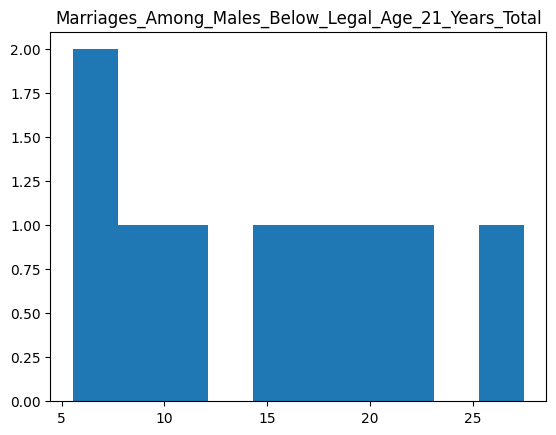

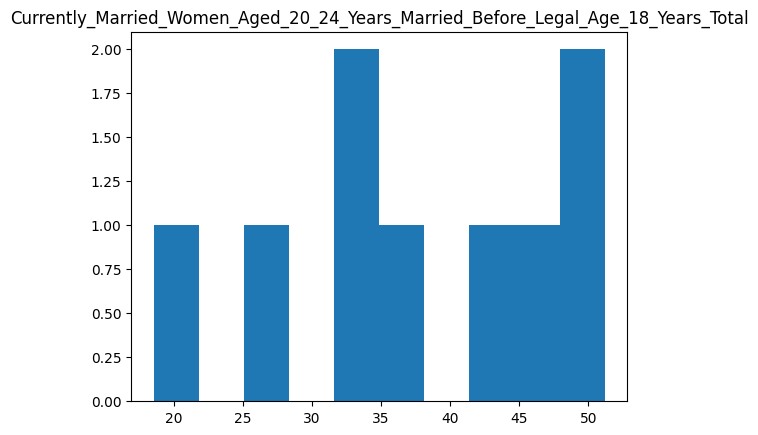

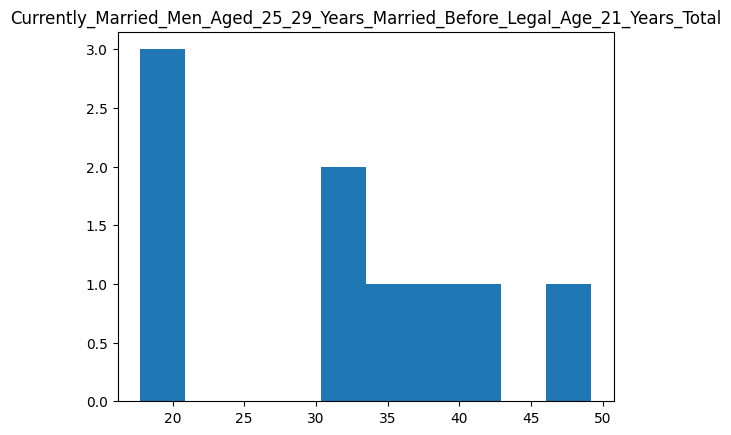

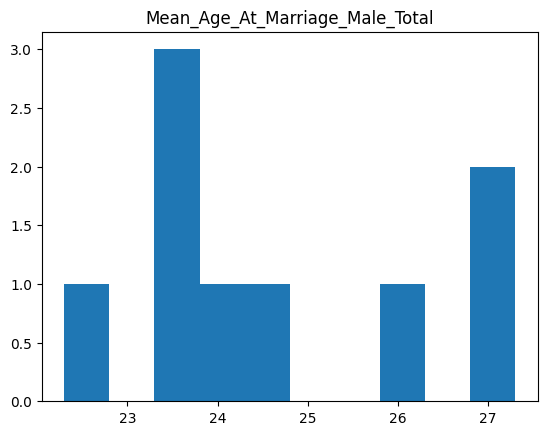

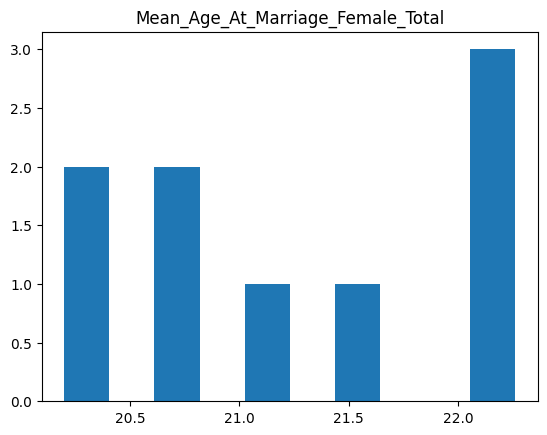

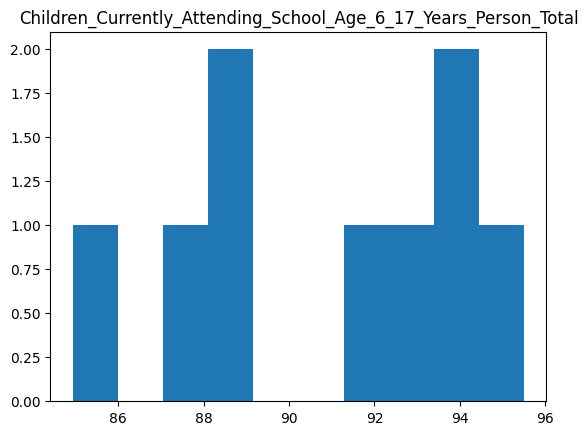

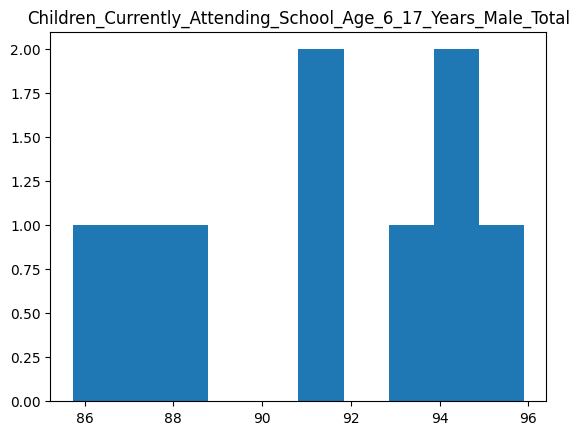

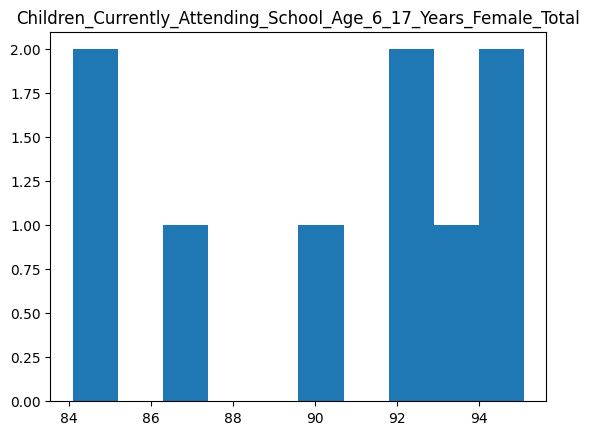

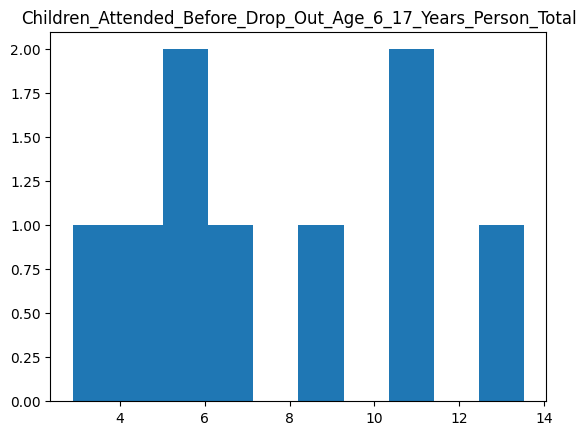

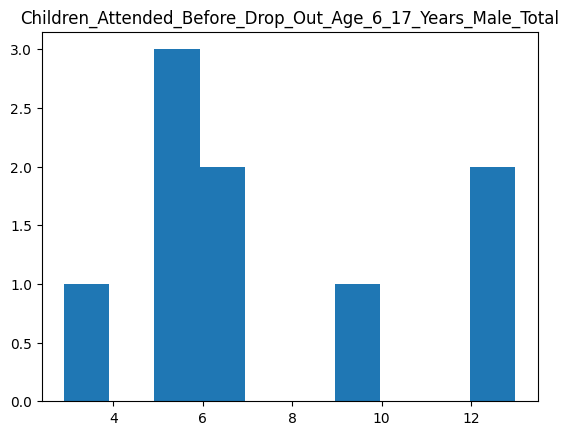

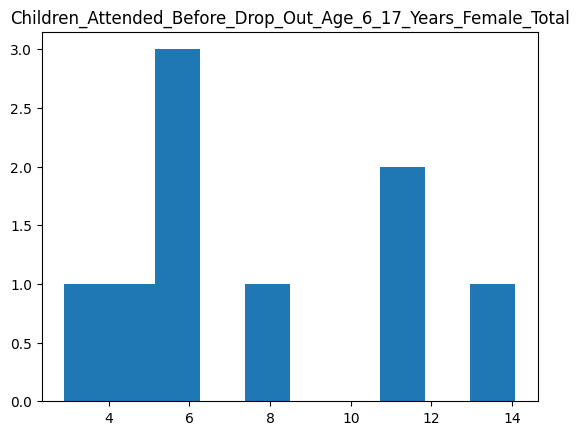

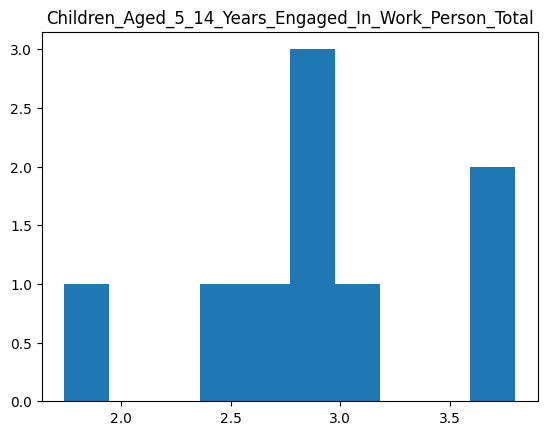

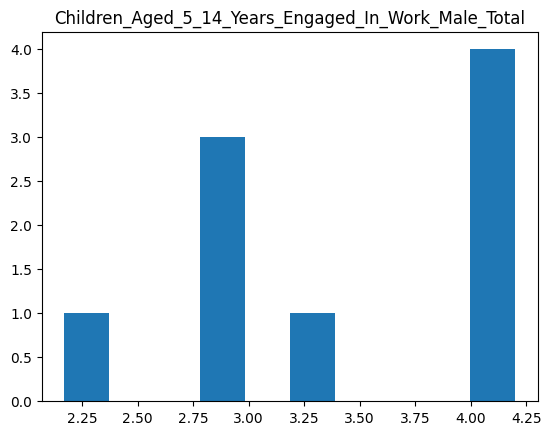

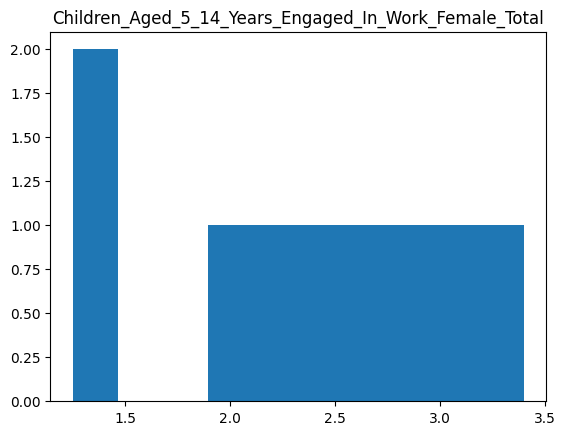

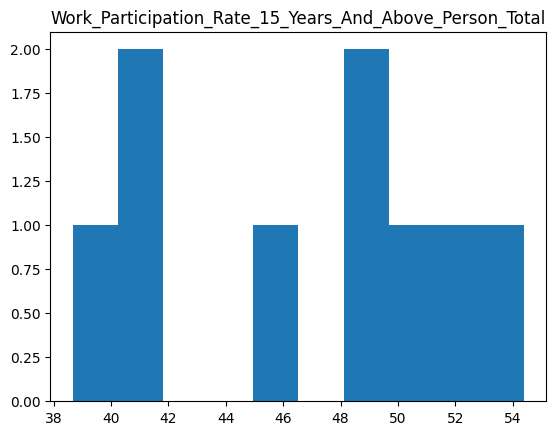

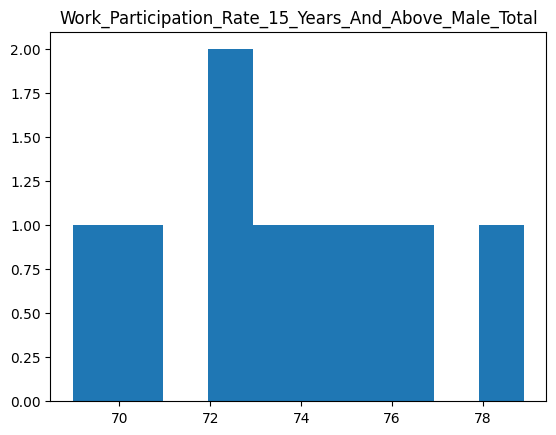

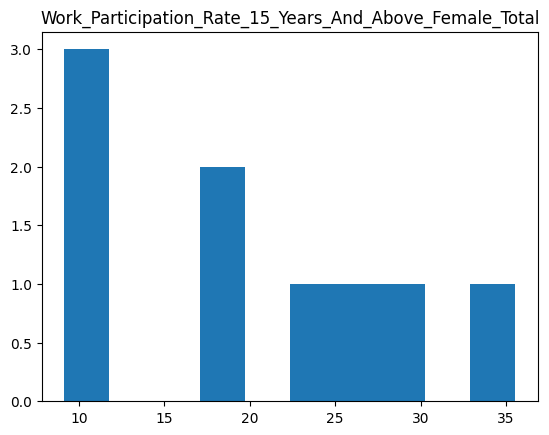

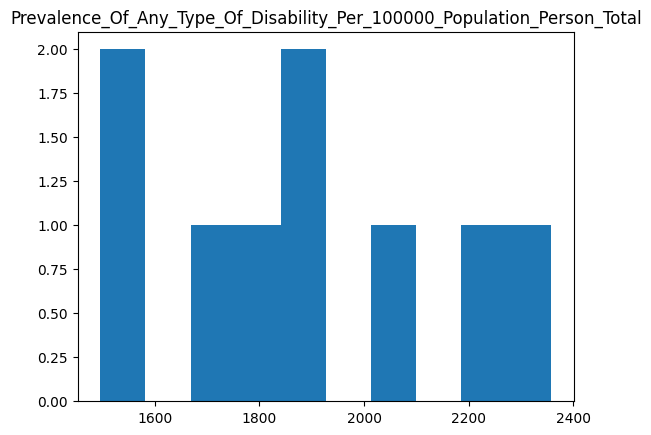

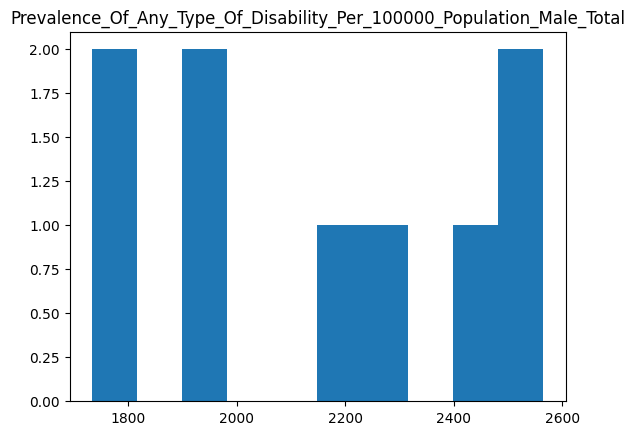

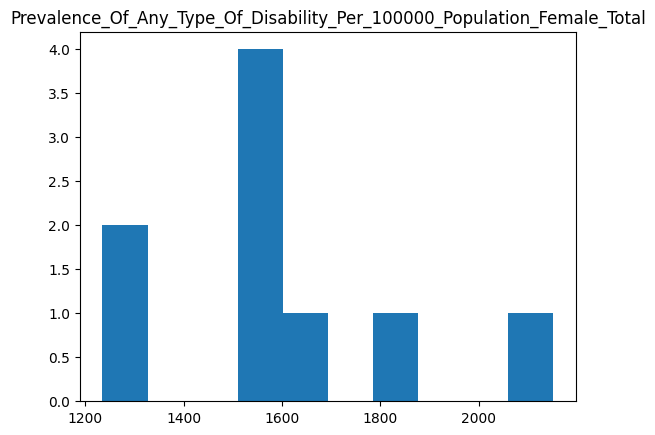

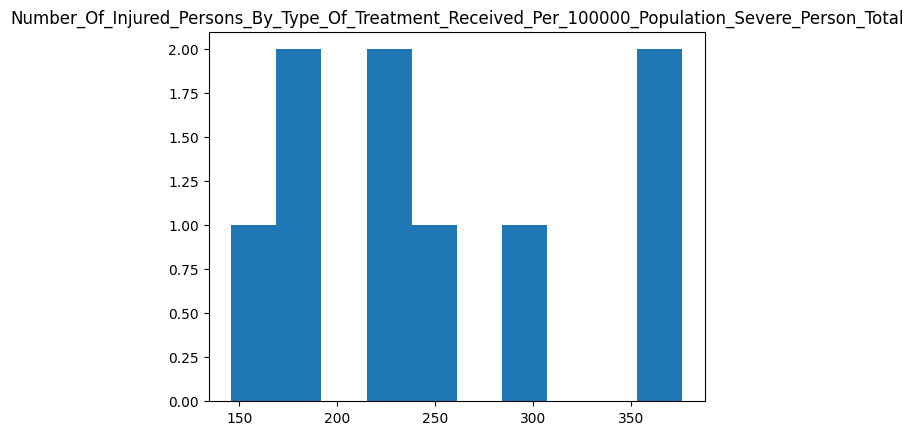

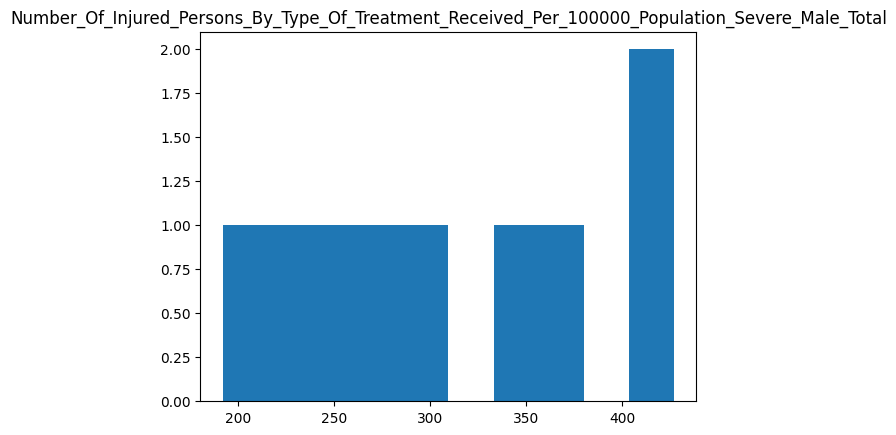

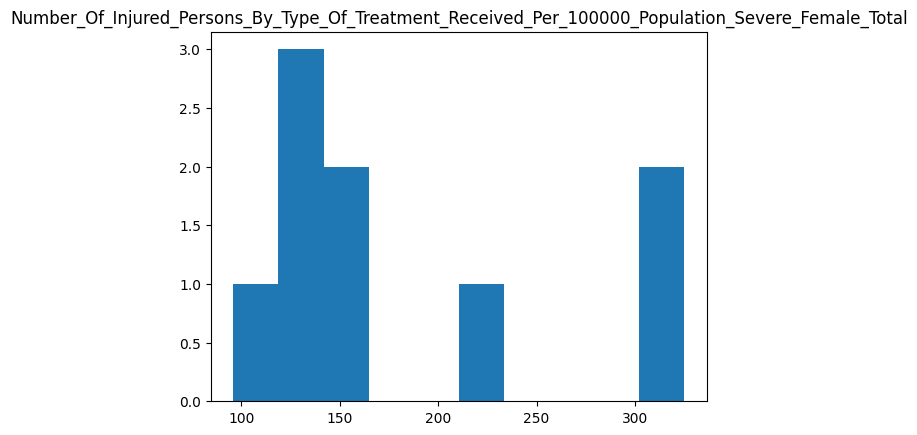

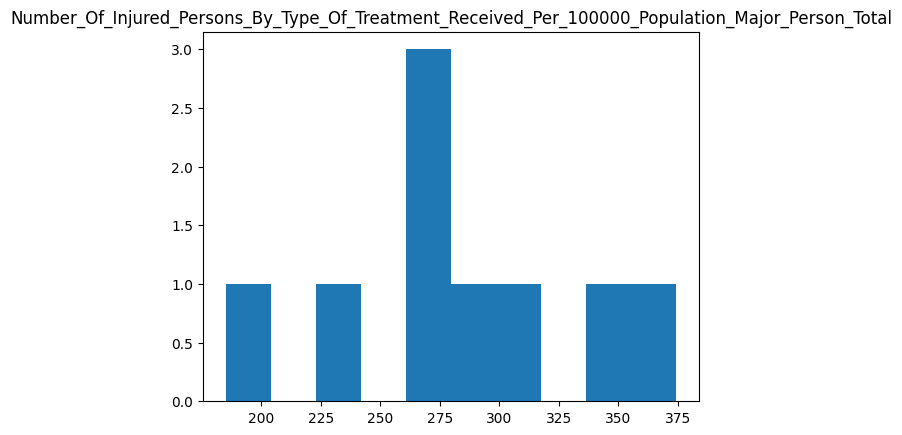

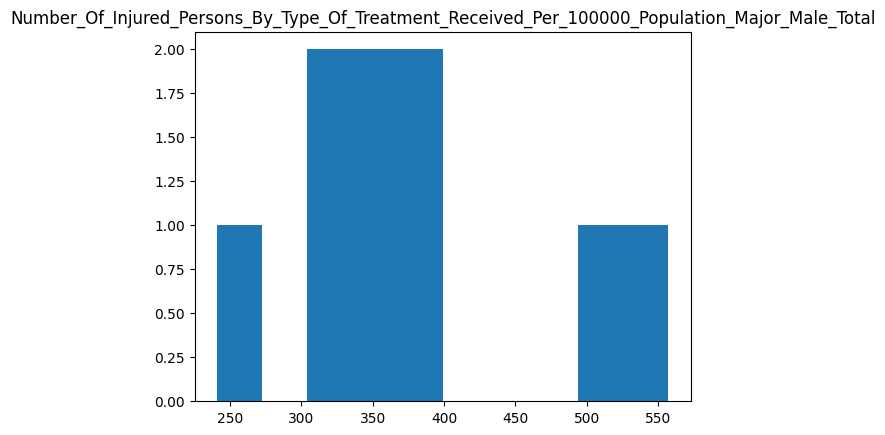

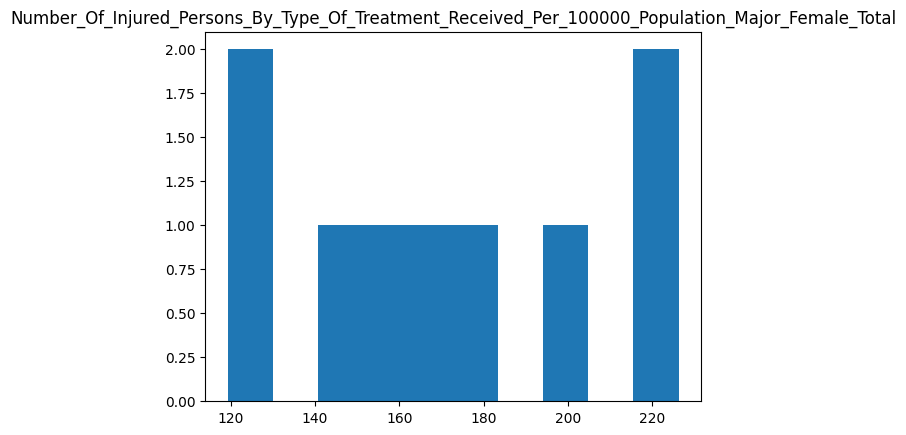

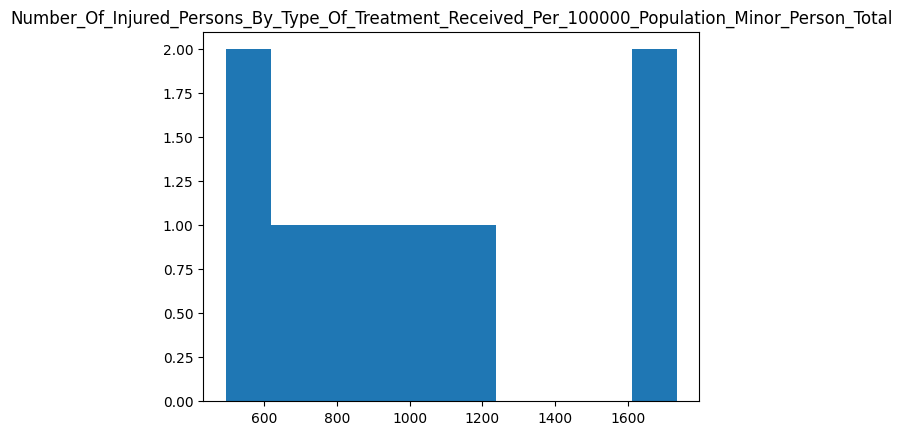

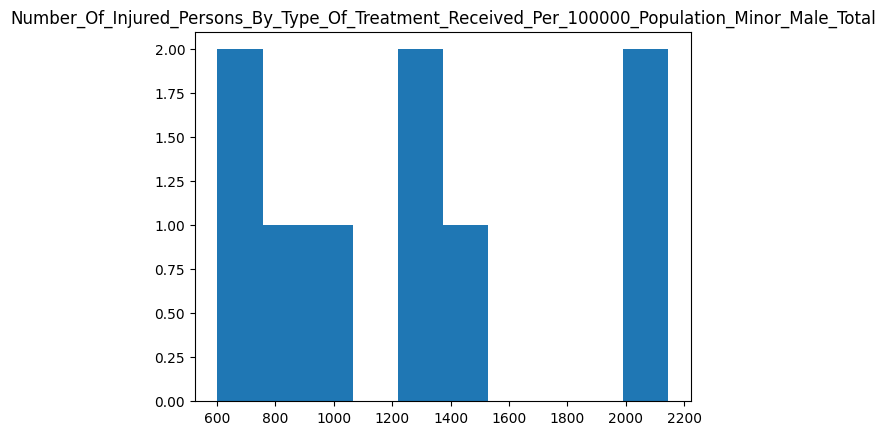

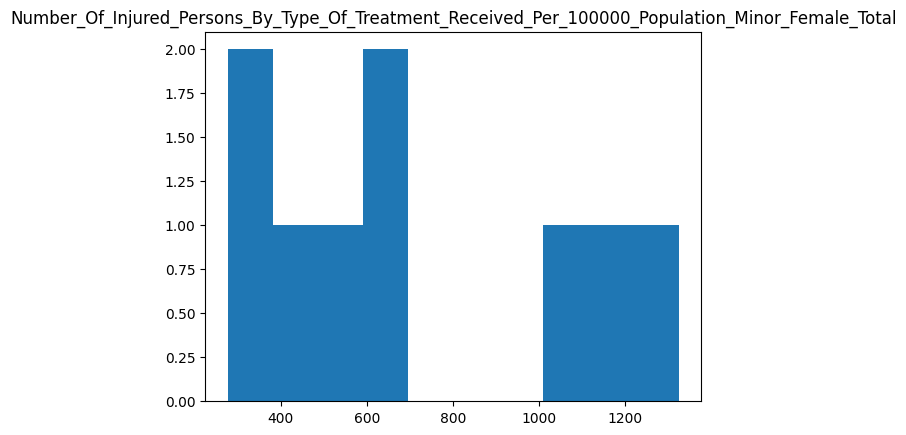

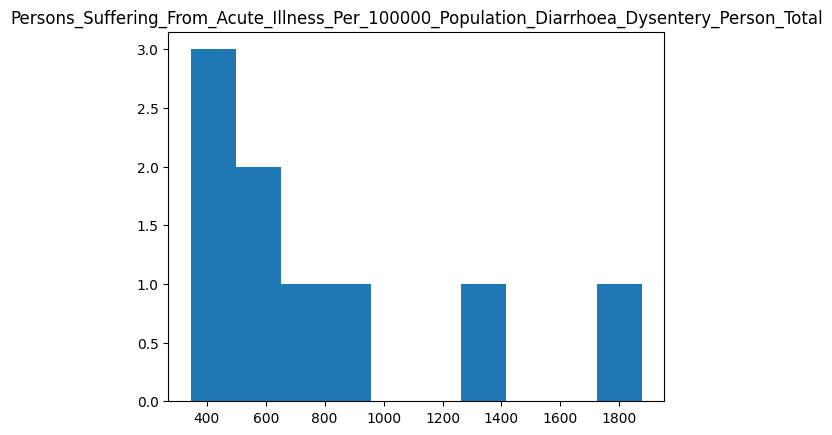

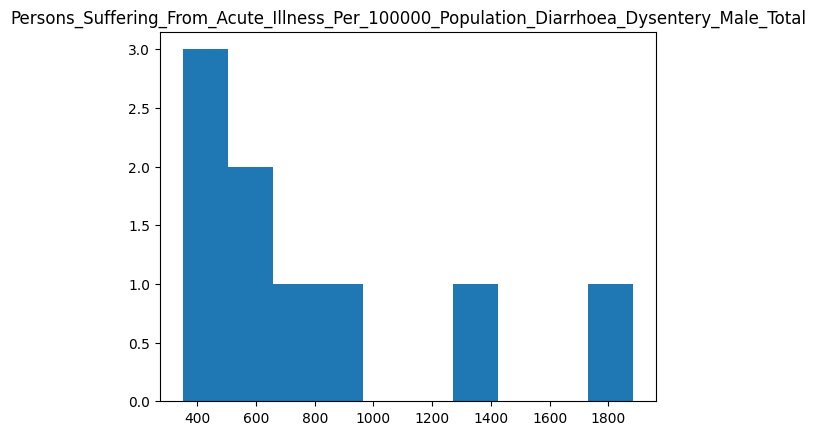

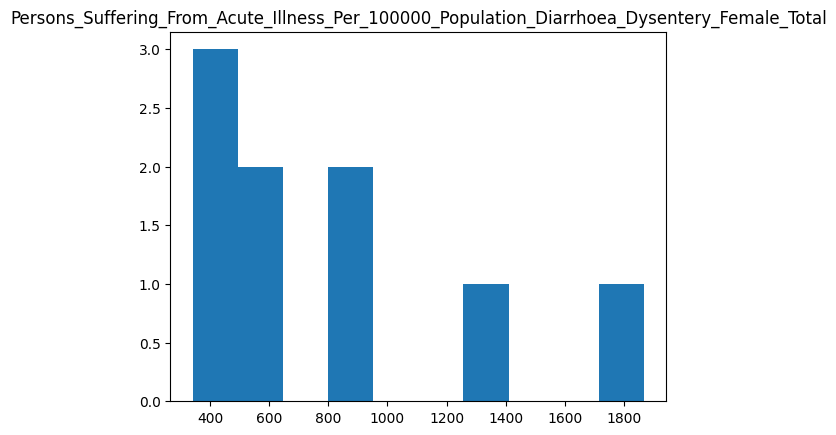

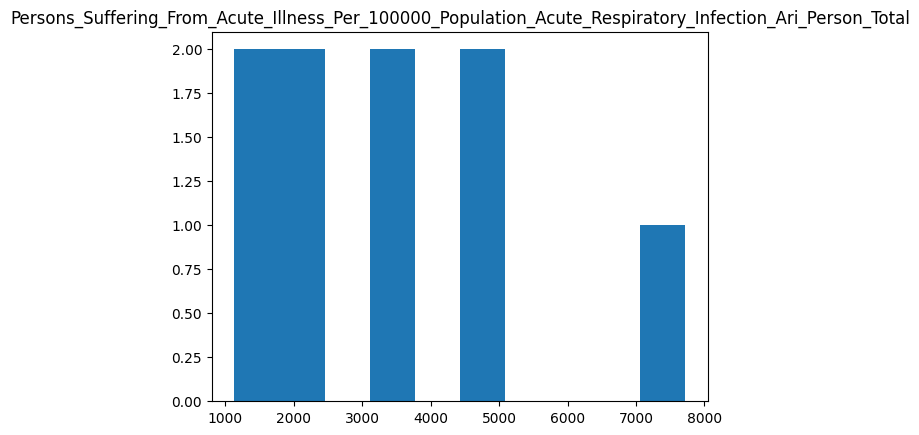

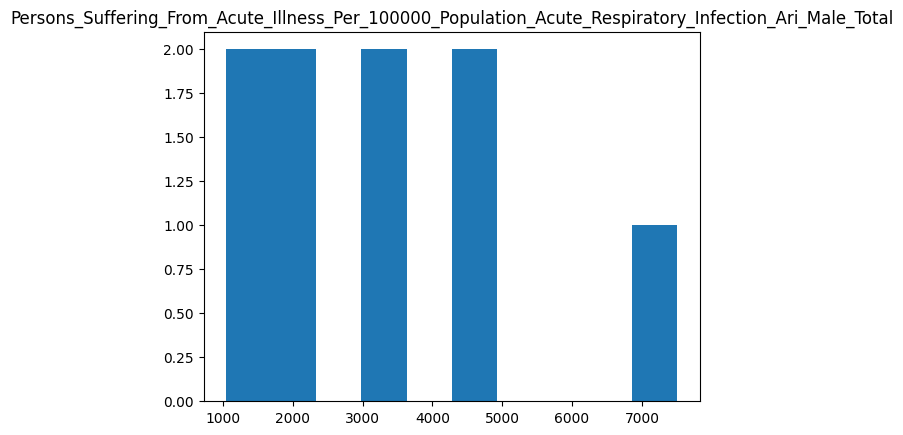

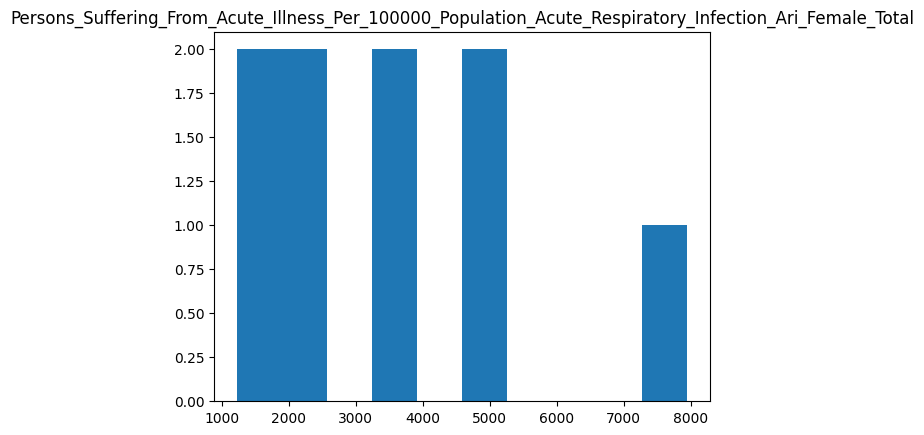

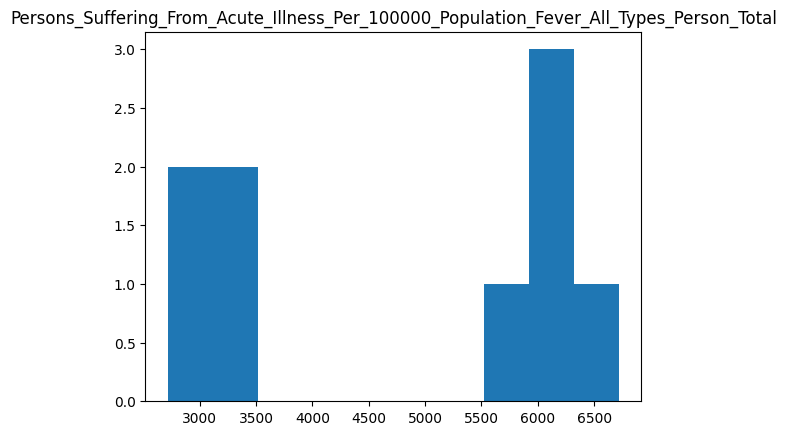

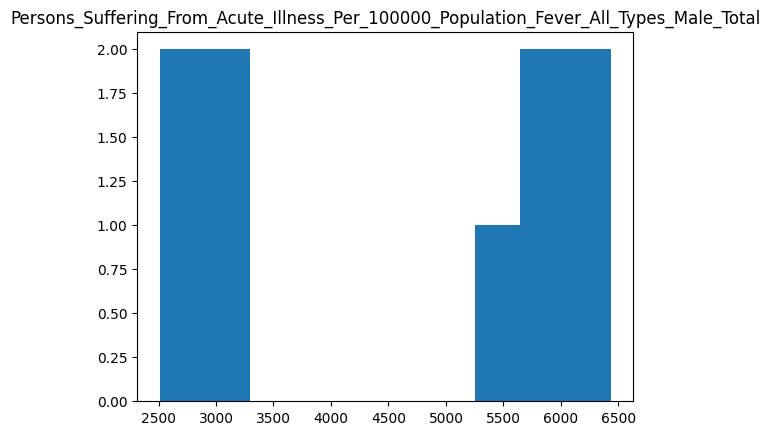

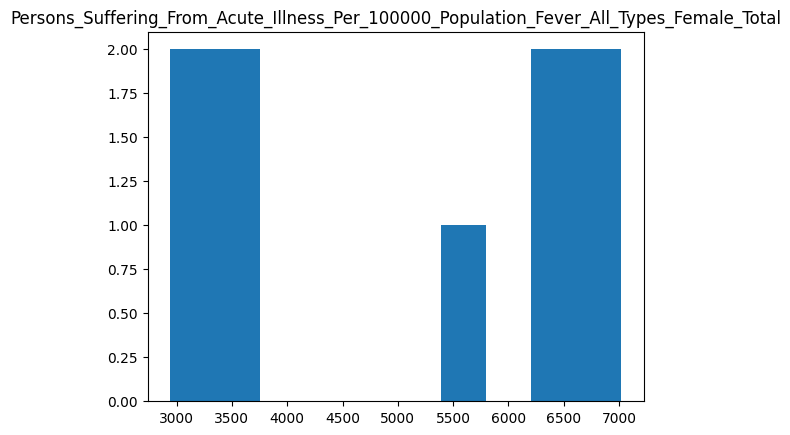

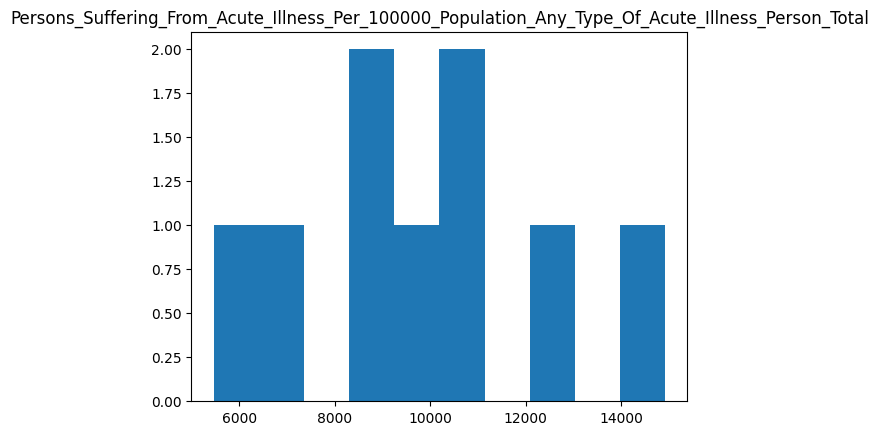

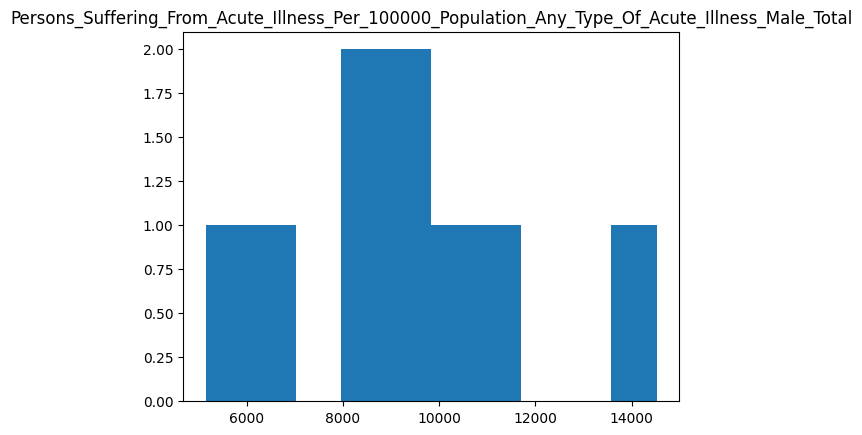

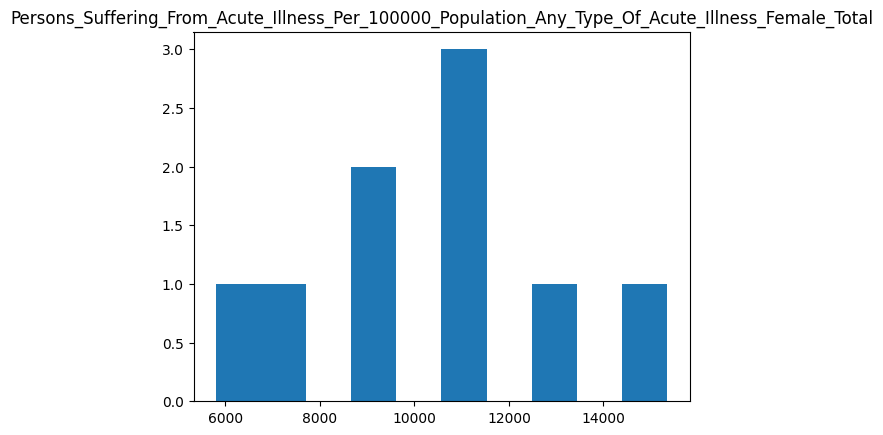

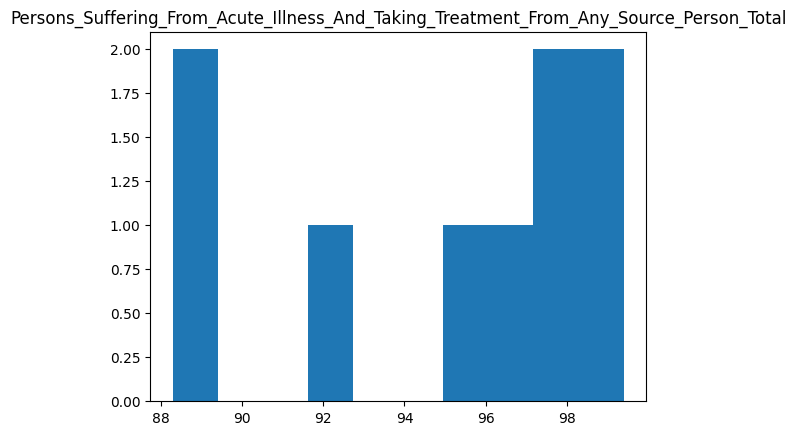

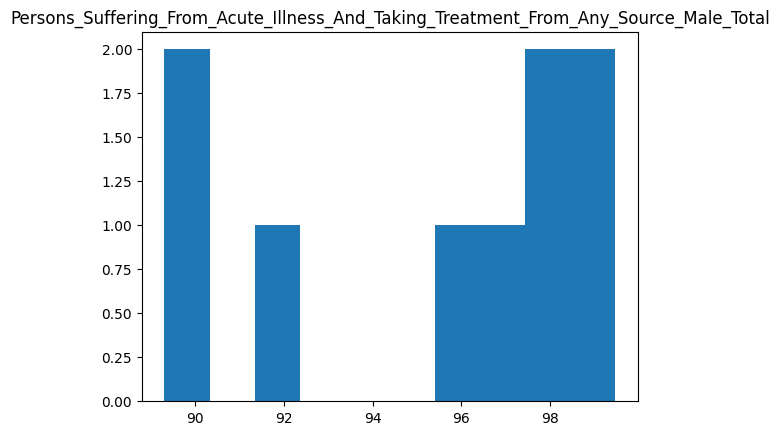

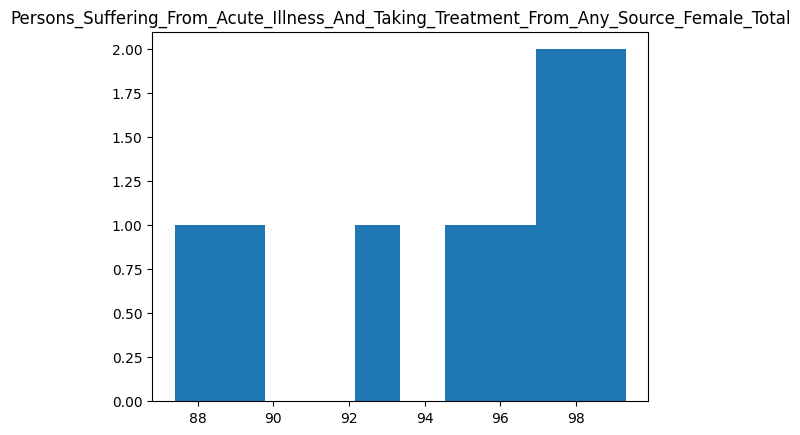

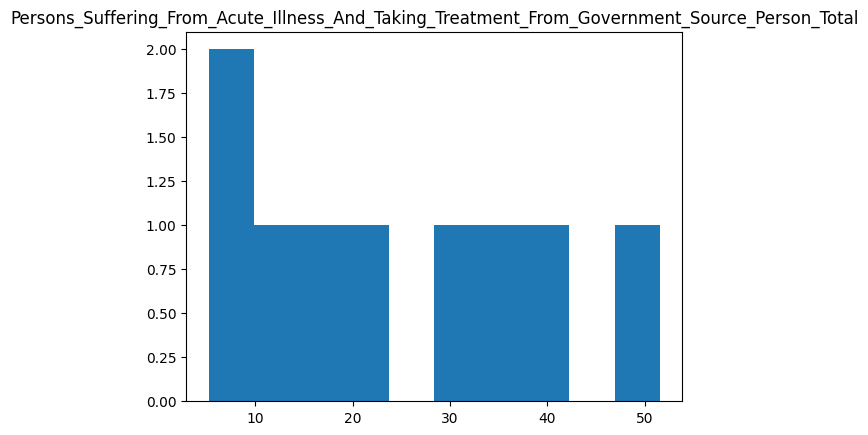

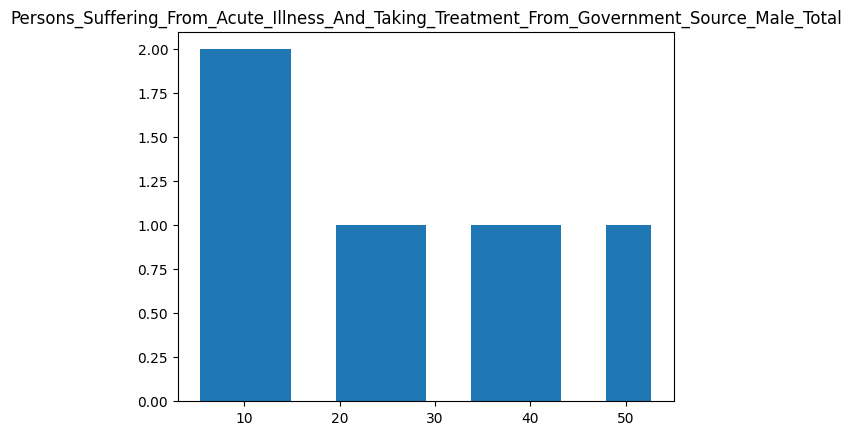

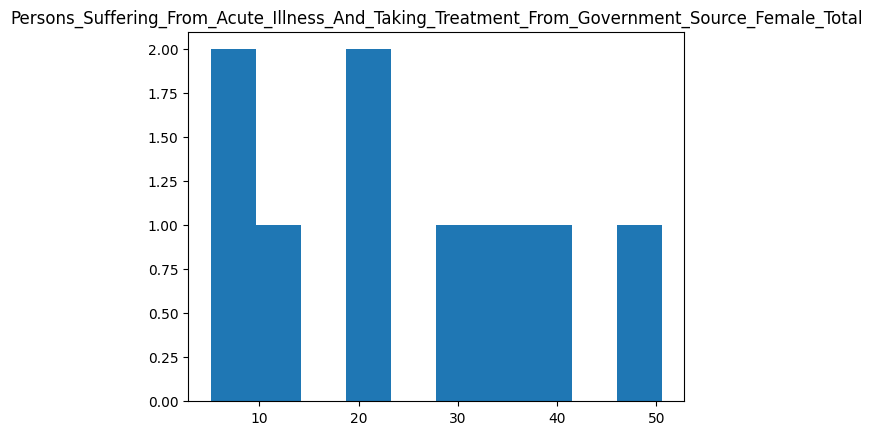

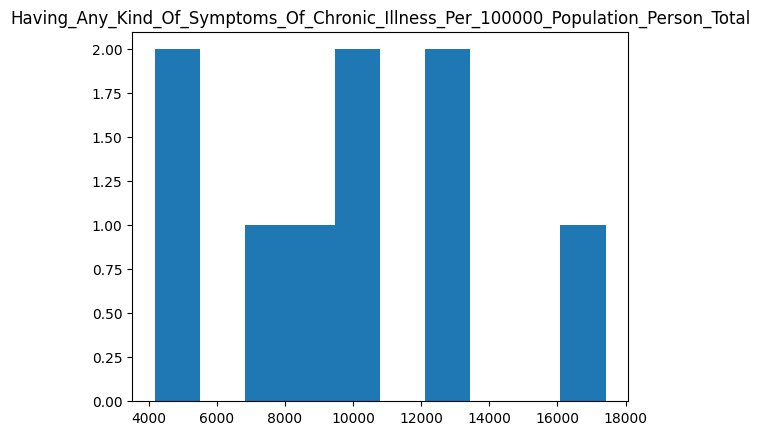

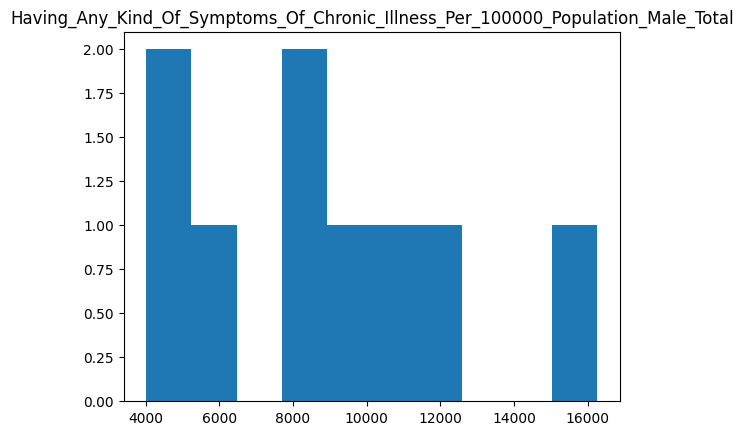

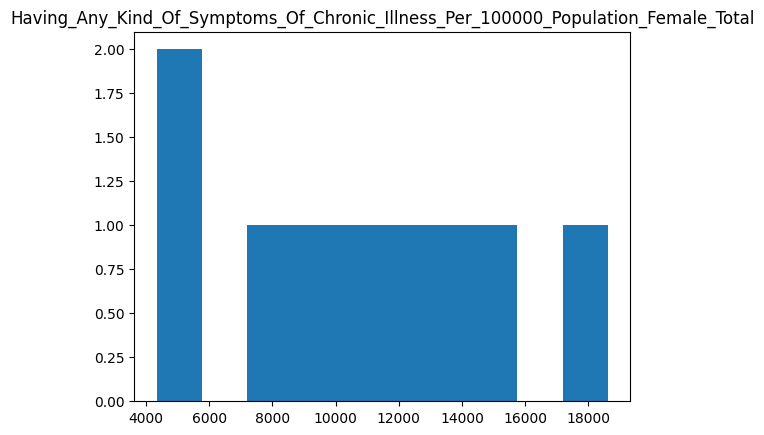

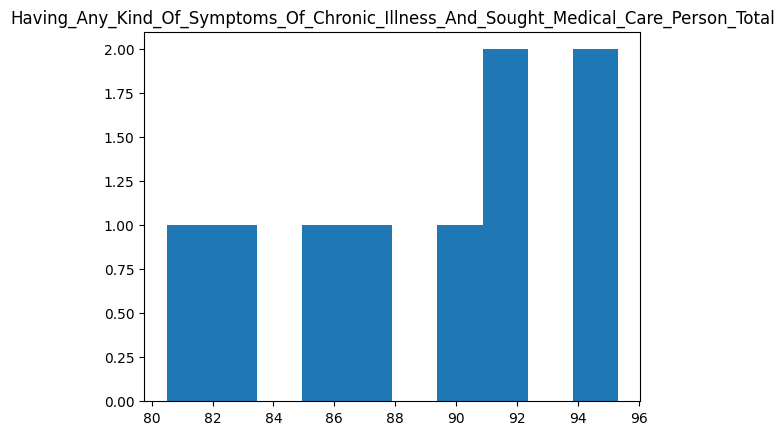

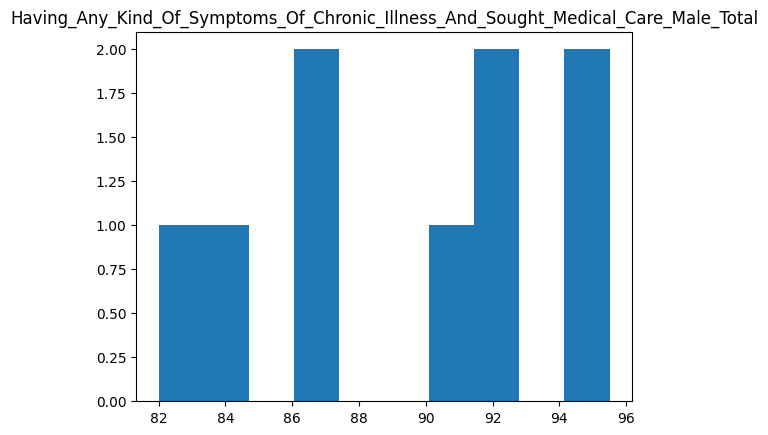

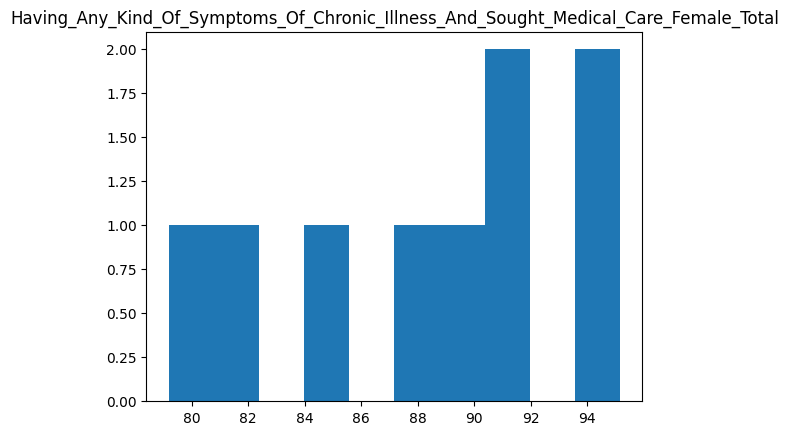

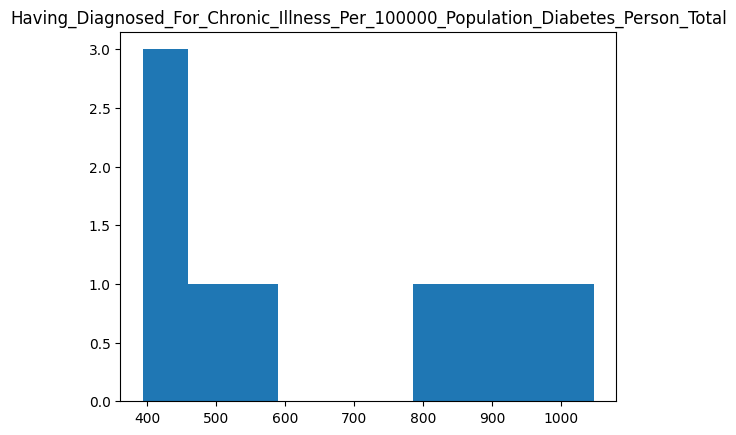

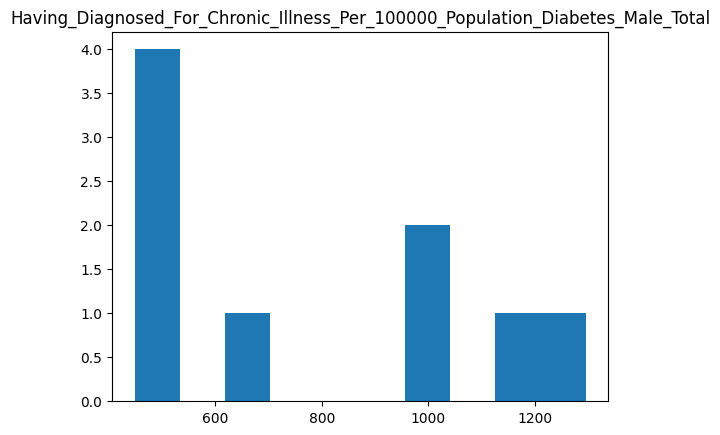

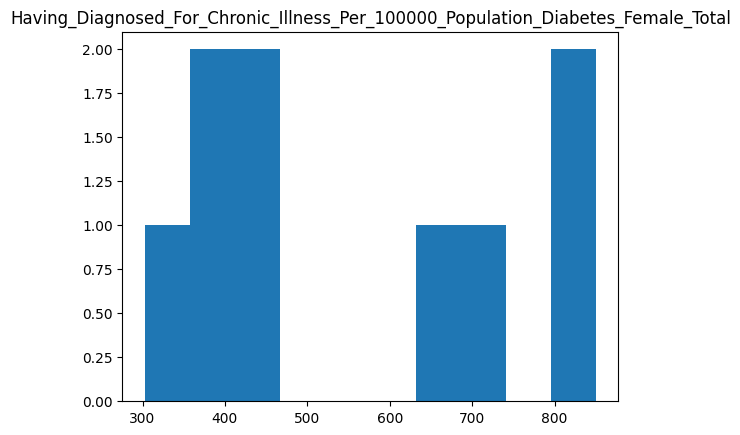

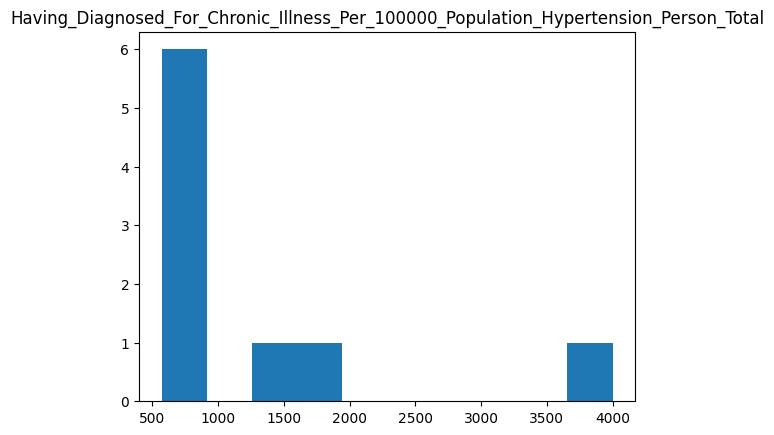

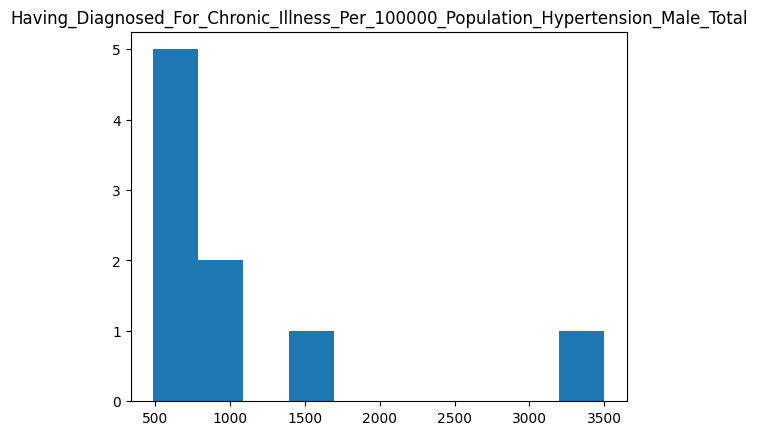

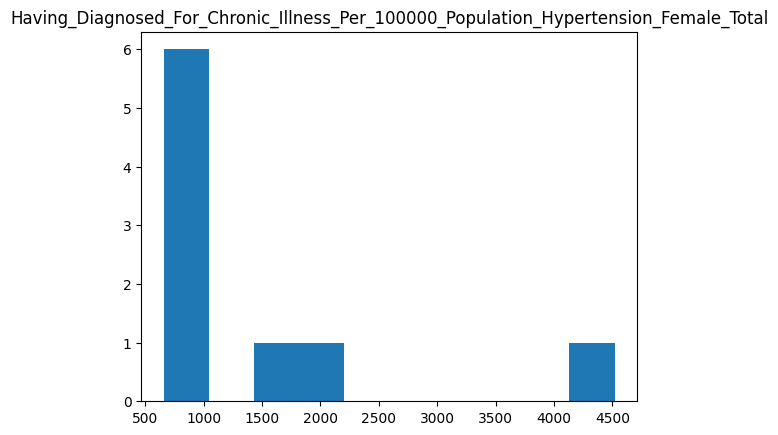

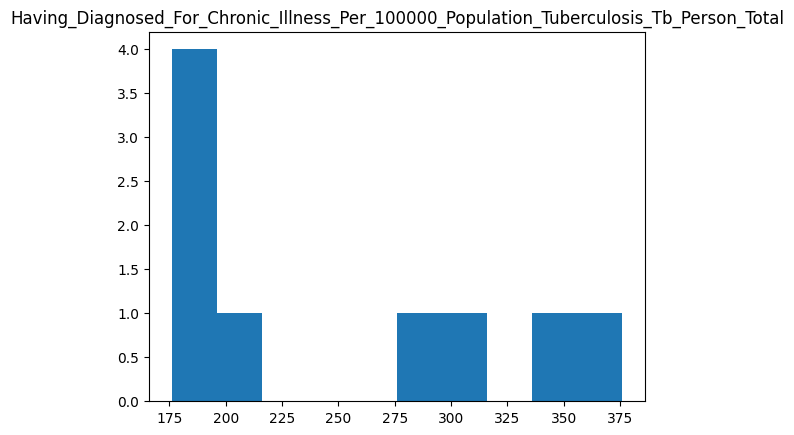

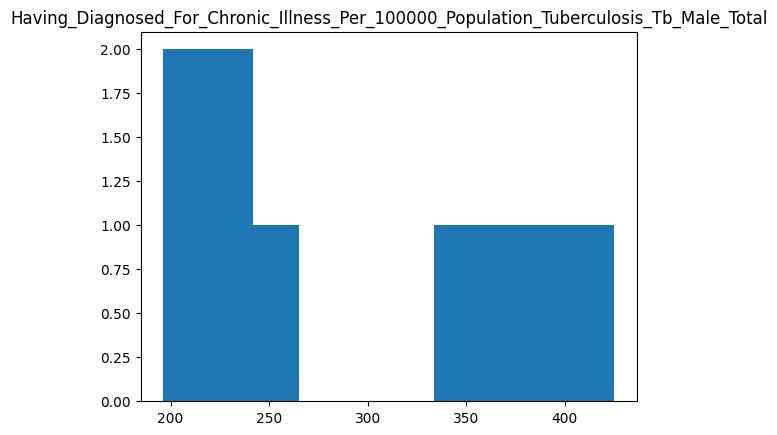

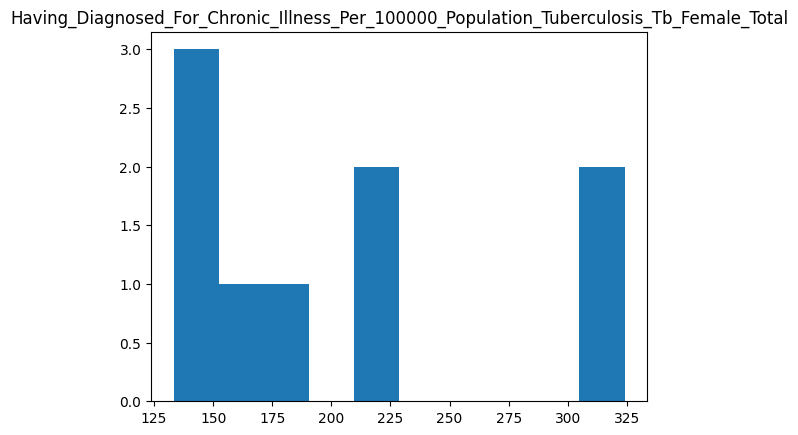

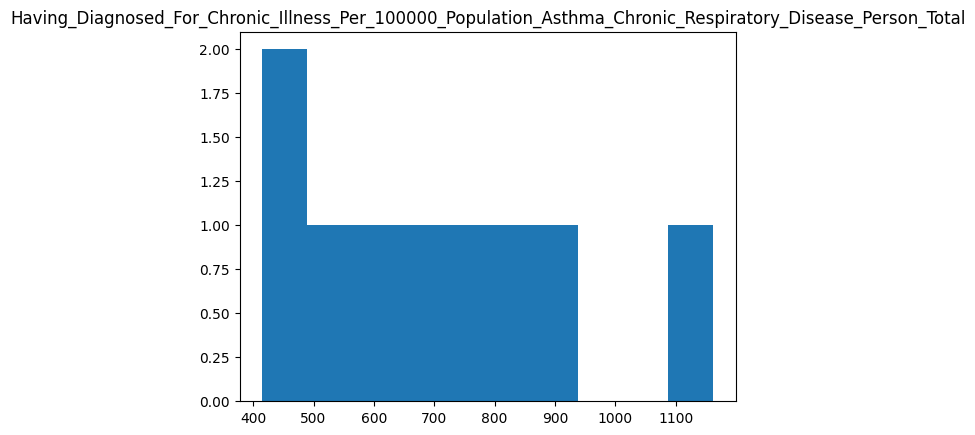

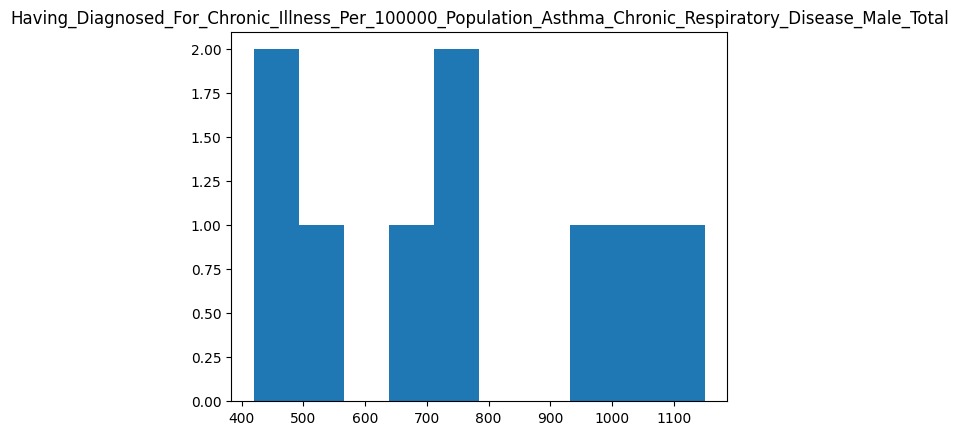

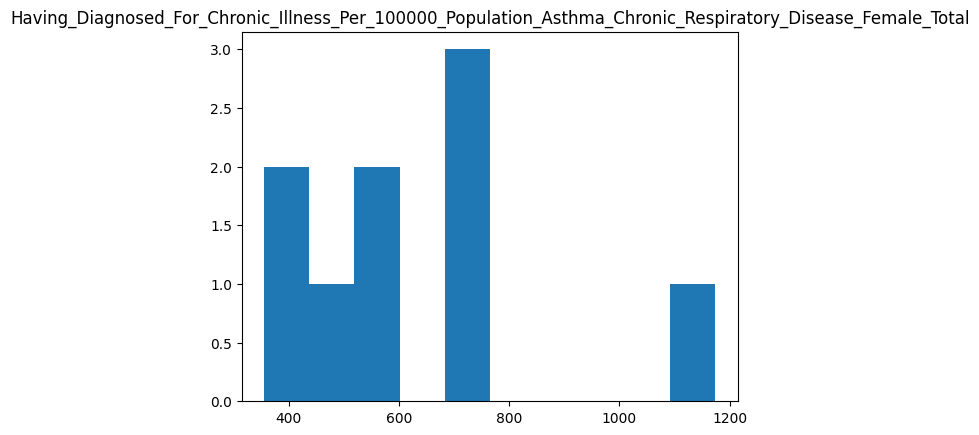

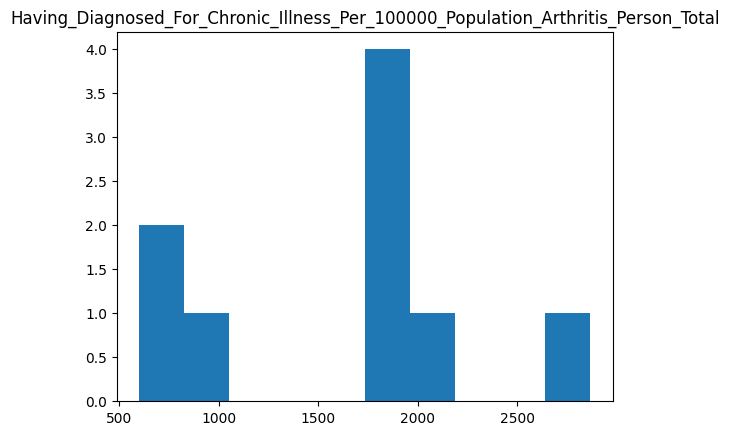

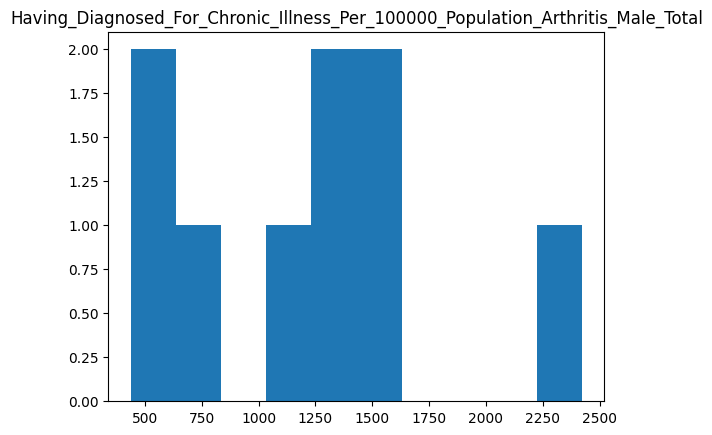

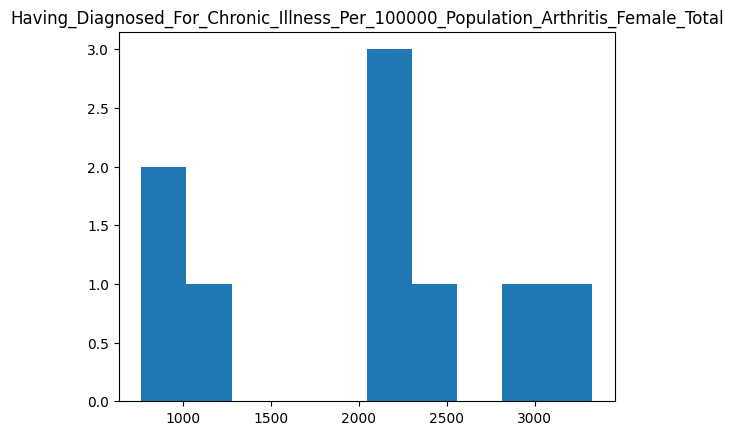

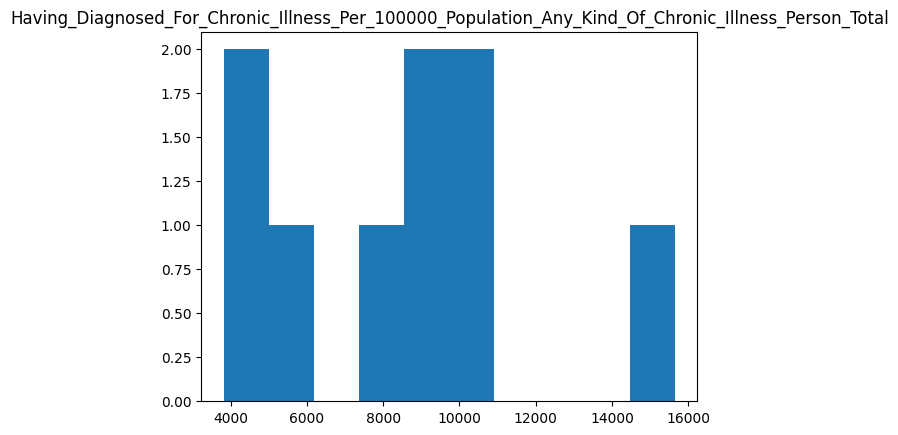

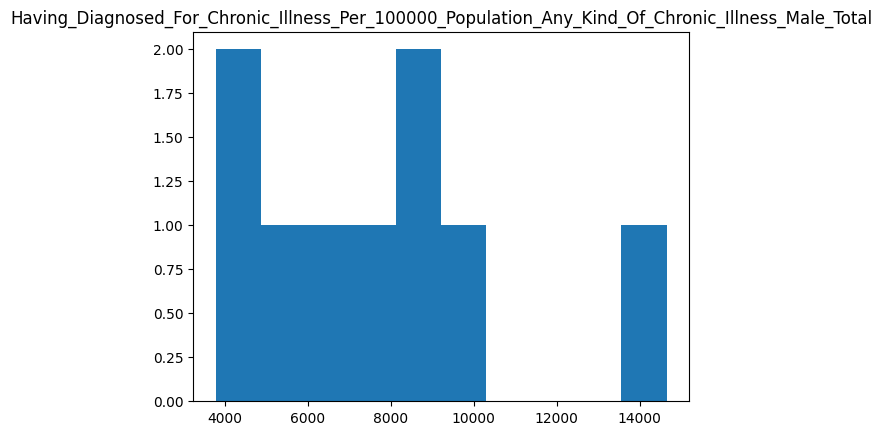

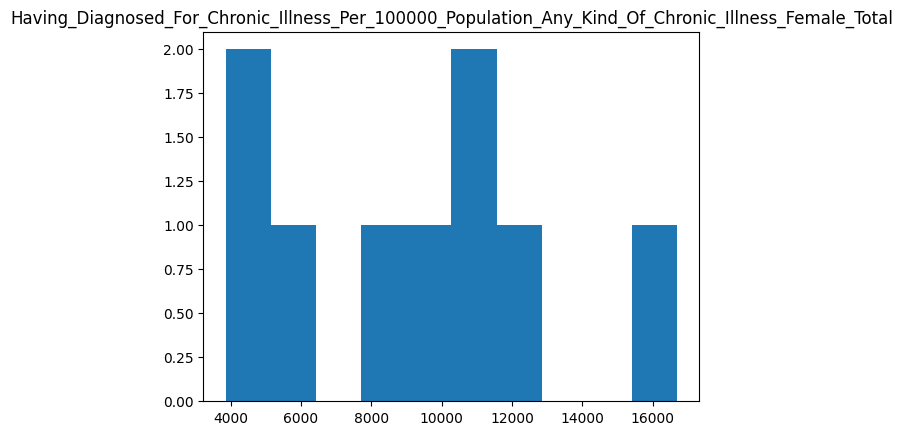

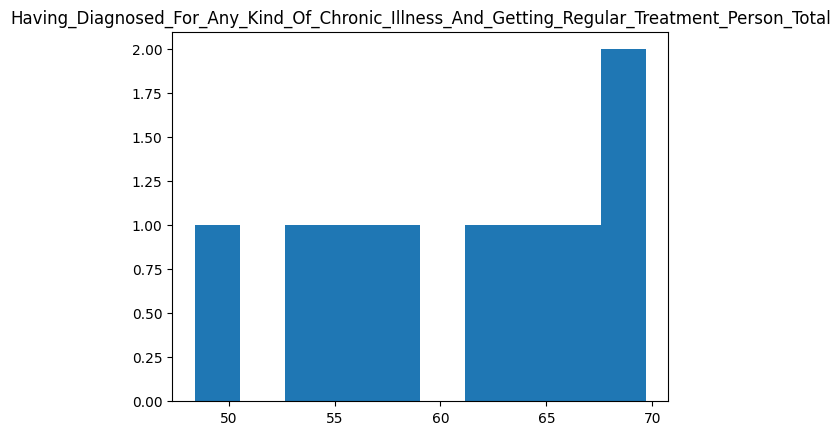

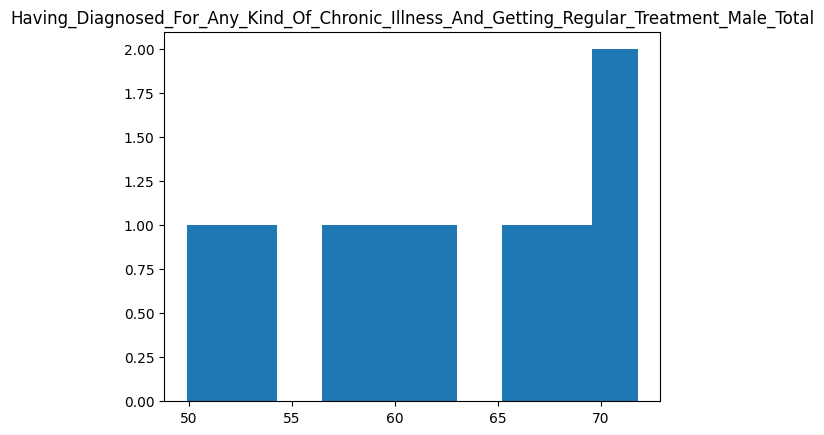

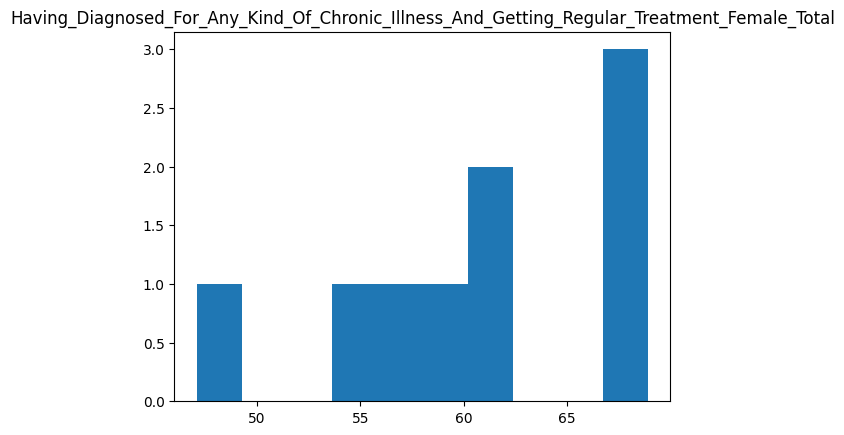

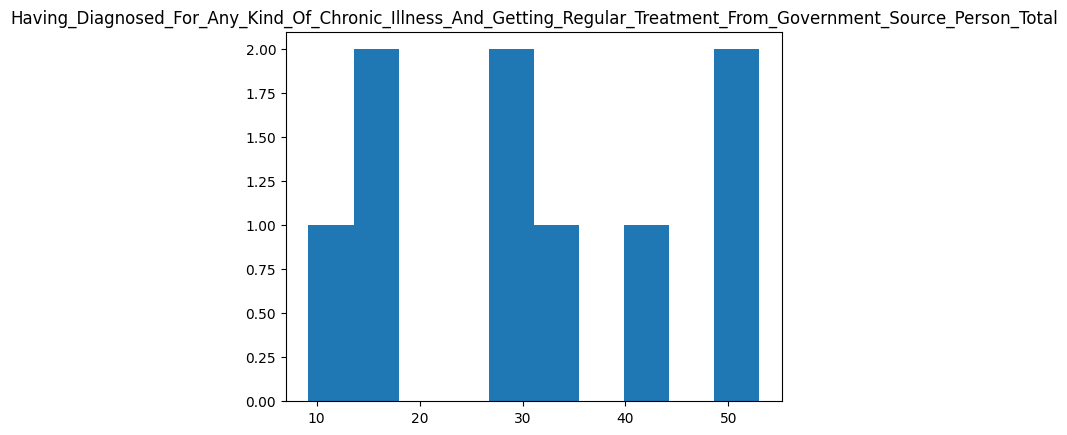

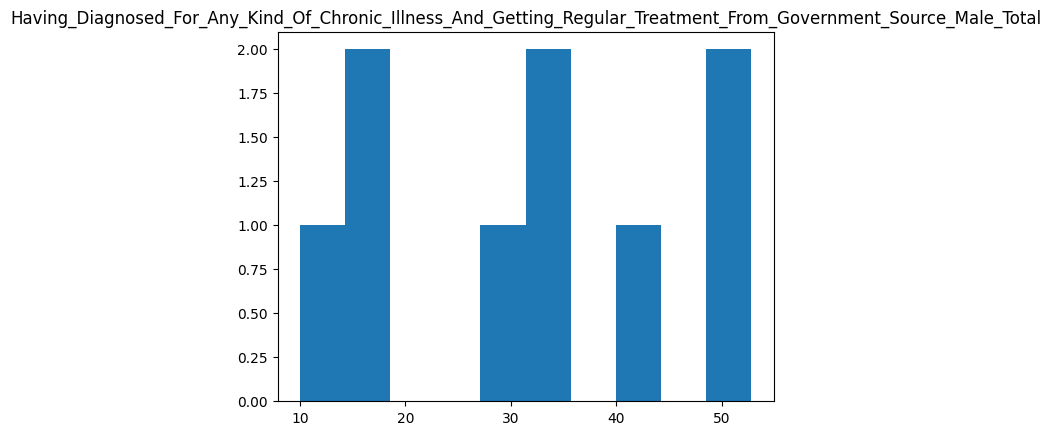

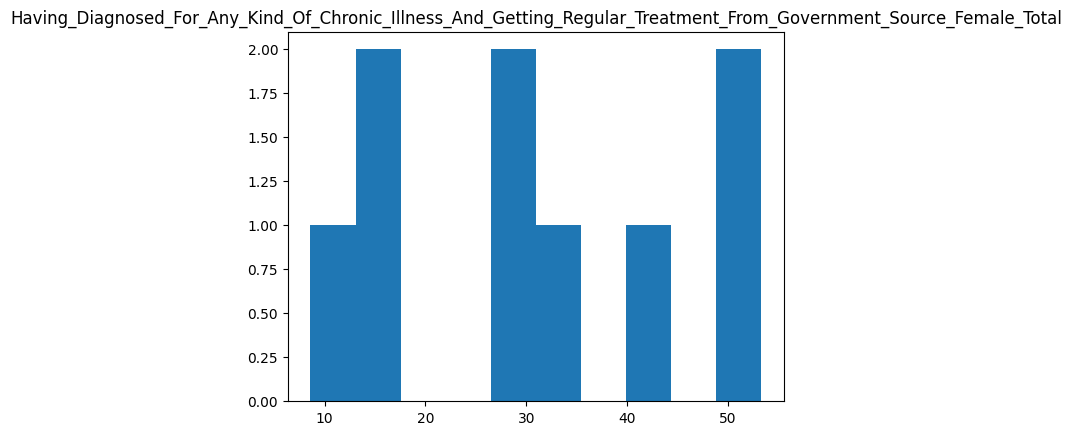

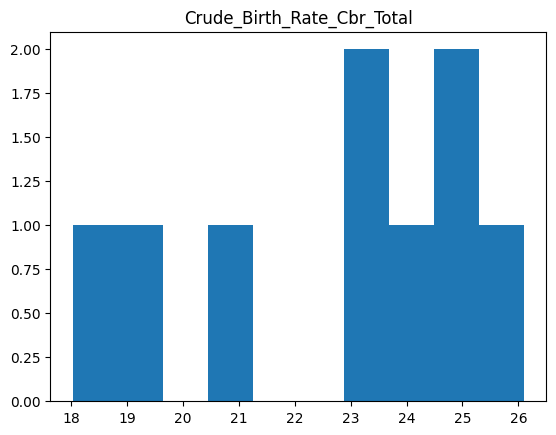

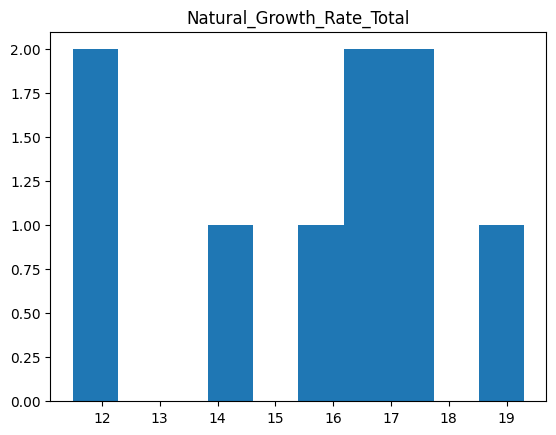

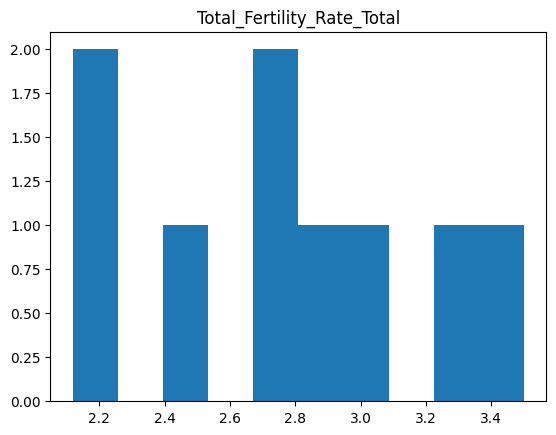

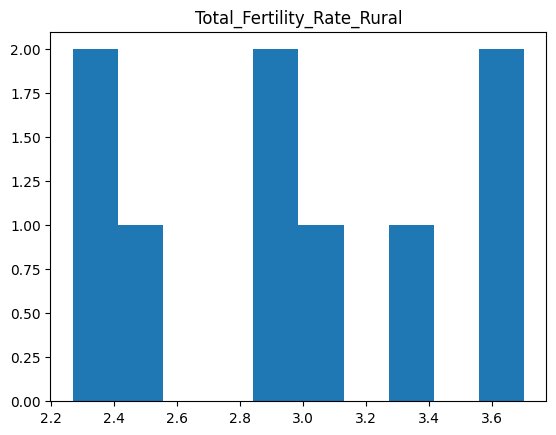

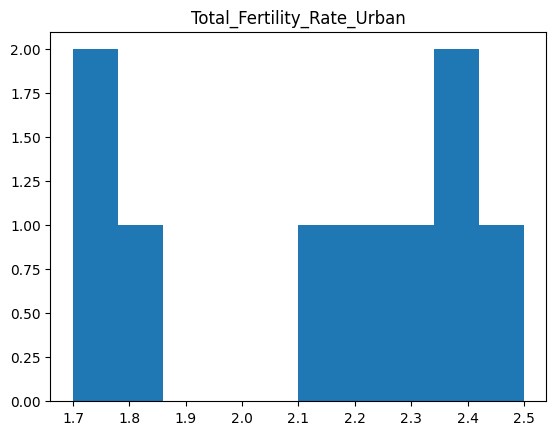

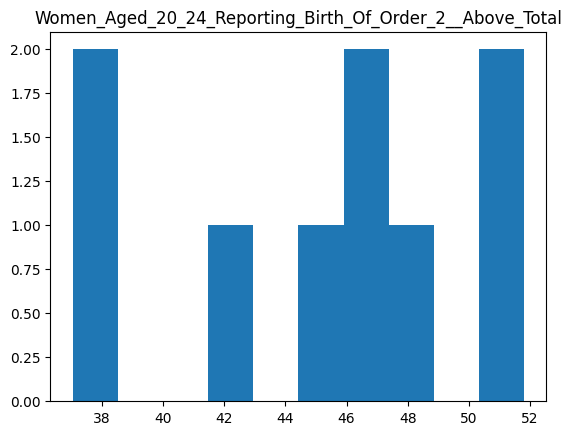

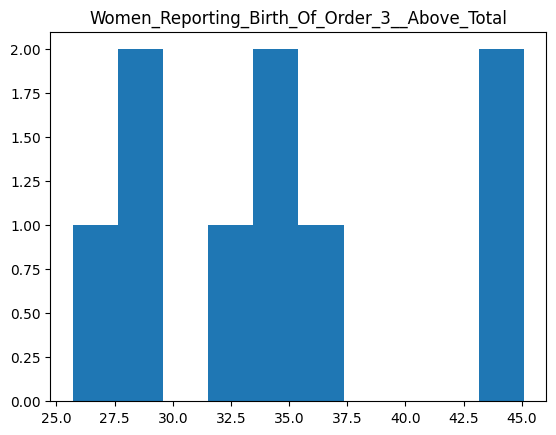

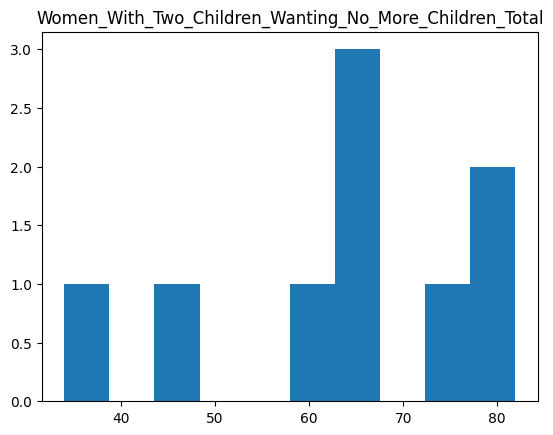

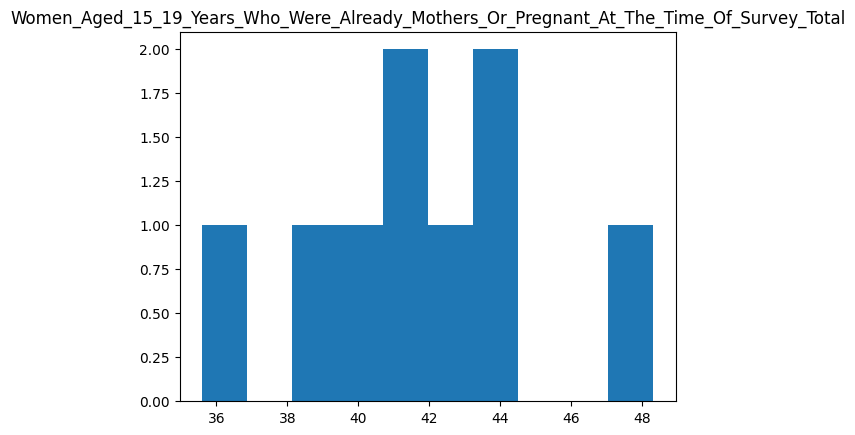

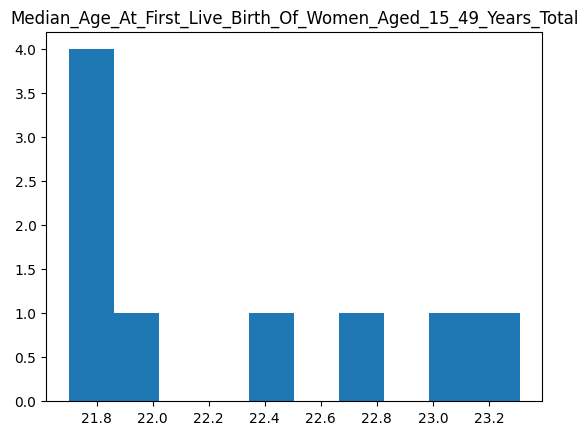

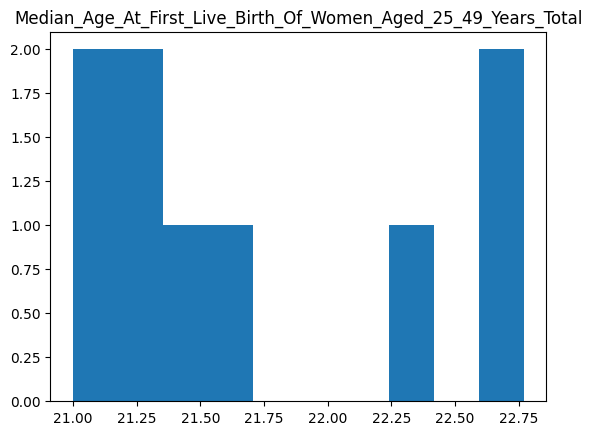

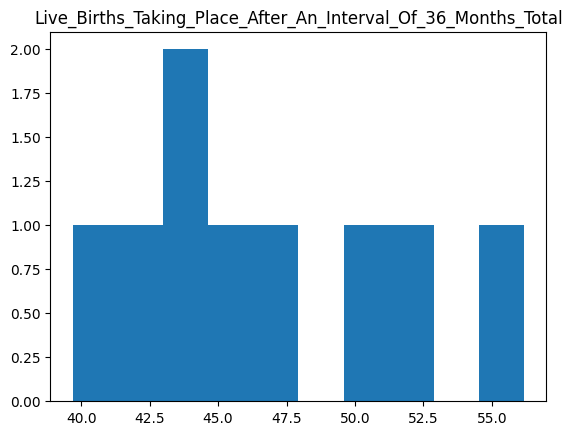

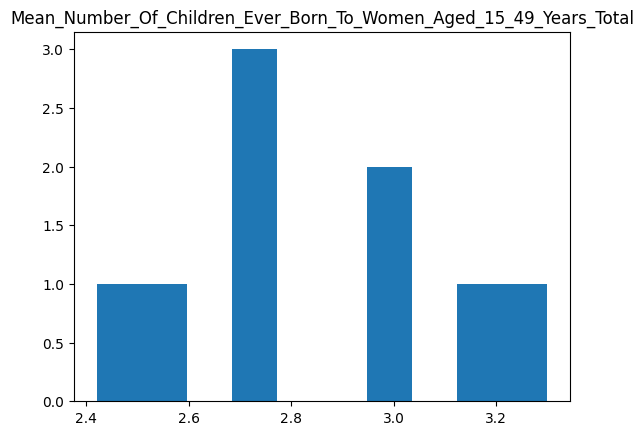

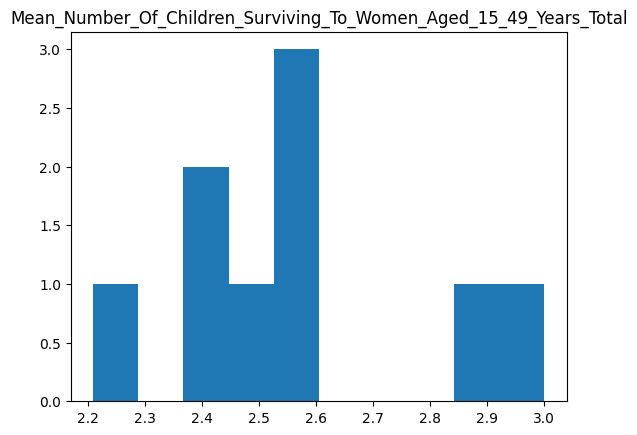

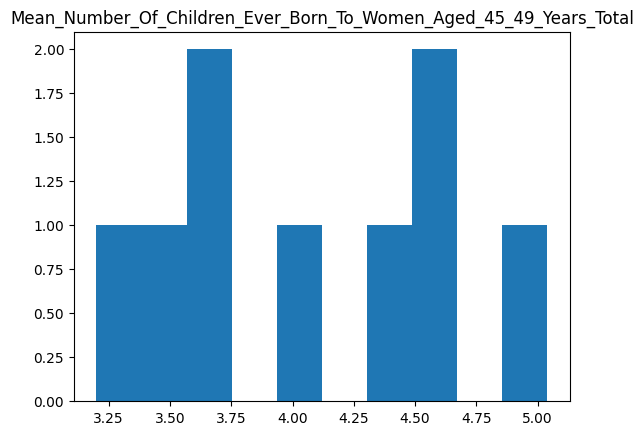

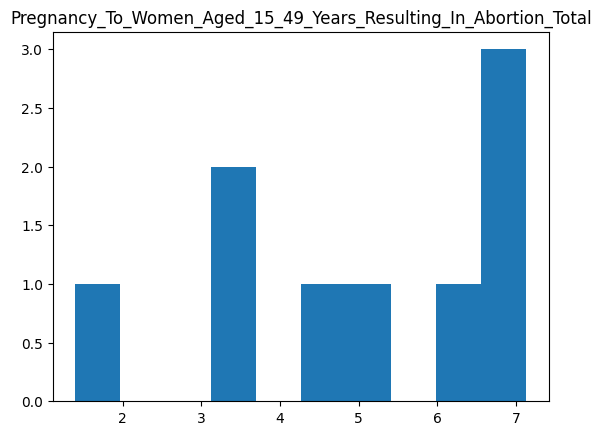

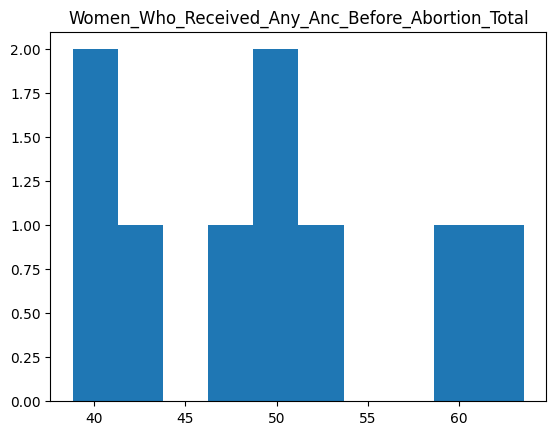

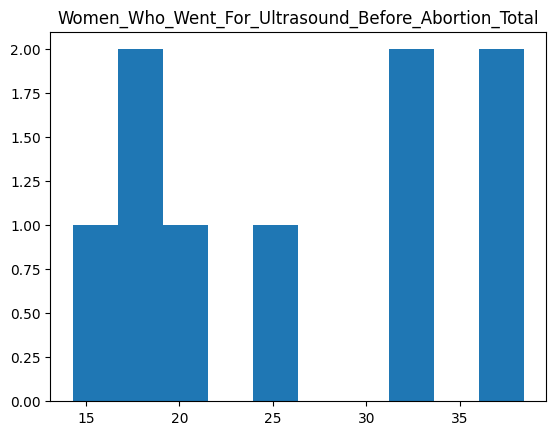

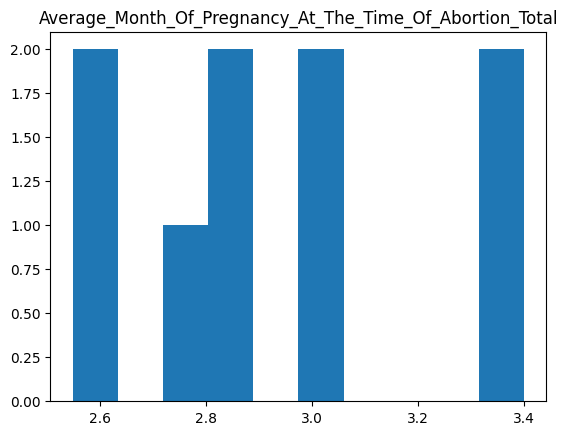

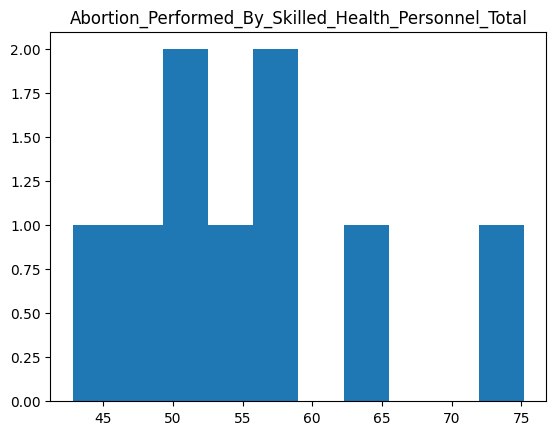

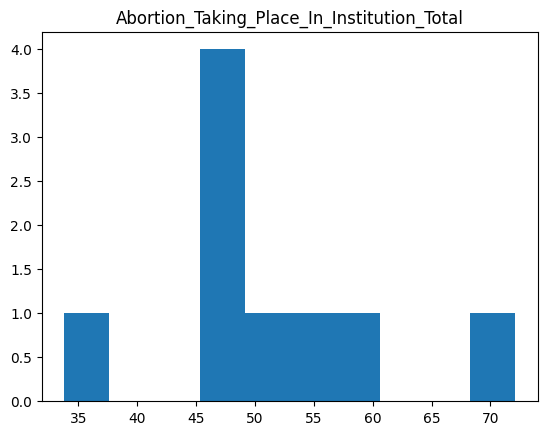

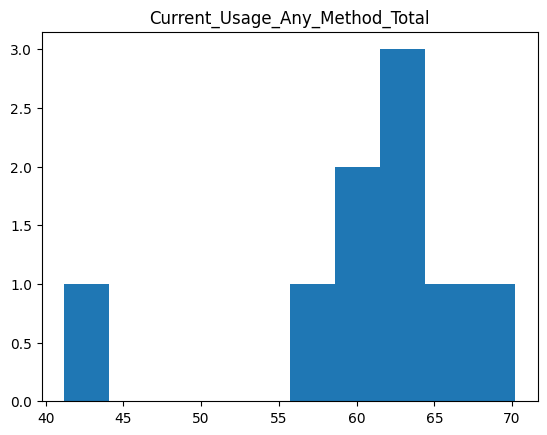

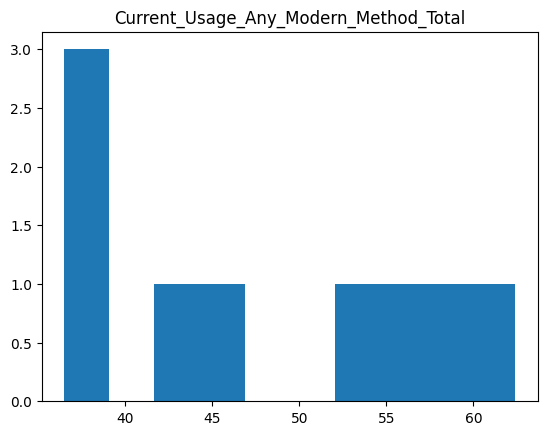

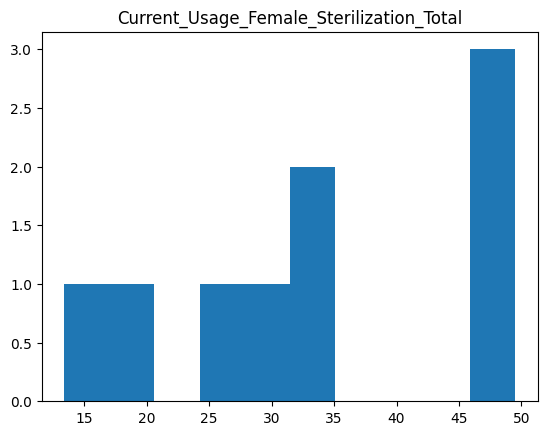

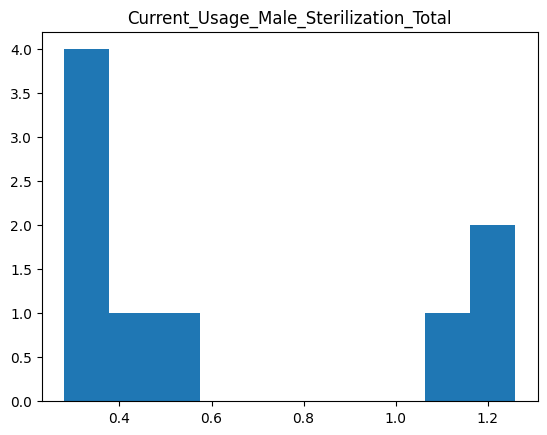

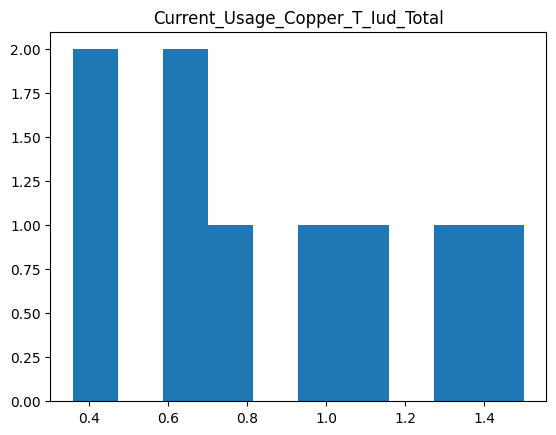

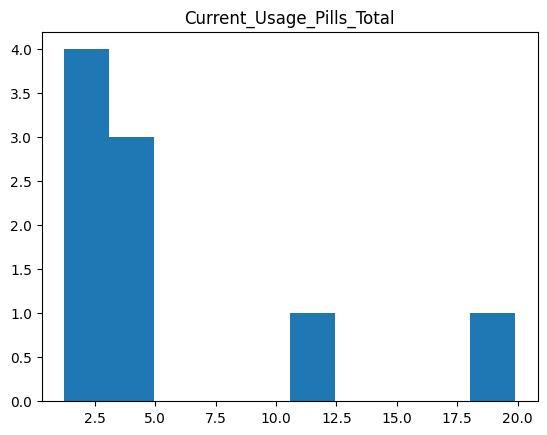

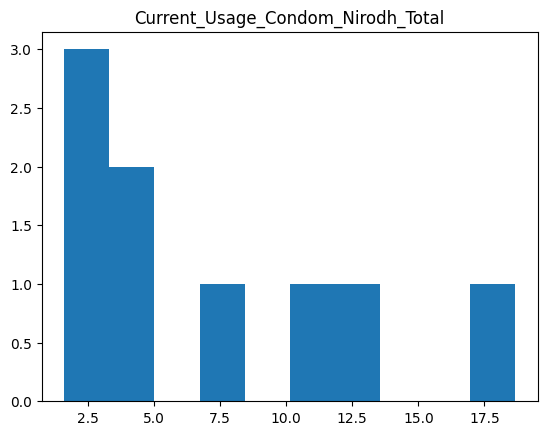

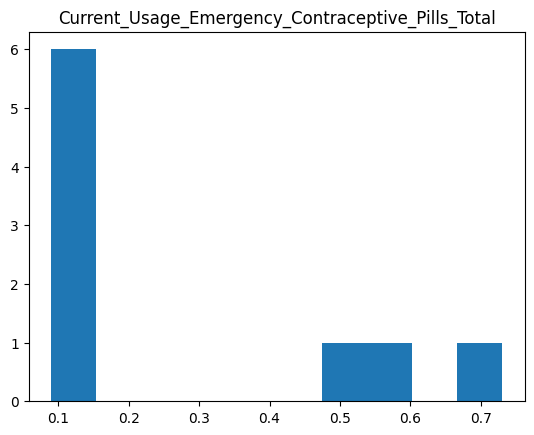

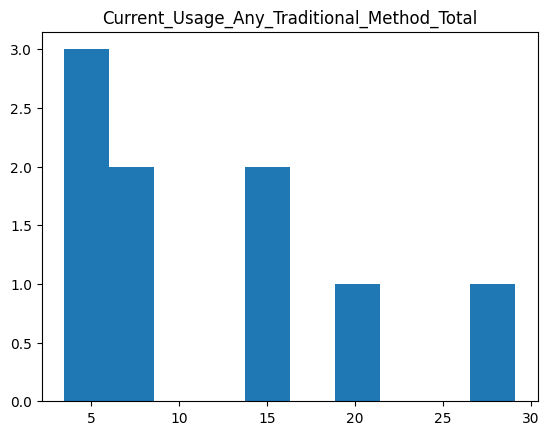

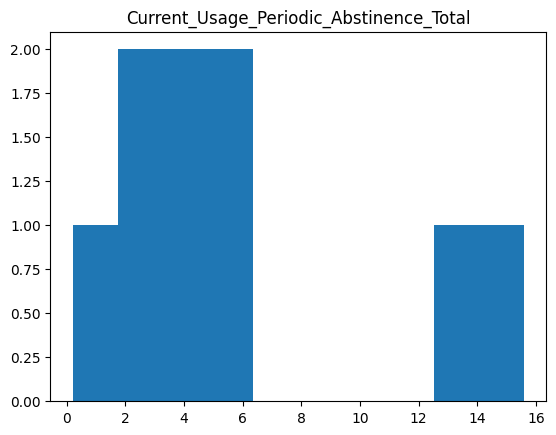

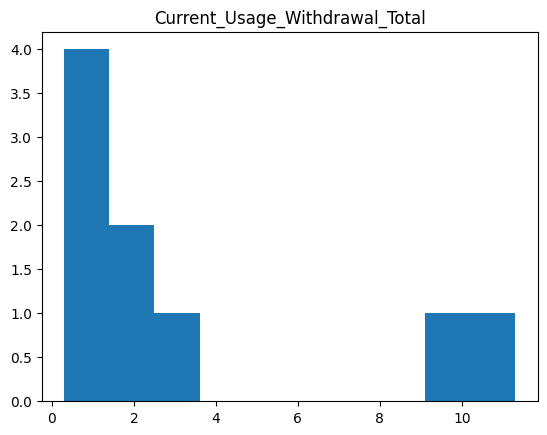

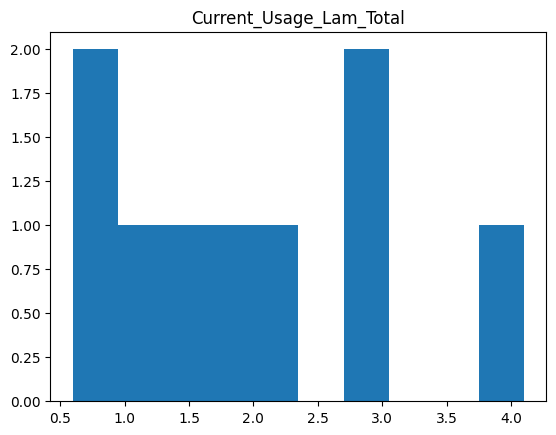

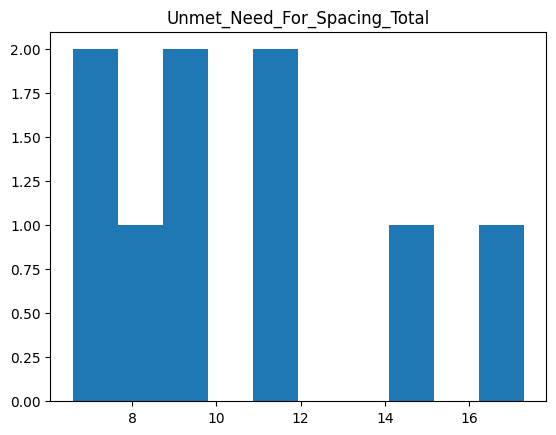

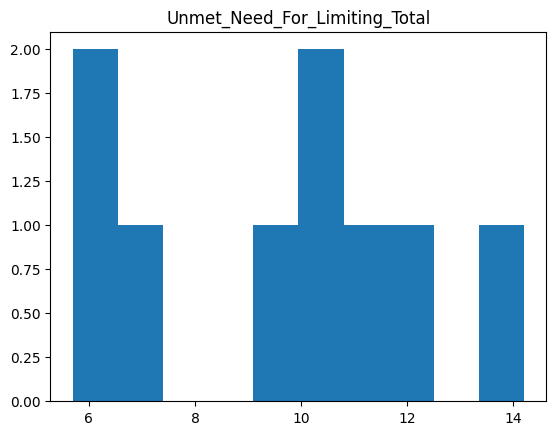

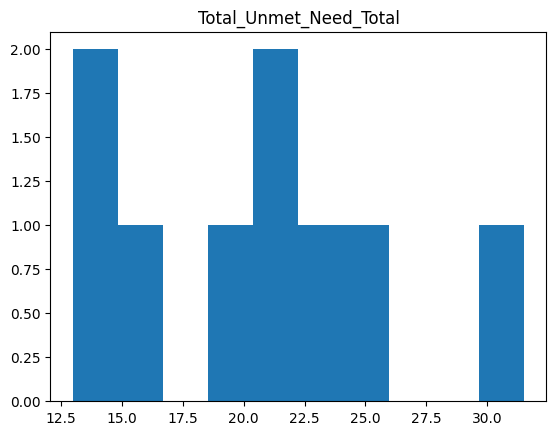

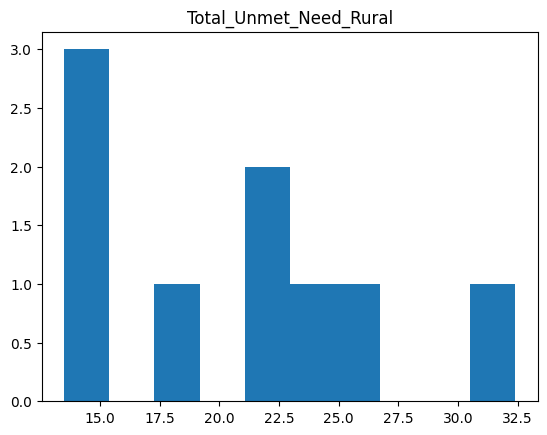

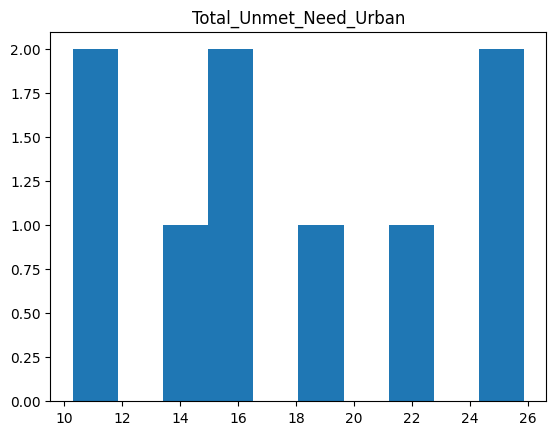

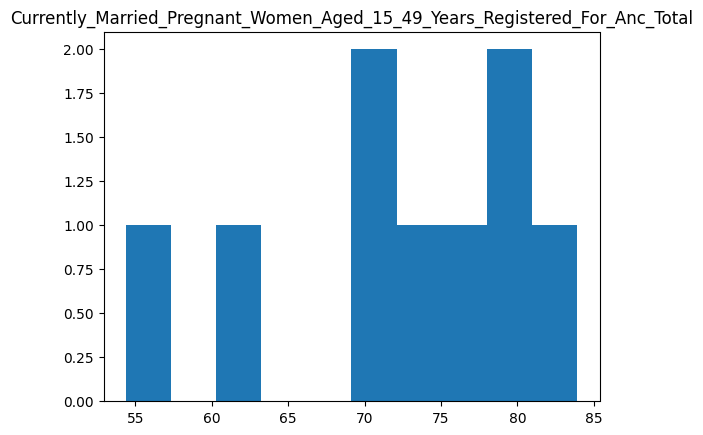

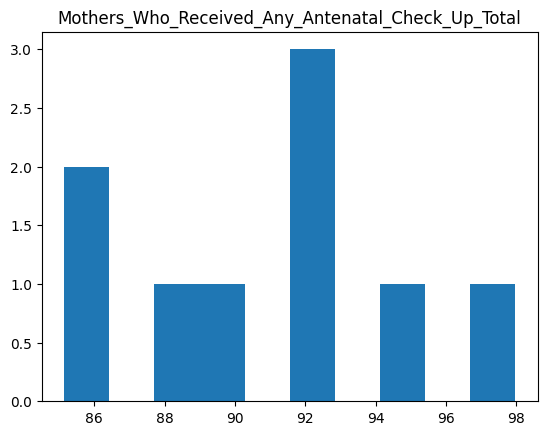

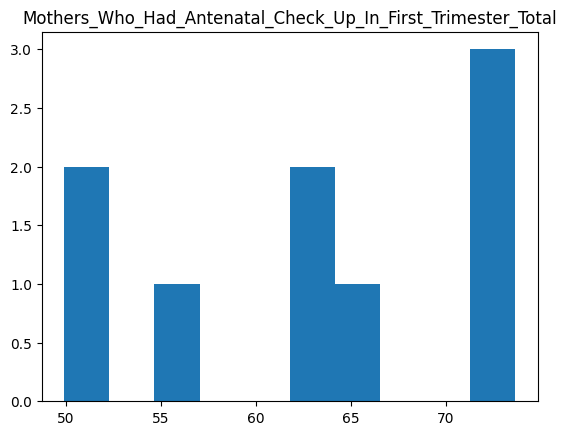

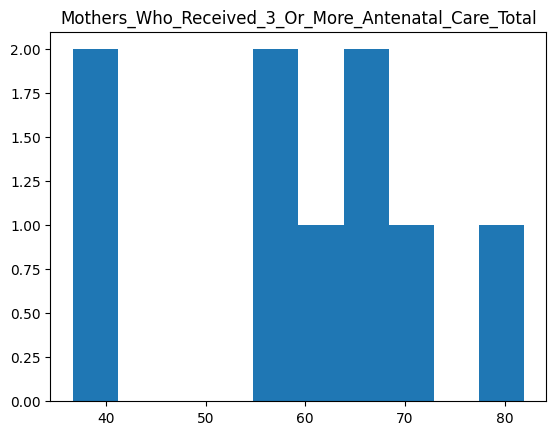

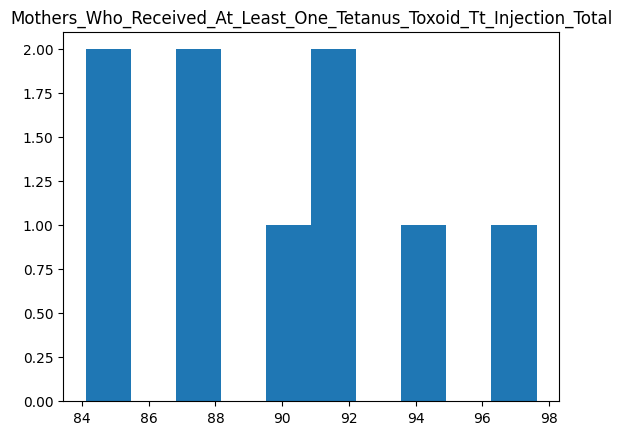

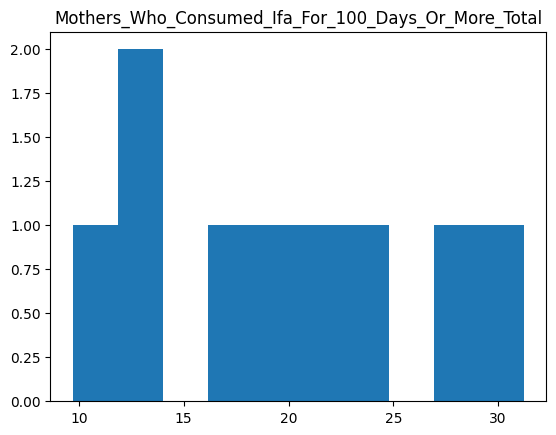

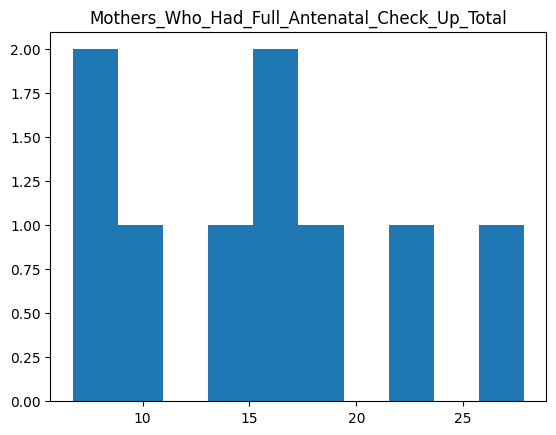

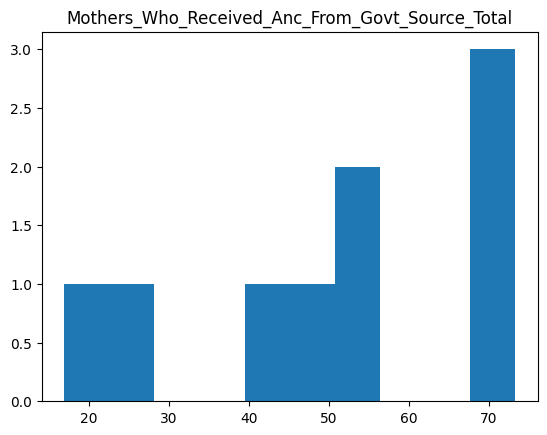

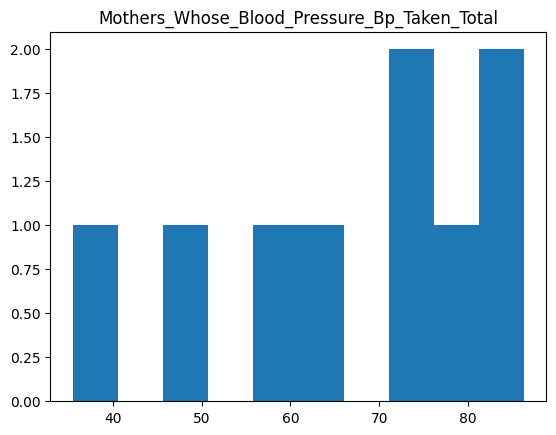

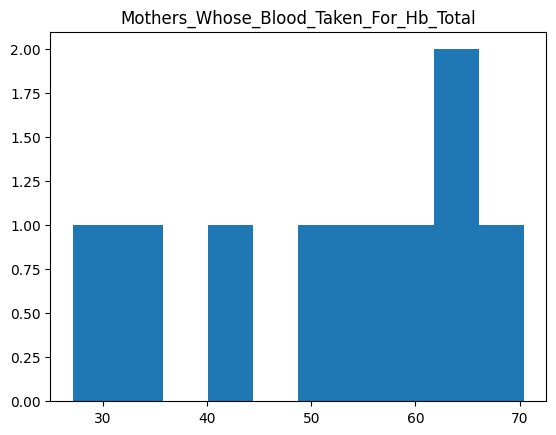

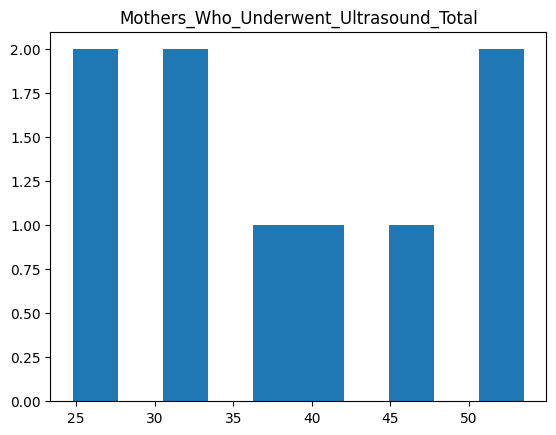

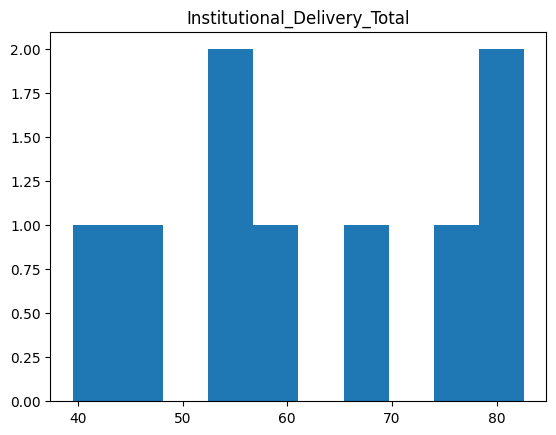

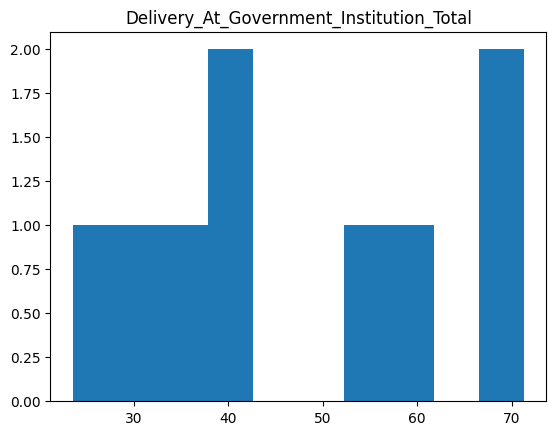

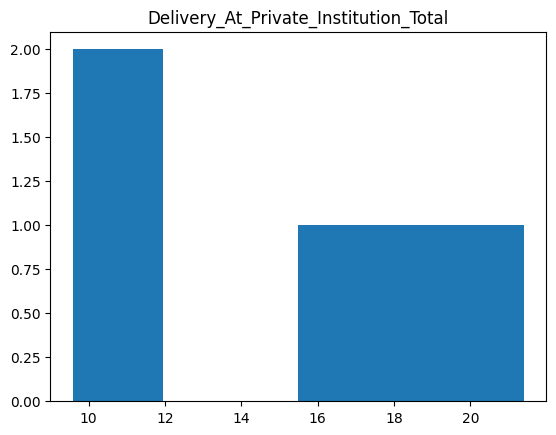

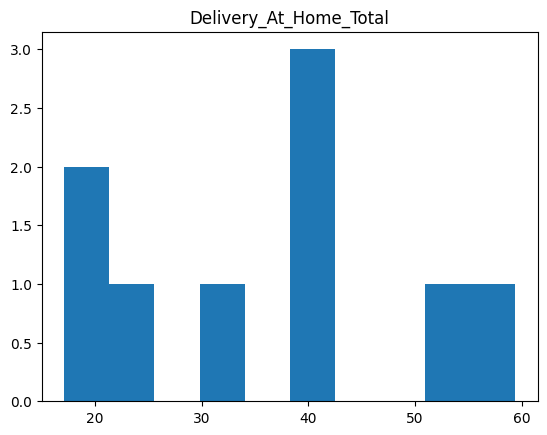

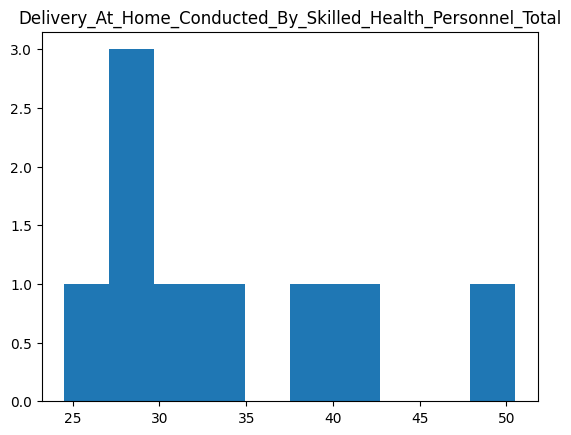

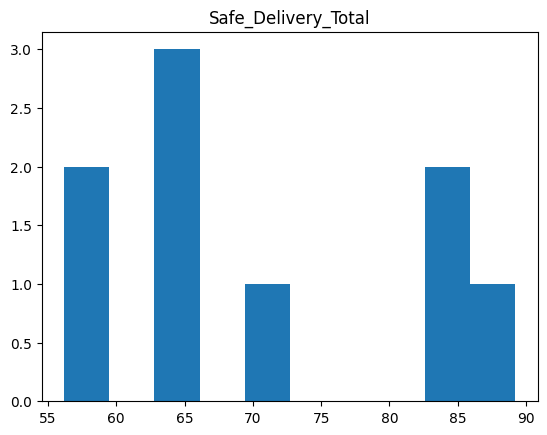

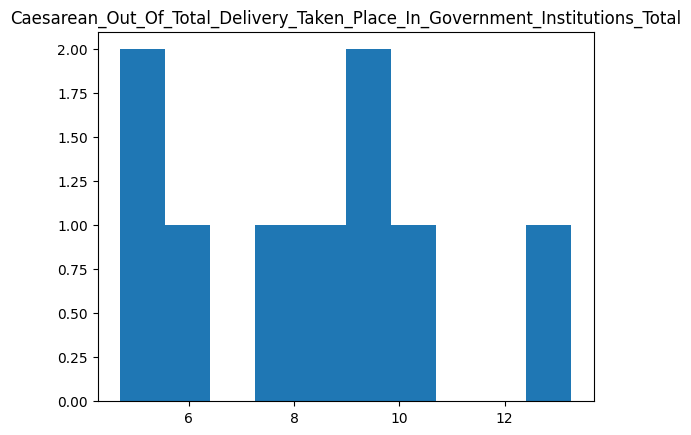

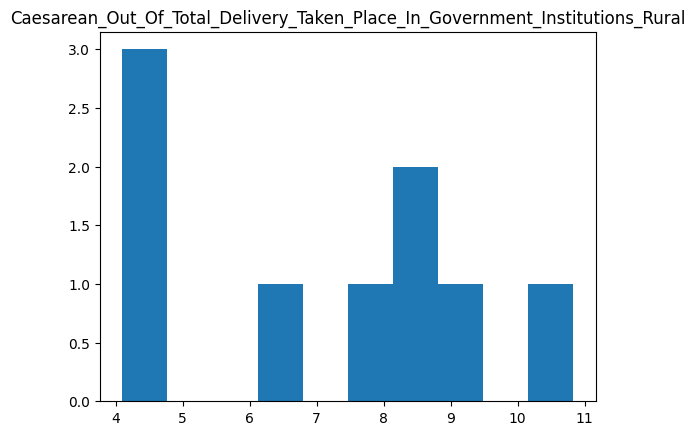

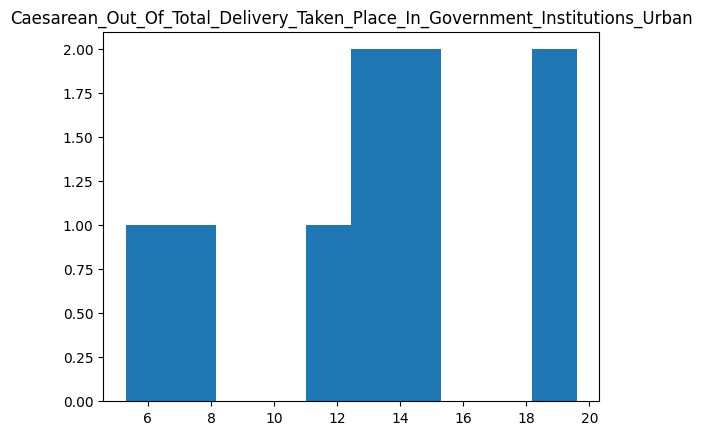

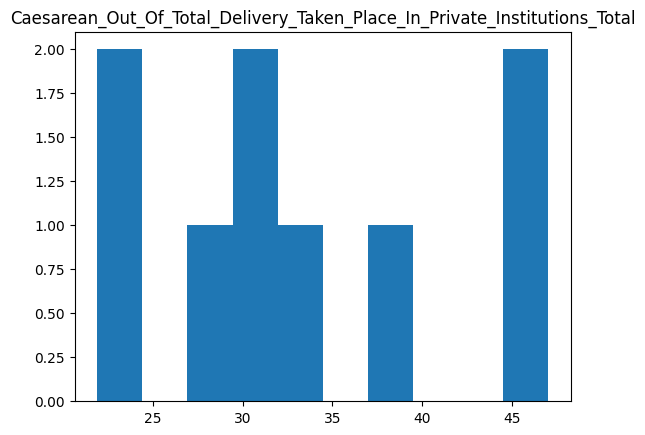

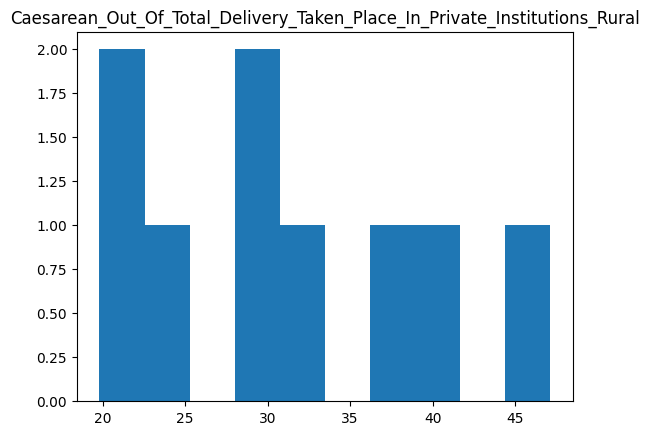

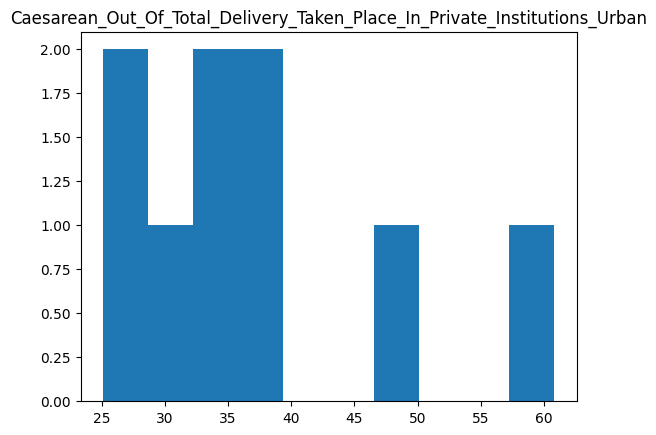

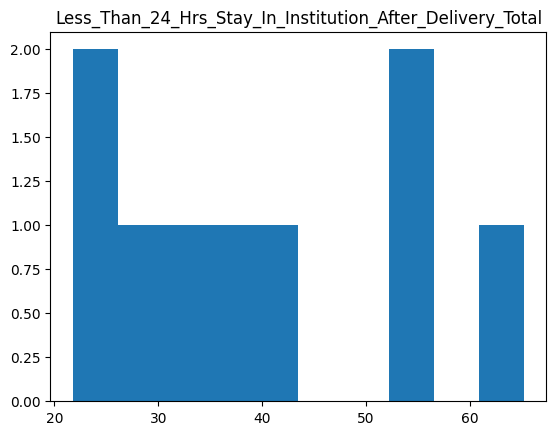

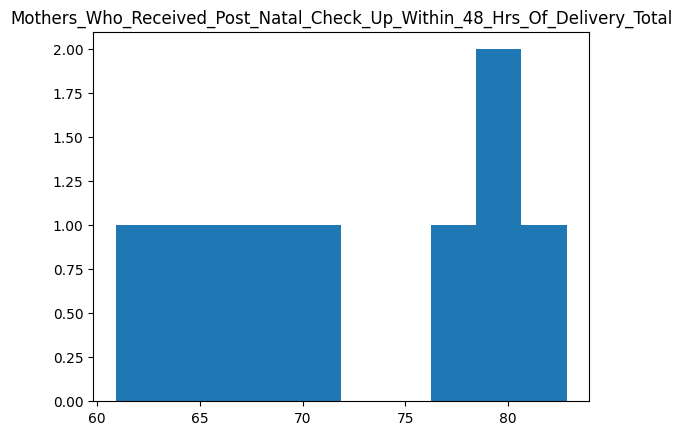

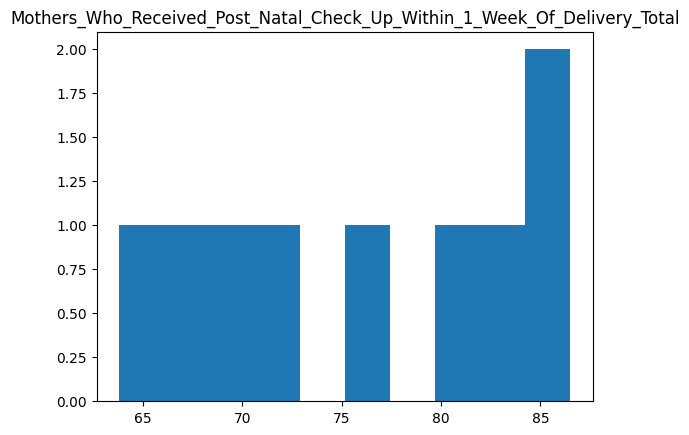

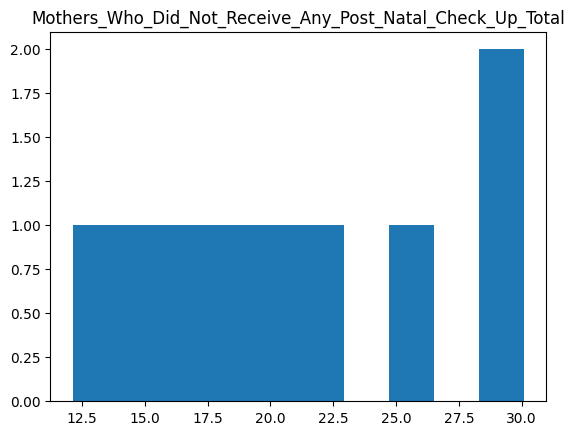

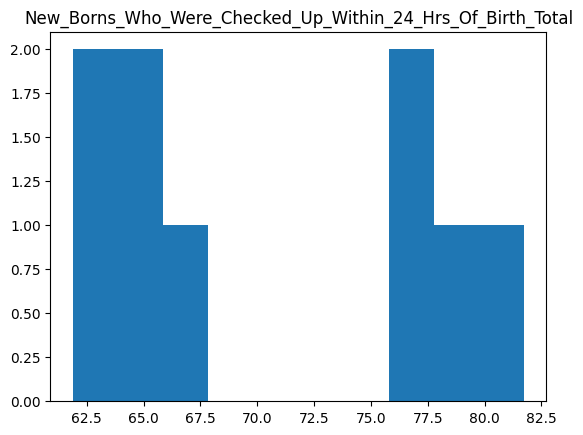

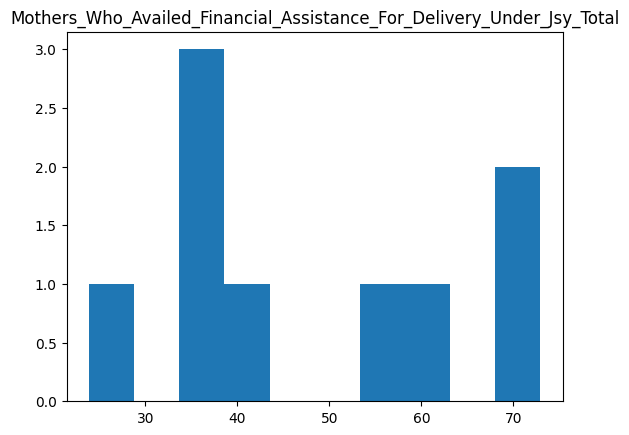

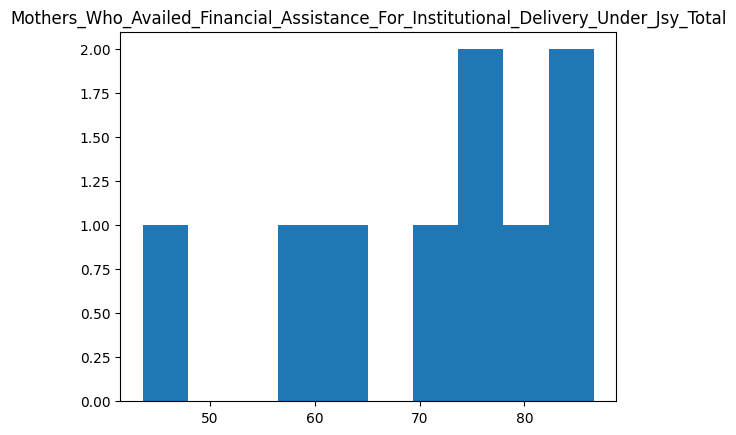

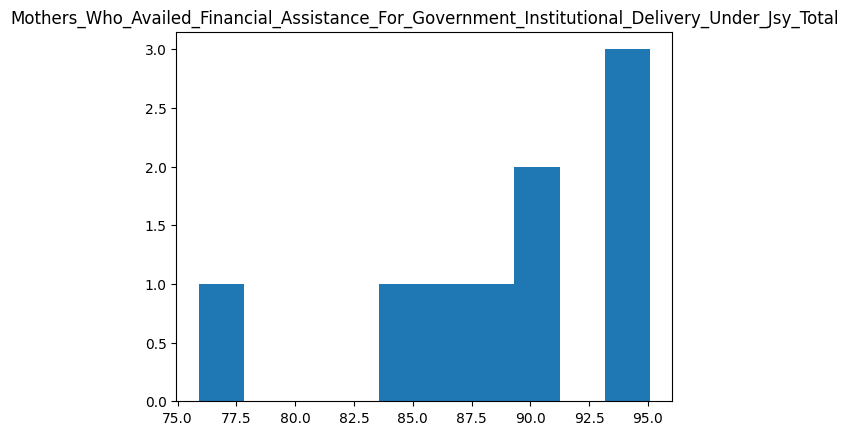

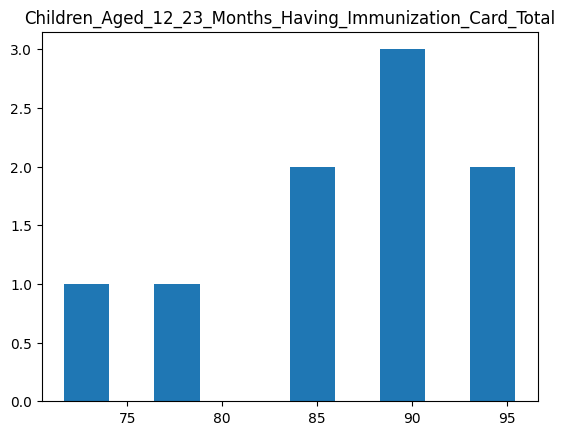

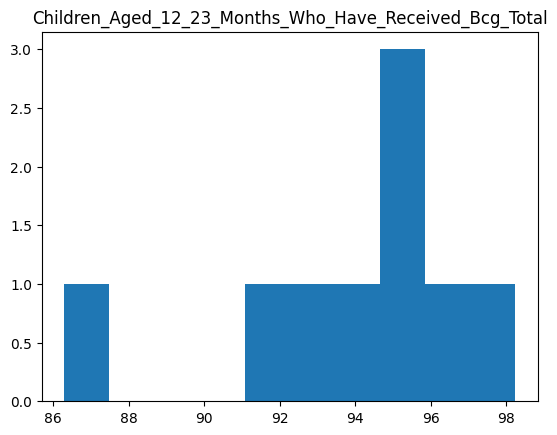

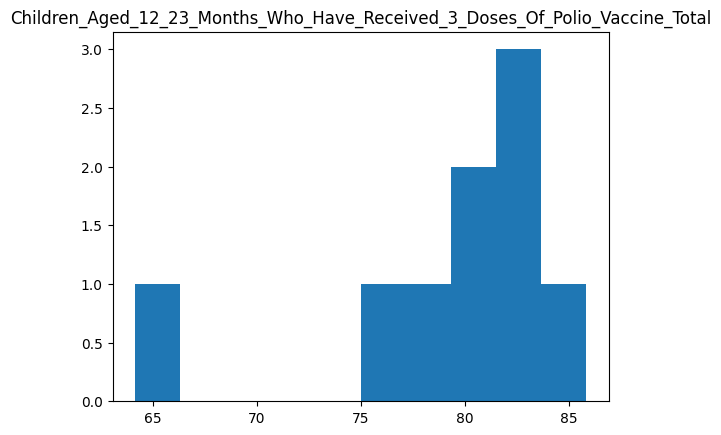

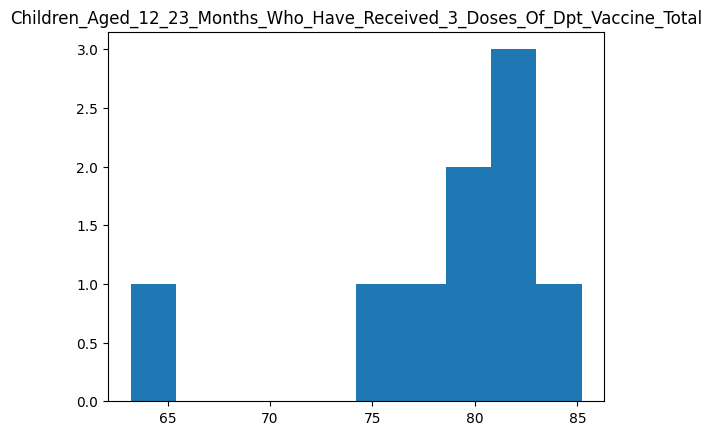

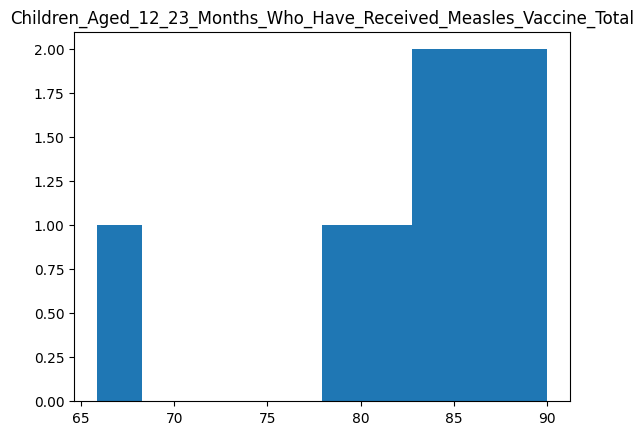

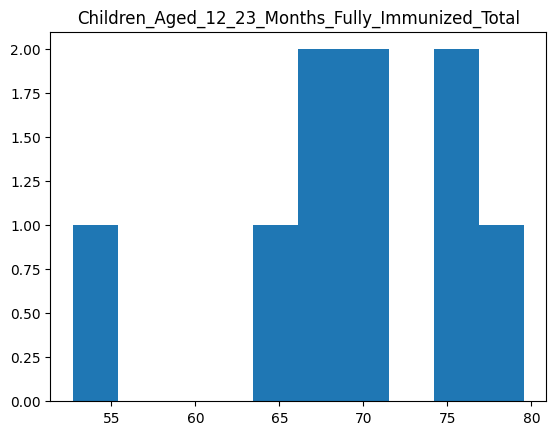

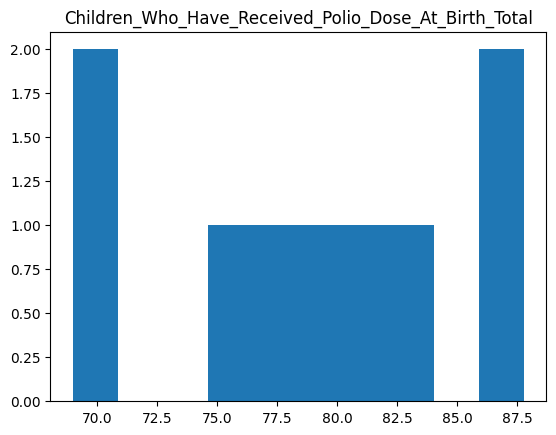

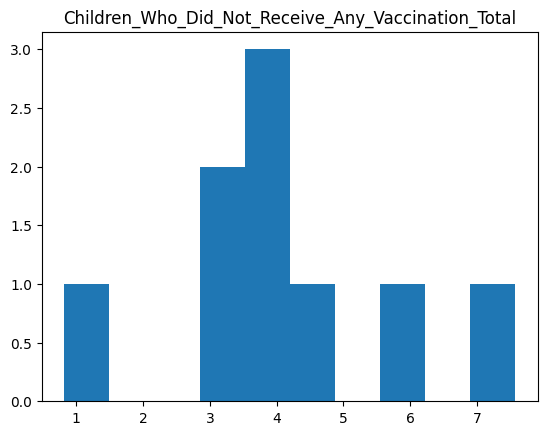

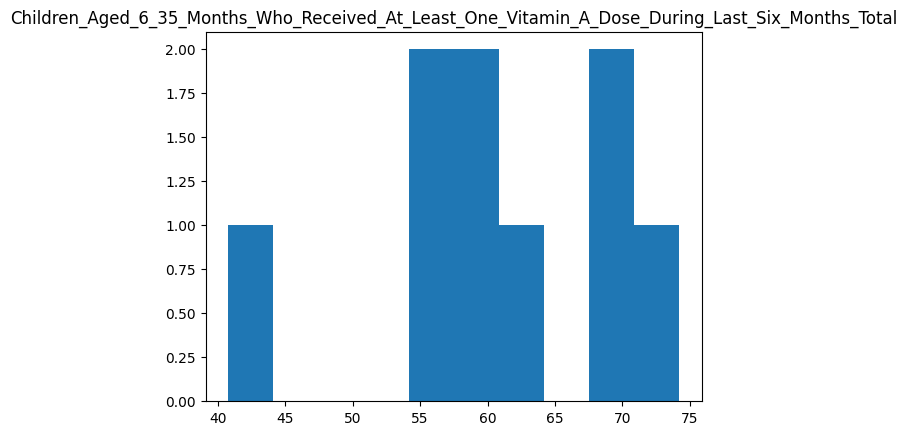

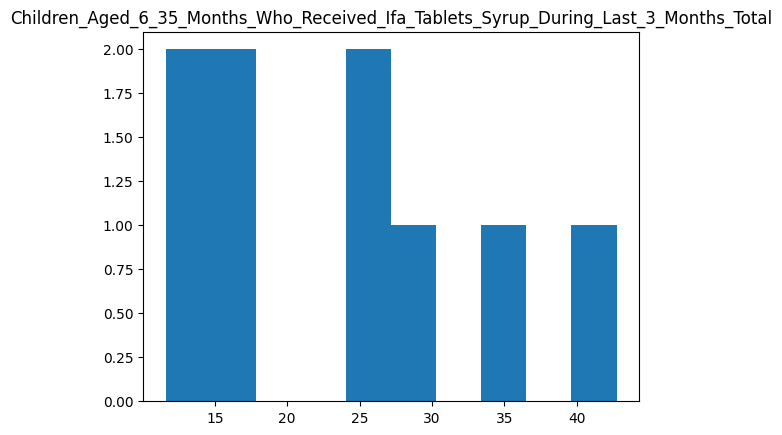

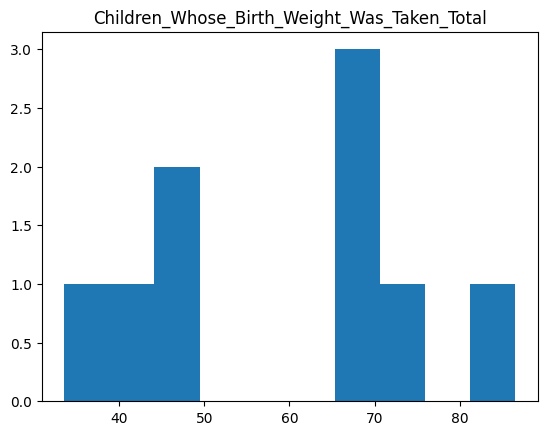

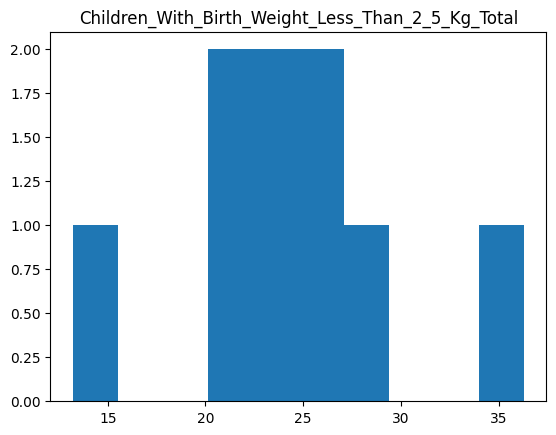

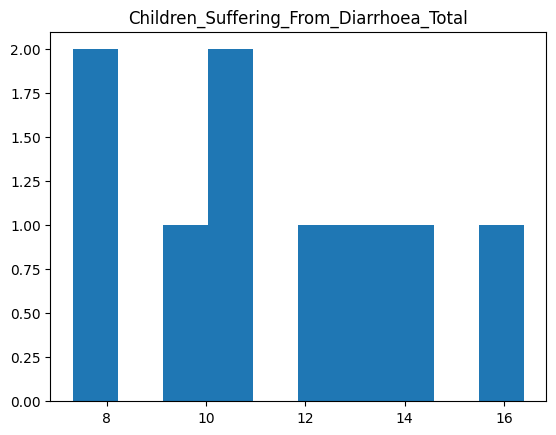

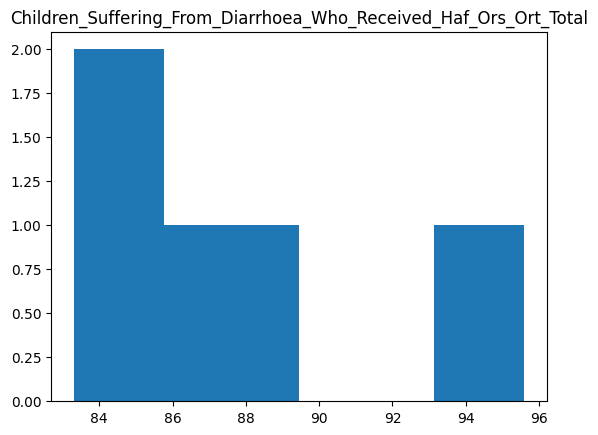

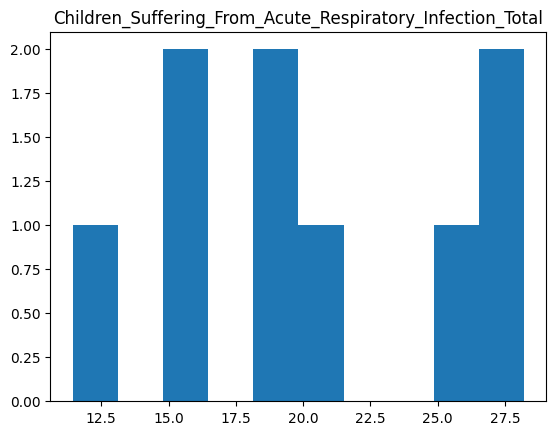

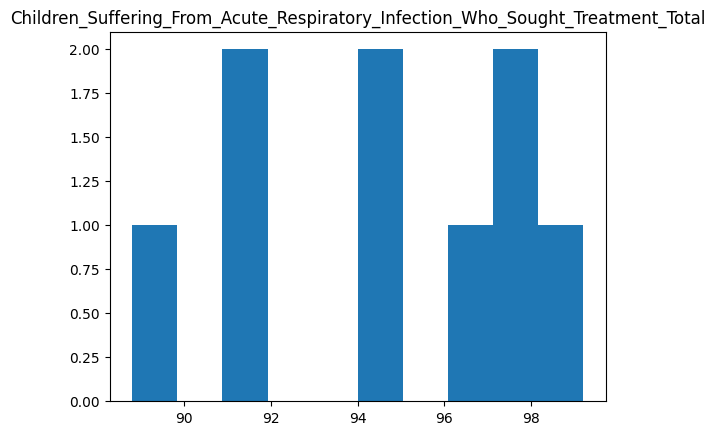

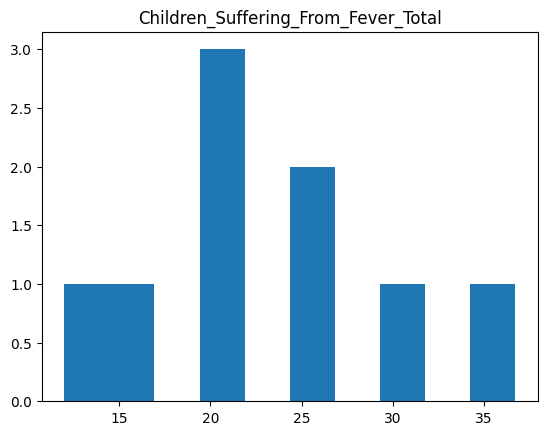

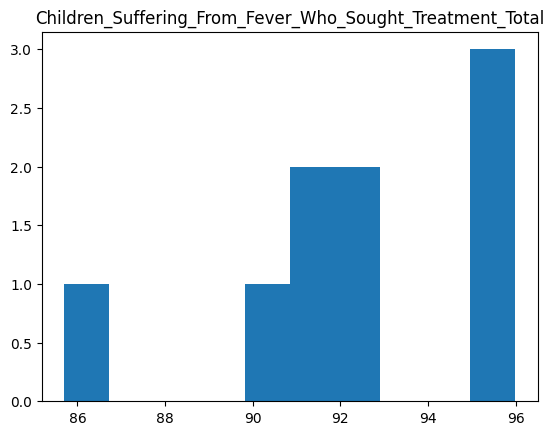

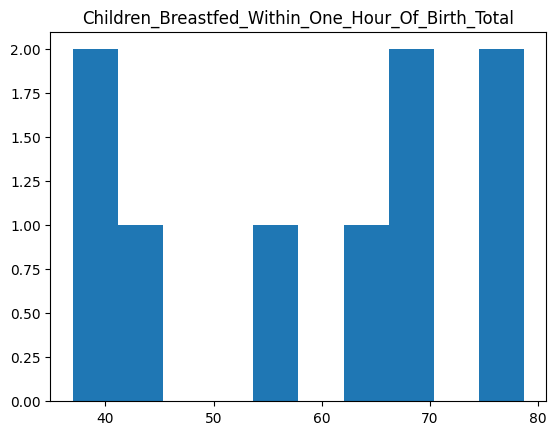

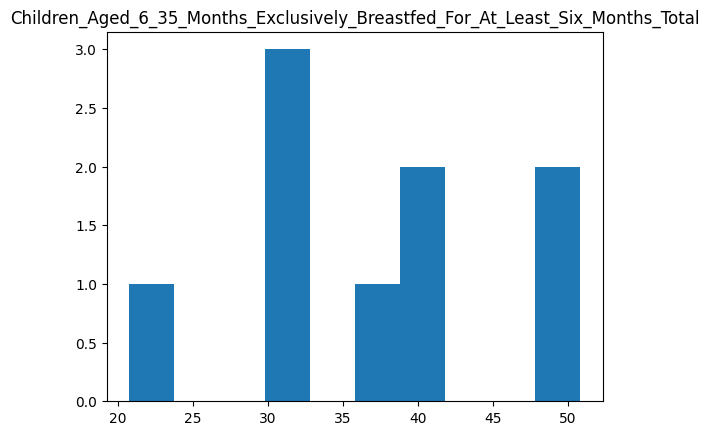

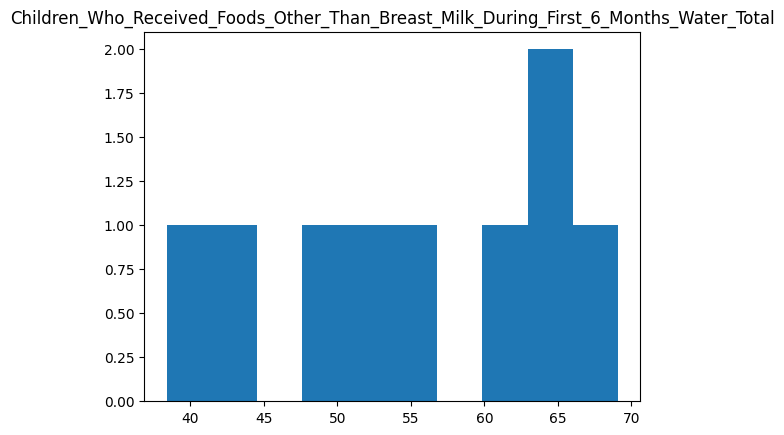

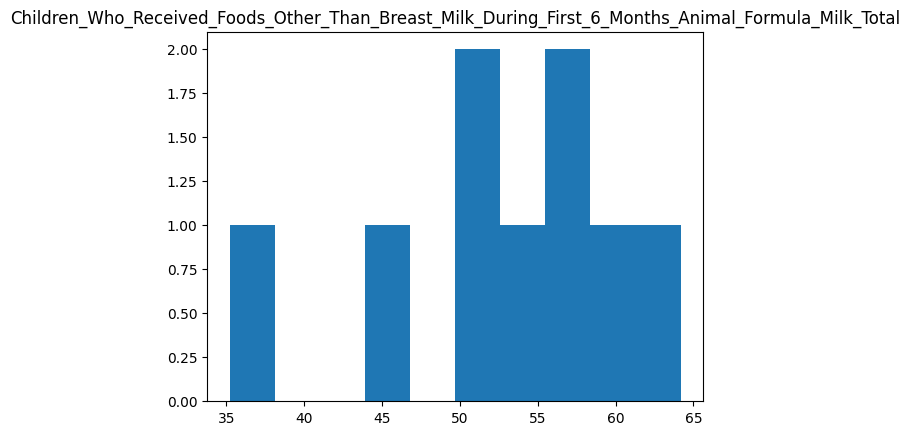

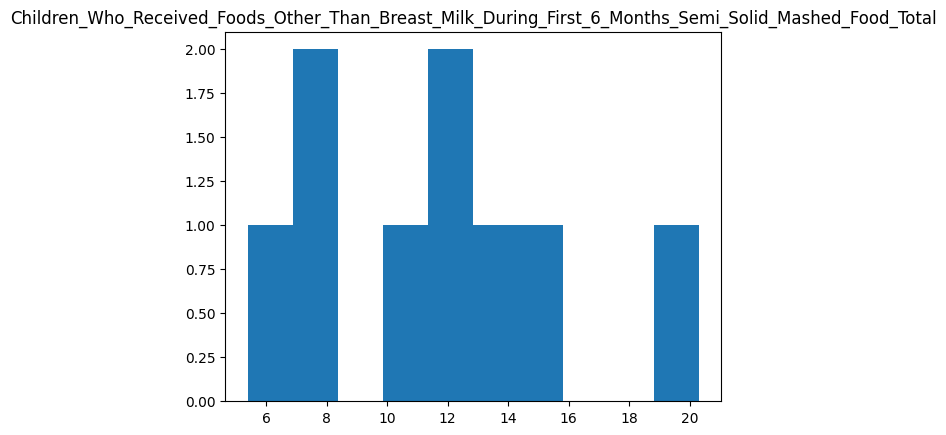

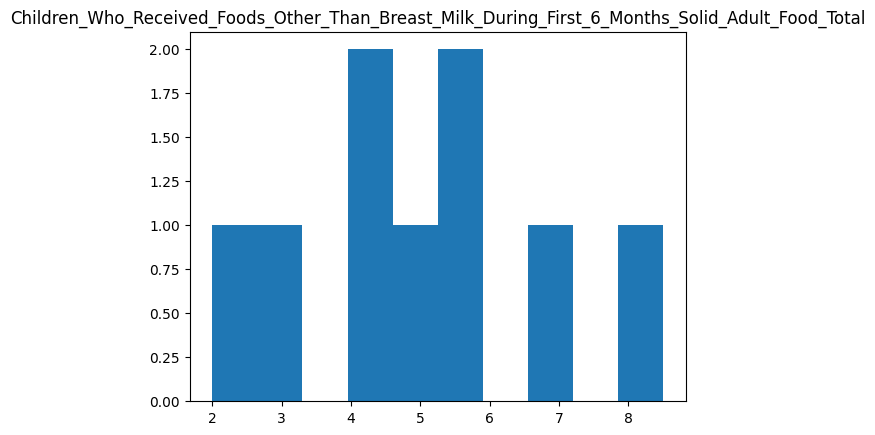

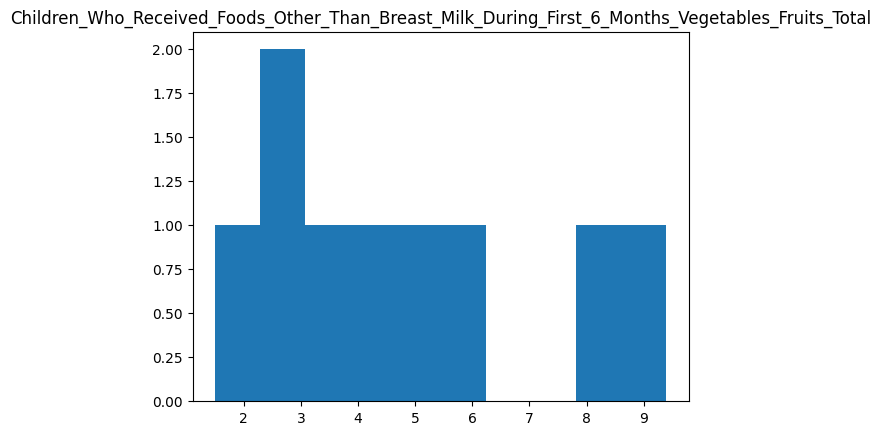

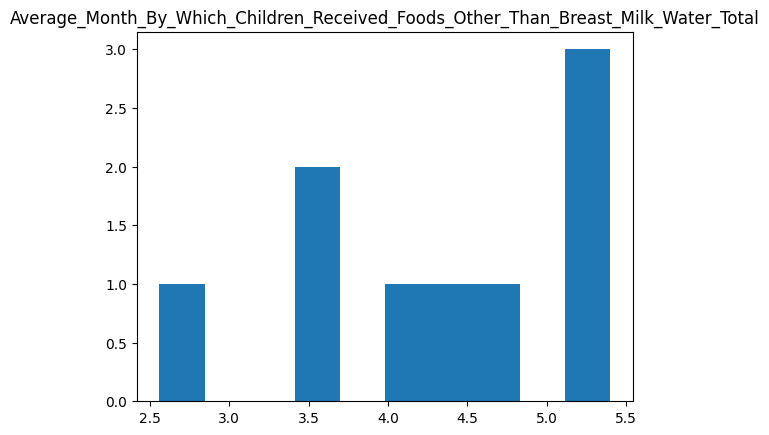

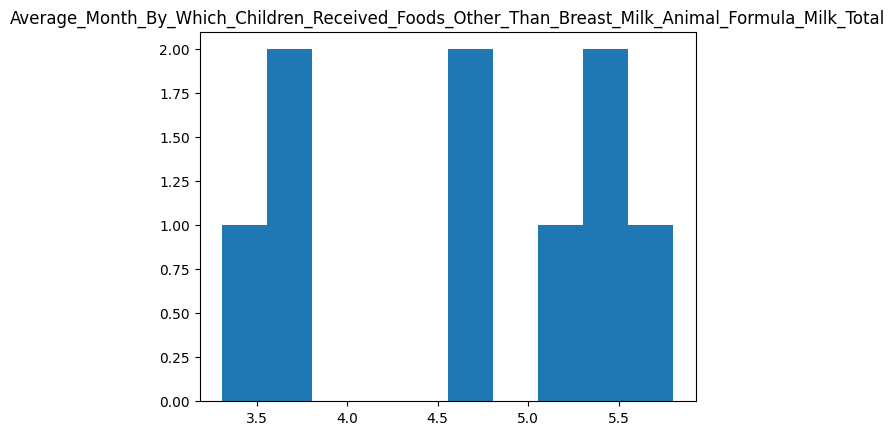

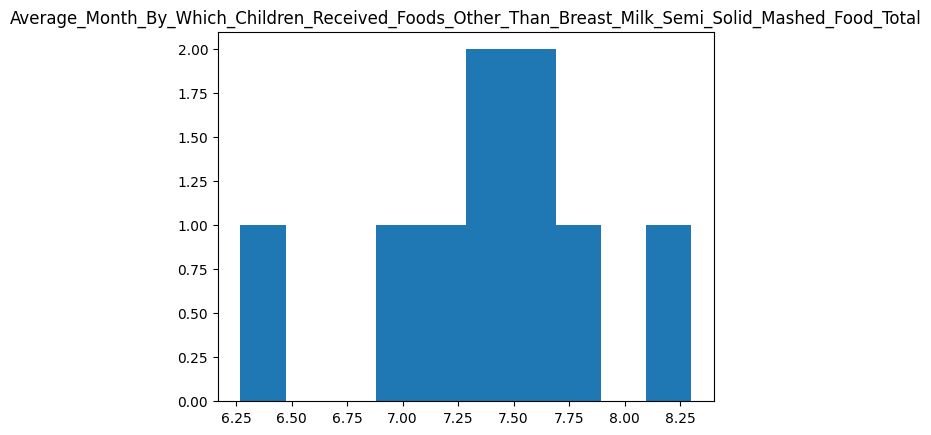

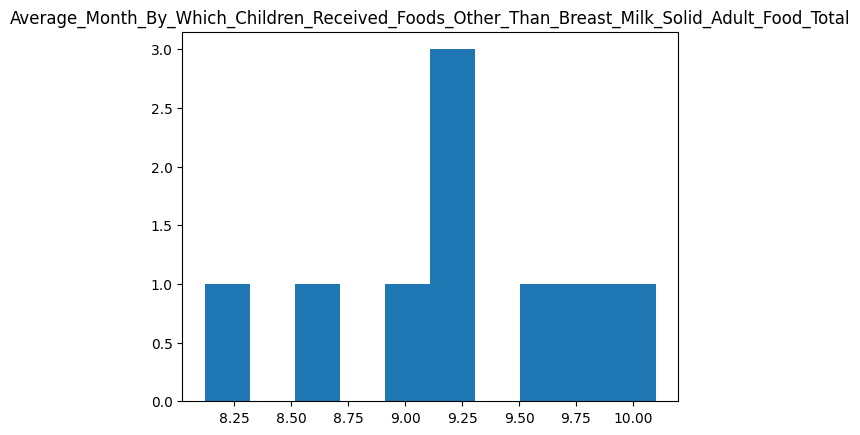

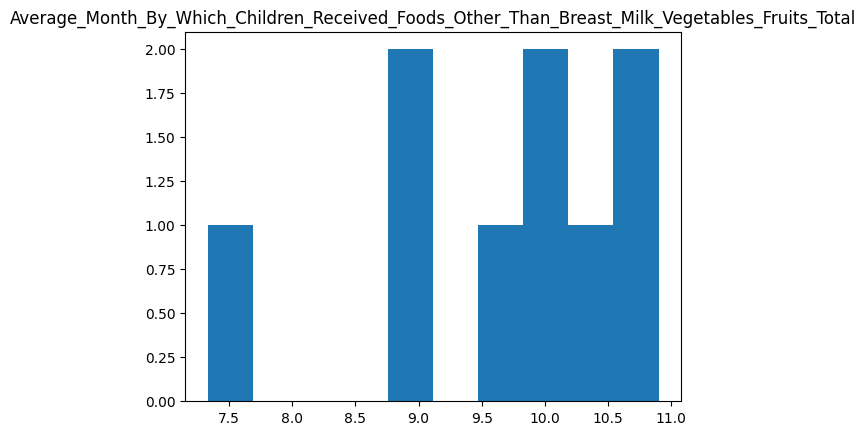

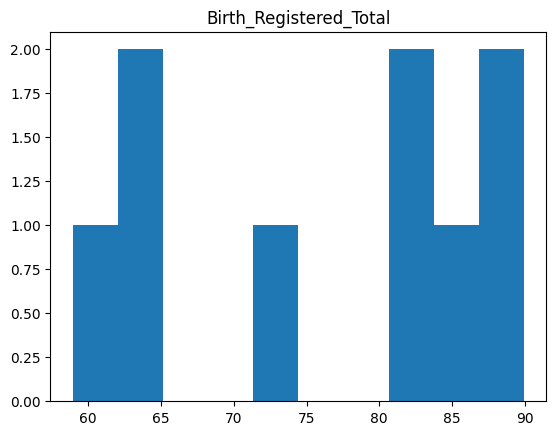

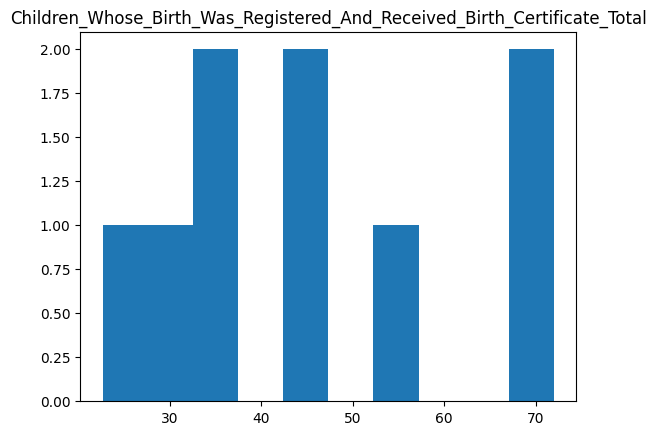

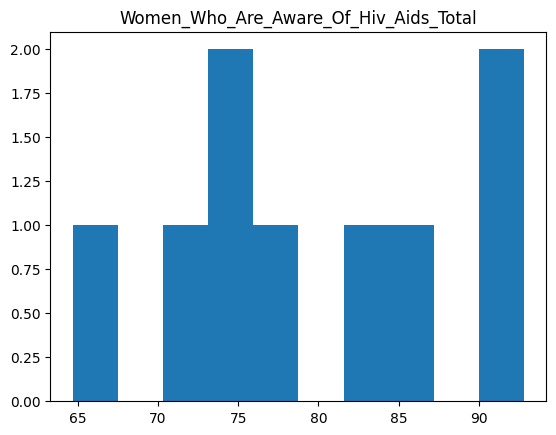

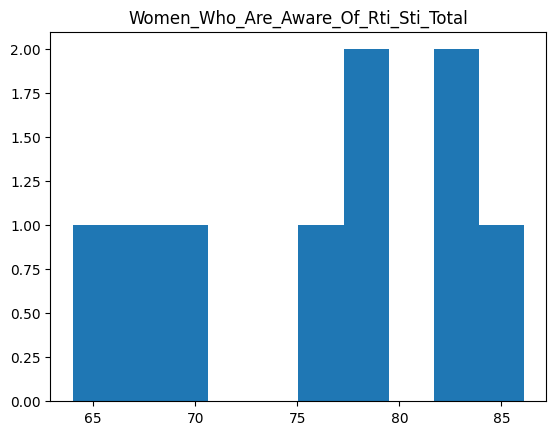

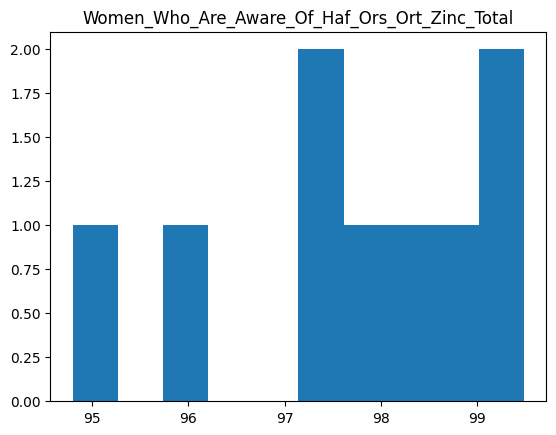

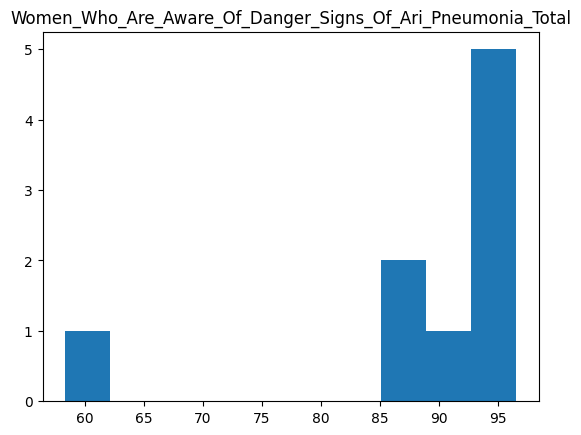

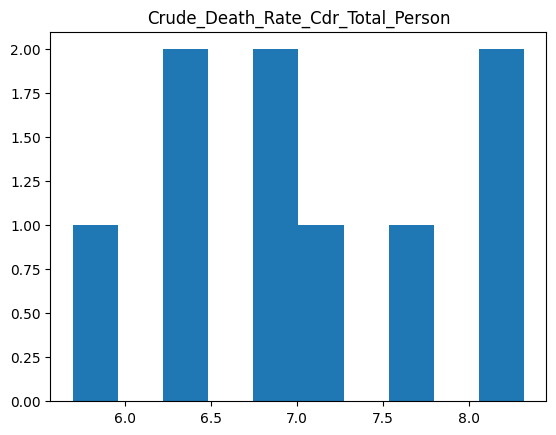

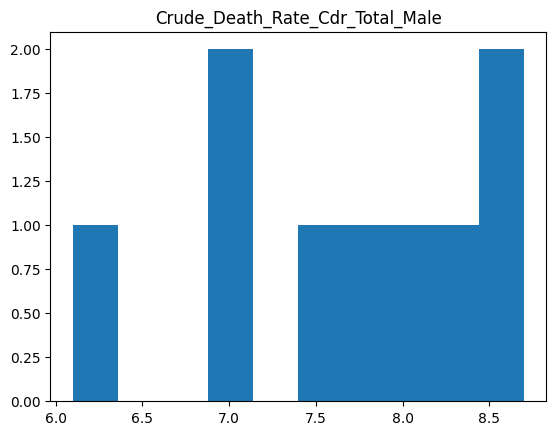

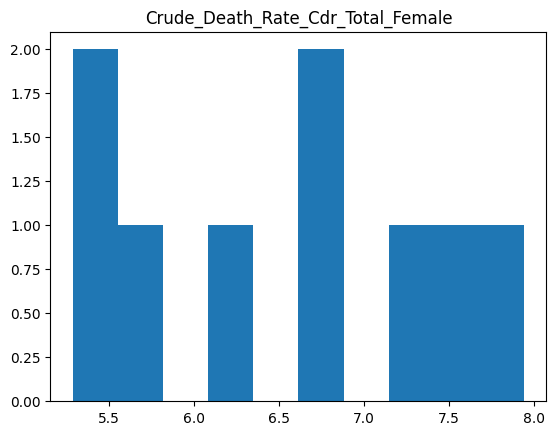

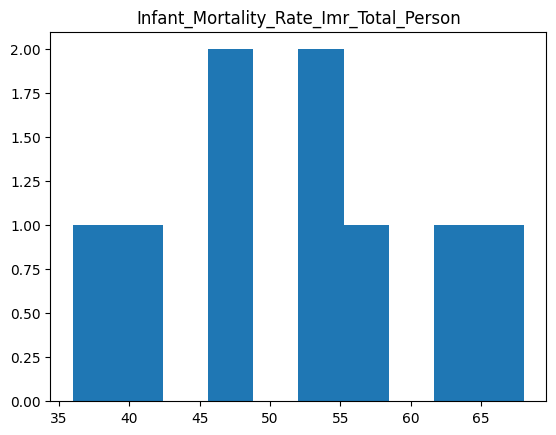

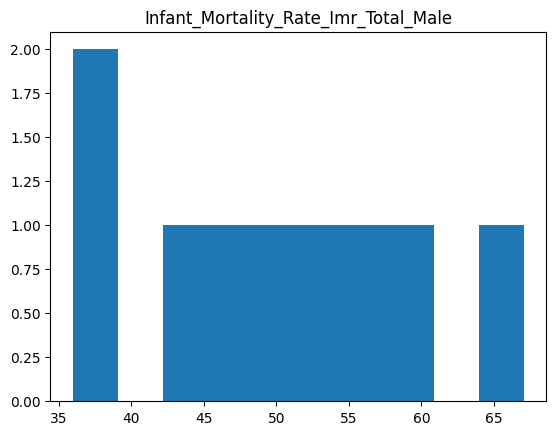

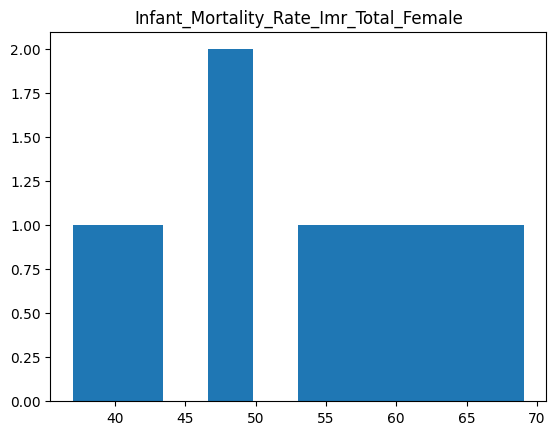

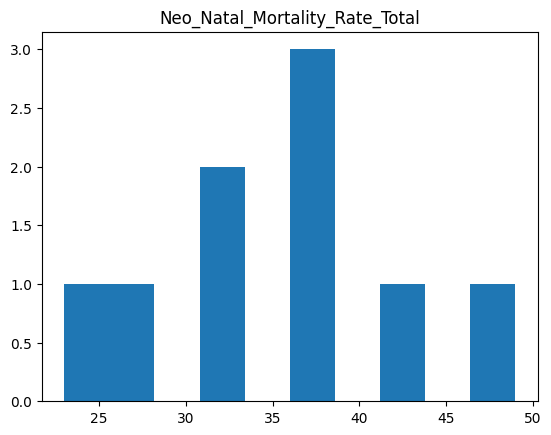

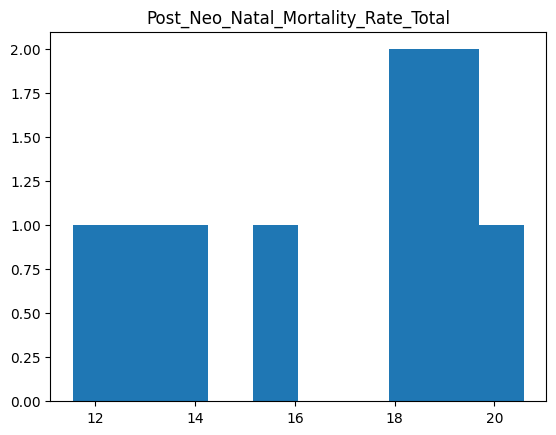

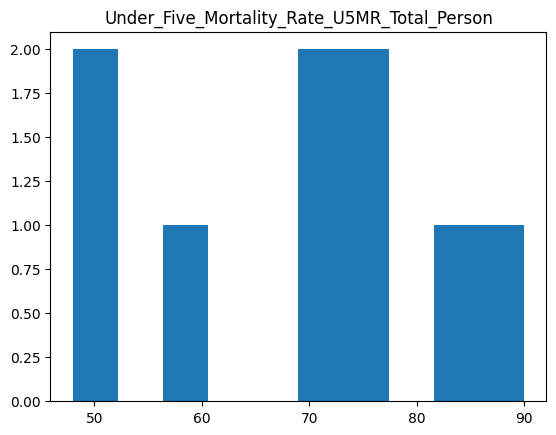

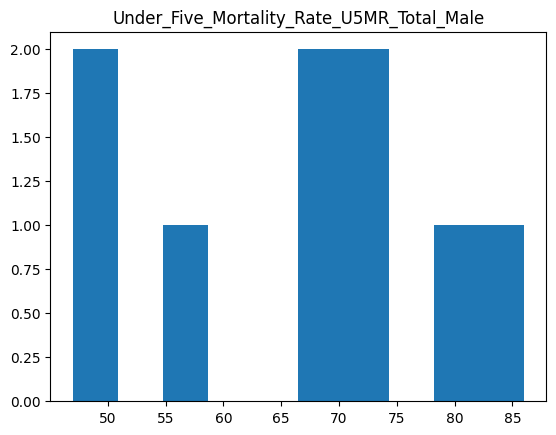

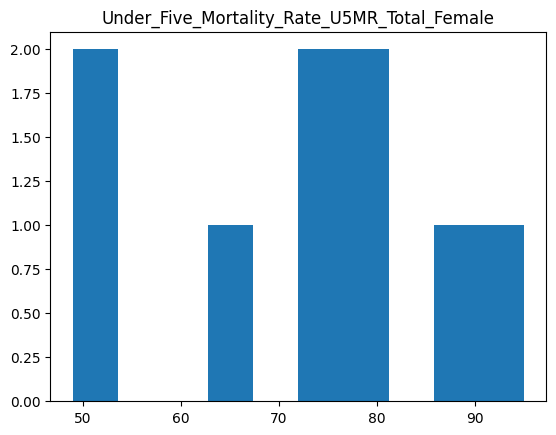

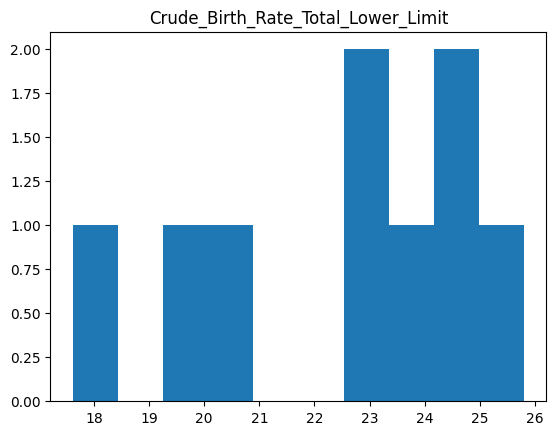

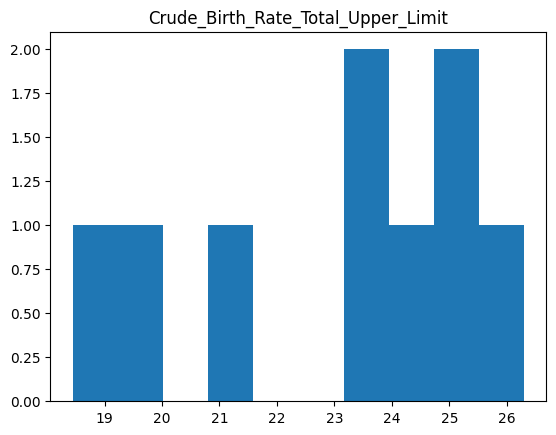

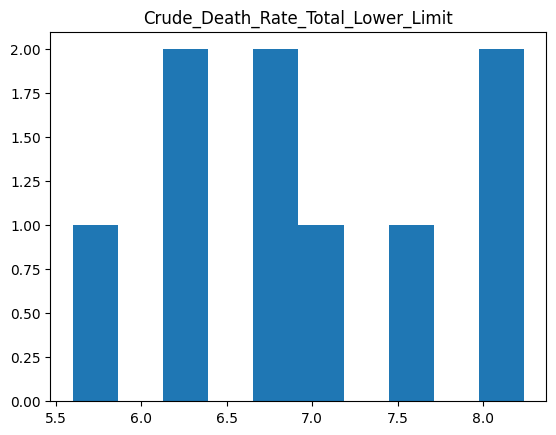

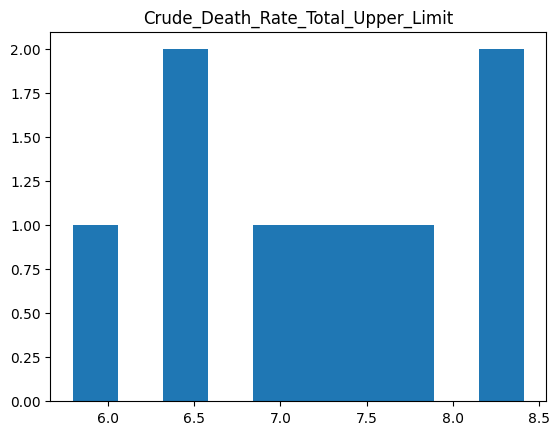

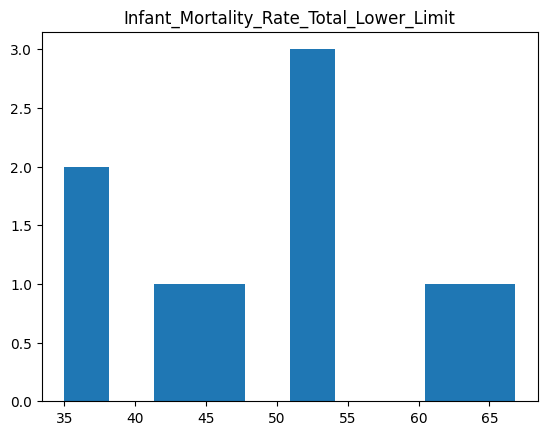

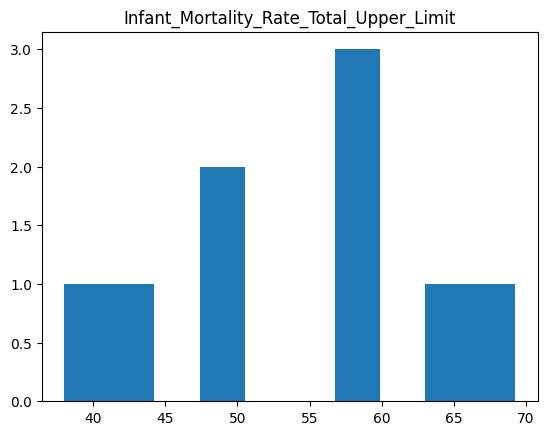

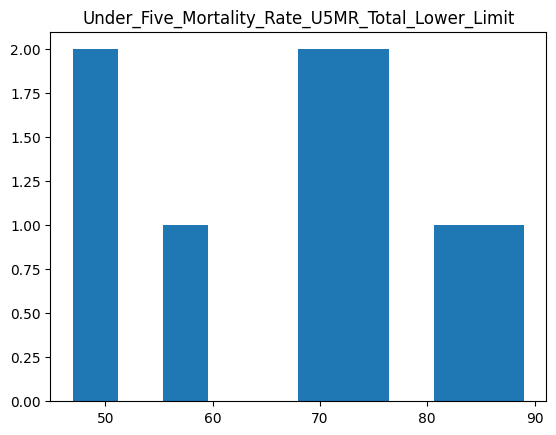

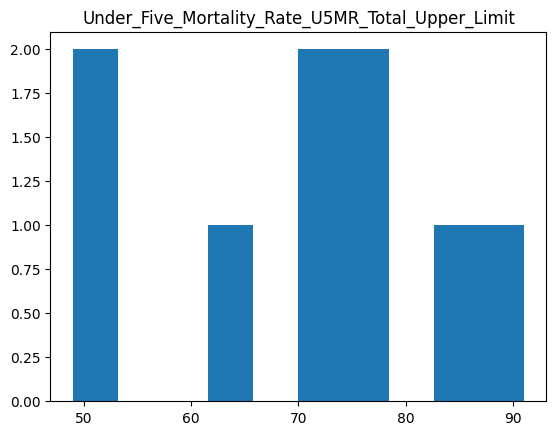

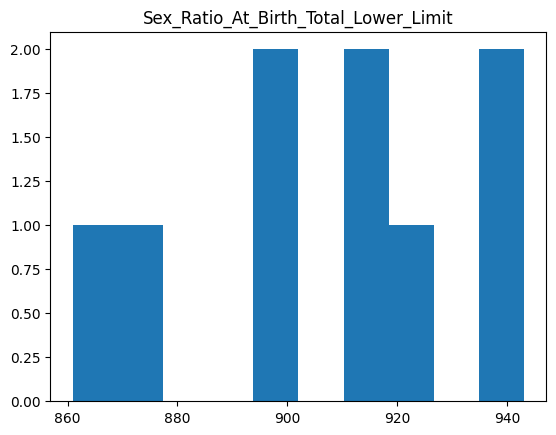

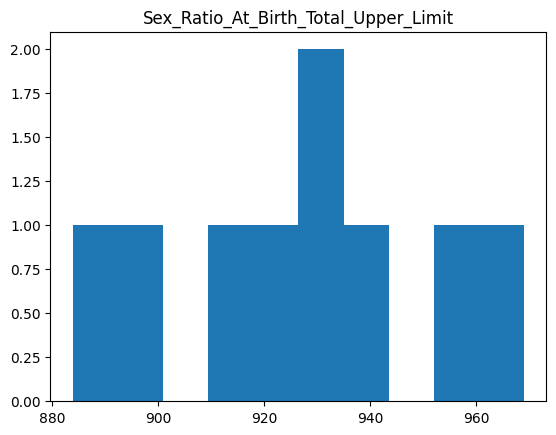

In [53]:
# Distributions for variable totals
for c in col_totals:
    plt.hist(df[c]), plt.title(c)
    plt.show()

In [55]:
## Null values for each feature with nulls
null_counts = nullcount(df)
has_null = dict()
for k,v in null_counts.items():
    if v>0:
        has_null[k]=v
sorted(has_null.items(), key = lambda item: item[1])

[]

In [56]:
## Number of features with nulls
len(has_null)

0